# DESeq2 with new reference genome
but with pre-filtering! 
# Phase 2 vs. Phase 2

focusing on pairwise comparisons of oysters that experienced both phase 1 and phase 2

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano) # for volcano plots
library(vegan) # for permanova
library(pheatmap)
library(RColorBrewer)
library(limma) # for removing batch effects

## 1. read counts matrix and meta data

### counts matrix
the counts matrix was generated in [processing_seqs.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/processing_seqs.ipynb) with the new reference genome ([NCBI GCF_053477285.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)), indexed and aligned with `hisat2`, and counts matrix generated with `featureCounts` (all with the same flags/settings that were used with the old genome)

In [3]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts.df <- counts %>%
select(-Gene_ID, -Length)

head(counts.df)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [4]:
# number of genes with 0 counts for all samples
sum(rowSums(counts.df) == 0) # 4884 genes

# pre-filter those rows
counts.filtered <- counts.df[!rowSums(counts.df) == 0,]

# double check this worked
dim(counts.df) # 33903 total genes
dim(counts.filtered) # 29019 genes with at least 1 read

[1] 4884

[1] 33903   120

[1] 29019   120

### meta data
the meta data csv was already generated in [deseq_p1.v.p1](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/deseq_p1.v.p1.ipynb), so just reading in here

In [5]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(!grepl("Nu", Sample)) # filter out phase 1 samples - only want phase 2

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

head(meta)
dim(meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


[1] 96  8

creating new column for 'complete' treatment - so I can easily compare phase 1 to phase 2

In [6]:
meta$complete_trtmt <- paste(meta$Phase1_treatment, meta$Phase2_treatment)

# check
head(meta,2)
tail(meta,2)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm


,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
W6_W3_G36,warm,warm,normoxic,6,warm,warm,normoxic,3,warm warm
W6_W4_G48,warm,warm,normoxic,6,warm,warm,normoxic,4,warm warm


In [7]:
# setting the same order for counts matrix and meta data
counts.filtered <- counts.filtered[,rownames(meta)]
all(rownames(meta) == colnames(counts.filtered))

[1] TRUE

## 2. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [8]:
# tempature treatments
meta$Phase1_temp <- factor(meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

meta$Phase2_temp <- factor(meta$Phase2_temp,
                                   levels = c('ambient', 'warm'))

In [9]:
# DO treatments
meta$Phase1_DO <- factor(meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

meta$Phase2_DO <- factor(meta$Phase2_DO,
                                   levels = c('normoxic', 'hypoxic'))

### complete treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [10]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = counts.filtered,
                              colData = meta,
                              design = ~ complete_trtmt)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



class: DESeqDataSet 
dim: 29019 96 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

looks like there were 29019 genes pre-filter

for the filter, I want to make sure to filter out rows with just one strong signal from one sample (for example, I sometimes see a DEG but at closer look, it is driven by high expression of one sample) 

to do this, i'm going to only keep genes that have a consistent signal (at least 5 reads) in at least 5 samples in at least one treatment treatment combo 

### pre-filter genes 

In [11]:
# filter genes with inconsistent/low reads 
dds$group <- factor(dds$complete_trtmt)

keep <- apply(counts(dds), # raw counts matrix
              1, # apply across rows - for each row/gene, apply this function: 
              function(x) {
  any(tapply(x, dds$group, # split counts for this gene by treatment combo
             function(g) sum(g >= 5) >= 3)) # does this treatment combo have at least 3 samples with counts of 5 or more?
             # any = is at least one group true?
})
dds_filtered <- dds[keep, ]


In [12]:
dds_filtered

class: DESeqDataSet 
dim: 26060 96 
metadata(1): version
assays(4): counts mu H cooks
rownames(26060): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(78): baseMean baseVar ... deviance maxCooks
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

21,663 genes after filtering

In [13]:
26060 / 29019
# so maintaining about 90% of genes

[1] 0.8980323

Checking how strict this filtering was by looking at the control oysters and see how many genes have reasonable counts (not outliers/no counts) 

#### run DESeq again

In [14]:
# run DESeq on the filtered dds object
dds_filtered <- DESeq(dds_filtered)

# run vst on new dds object
vst_mat <- assay(vst(dds_filtered, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [15]:
dim(vst_mat)
head(vst_mat)

[1] 26060    96

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.506739,11.290426,11.274519,11.128664,10.825870,10.807494,11.229752,10.895370,11.007769,11.031302,⋯,11.733793,10.445095,10.946084,11.422612,11.278501,11.089837,11.234382,11.073554,11.706315,11.542363
LOC144621269,8.493607,11.007891,11.445643,10.336375,11.486465,10.494344,12.769196,10.901695,8.233225,8.059534,⋯,13.887492,7.979161,8.067537,10.000519,8.416978,8.785045,13.435455,8.209287,9.643918,13.412882
LOC111120925,8.579916,8.266198,9.701748,8.103600,8.205353,8.079663,7.804871,7.902852,7.804871,7.901232,⋯,9.557409,7.804871,7.990732,9.721694,8.635261,8.328068,8.036248,7.906286,8.137336,8.103365
LOC144621283,9.862385,10.313096,10.337655,10.153495,10.252870,10.549224,10.513537,9.713574,10.077554,10.183225,⋯,9.960665,10.461483,10.193975,10.339949,10.309120,10.220672,9.935887,10.840620,9.951071,9.983954
LOC144621276,13.437845,13.481503,13.655653,13.487925,13.768186,13.890567,13.703314,13.202264,13.746433,13.420767,⋯,14.016282,13.293335,13.840370,13.533890,13.078933,13.265197,13.925498,13.359720,13.406014,13.356125
LOC111115920,8.990057,9.064179,8.956104,8.786534,8.700691,8.644403,8.545452,9.574368,8.749270,9.428388,⋯,8.666097,8.765803,9.260882,8.896594,9.604774,9.607869,9.066350,9.239288,8.726199,8.846351


### explore results and fit

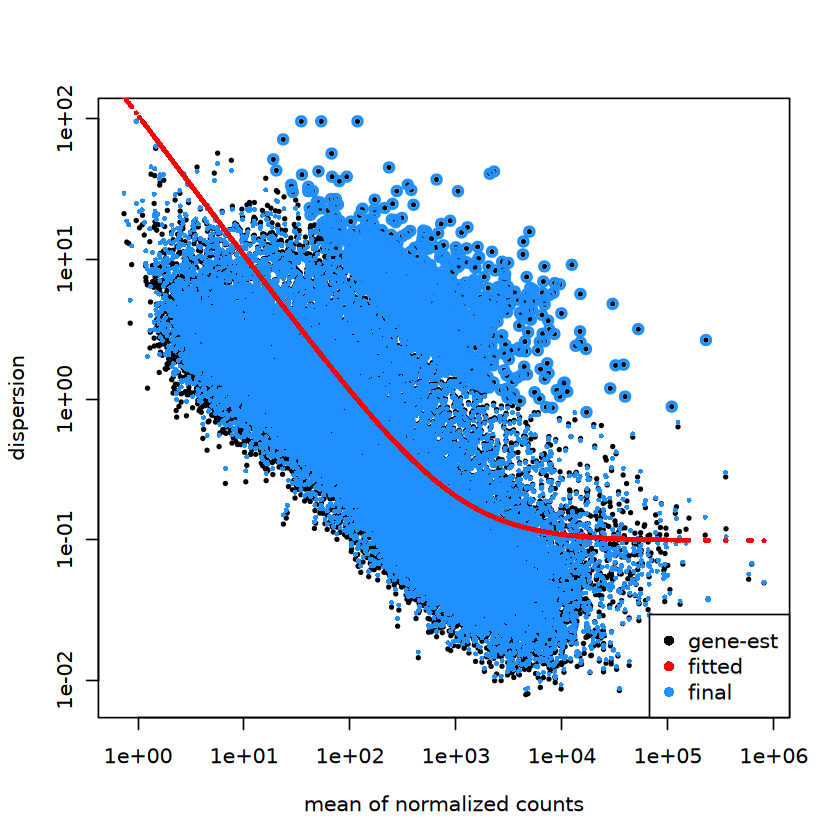

In [17]:
plotDispEsts(dds_filtered)

### nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [18]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,81.17469,84.48860,79.08079,83.95106,82.34655,91.47219,83.49670,83.45295,74.71603,⋯,99.31810,80.23296,70.37641,74.44621,71.35128,74.81232,95.29262,77.84672,76.12725,100.05484
B1_W5_O50,81.17469,0.00000,78.26415,68.56732,64.77855,70.46682,71.67051,82.23779,79.05891,78.36182,⋯,82.11093,86.24772,79.85927,79.98522,82.40868,79.59138,83.94963,81.38642,76.19416,80.50329
B2_B5_O51,84.48860,78.26415,0.00000,86.15990,80.53545,85.46521,82.04571,92.73349,95.80407,92.31772,⋯,87.72215,98.29659,89.80196,77.86505,88.77273,90.94060,88.38233,91.18474,87.02460,83.53047
B2_C4_O40,79.08079,68.56732,86.15990,0.00000,72.32386,70.51130,79.86594,80.24003,82.88784,73.22532,⋯,88.09038,81.39254,77.52661,77.49506,78.39671,76.59543,91.35576,75.68057,60.96719,88.57371
B3_B4_O41,83.95106,64.77855,80.53545,72.32386,0.00000,75.43176,77.50838,87.30230,75.78435,82.20989,⋯,80.15785,89.93878,80.93280,83.62561,87.47606,84.28828,79.88400,84.55540,79.55804,80.52718
B3_C3_O30,82.34655,70.46682,85.46521,70.51130,75.43176,0.00000,82.48342,86.02701,86.42159,81.41093,⋯,91.50152,87.99027,74.19626,83.74453,84.78347,81.06781,94.37442,78.25852,78.76372,92.71638


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,11.491594,12.639810,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-2.333362,-16.608593,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-17.071450,-7.883250,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,6.223148,-7.419990,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-7.832214,-16.339906,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,6.504263,-5.832943,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


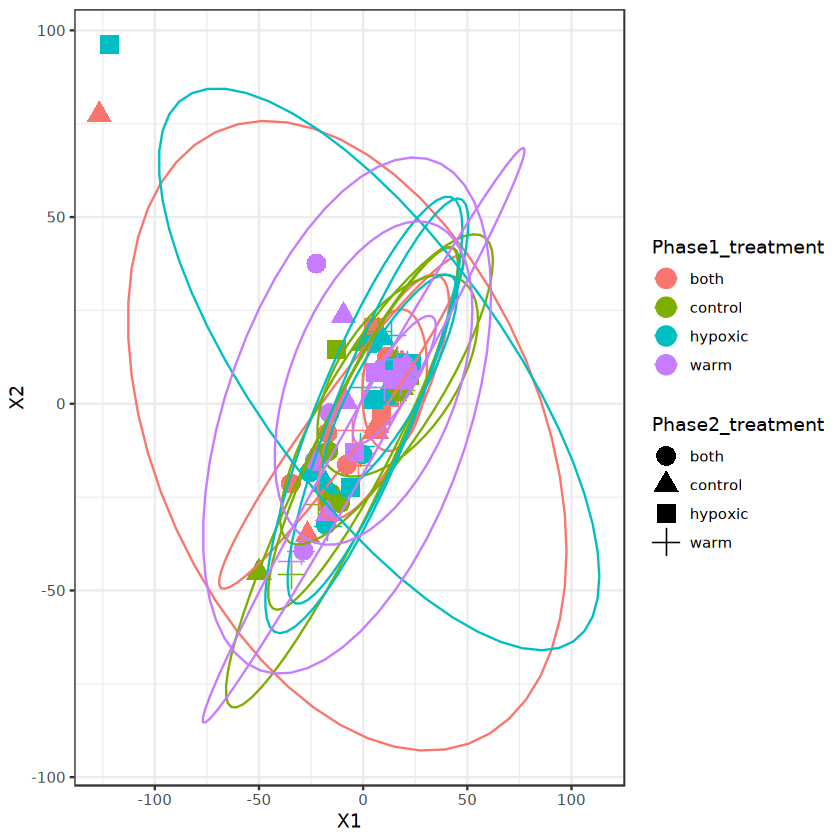

In [19]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

In [20]:
sample_dists <- dist(t(assay(vsd)))  # transpose so samples are rows
head(sample_dists)

meta <- as.data.frame(colData(vsd))
head(meta)

[1] 81.17469 84.48860 79.08079 83.95106 82.34655 91.47219

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [21]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3236.924,0.008307427,0.7930077,0.781
Phase1_DO,1,3376.258,0.008665020,0.8271427,0.749
Phase2_temp,1,8814.911,0.022623088,2.1595475,0.005
Phase2_DO,1,5828.697,0.014959099,1.4279609,0.074
Phase1_temp:Phase1_DO,1,2739.712,0.007031354,0.6711967,0.968
Phase1_temp:Phase2_temp,1,2713.907,0.006965124,0.6648746,0.961
Phase1_DO:Phase2_temp,1,3698.967,0.009493240,0.9062026,0.579
Phase1_temp:Phase2_DO,1,3207.229,0.008231214,0.7857326,0.794
Phase1_DO:Phase2_DO,1,3594.704,0.009225652,0.8806593,0.628


- Phase2_temp has a significant effect on GE (P = 0.004) and explains ~2.2% of the variation in GE
- Phase2_DO also has a significant effect on GE (P = 0.040) and explains ~1.5% of the variance
- The interaction of Phase2_temp and Phase2_DO is significant (P = 0.050) and explains ~1.5% of the variation in GE
    - this means the effect of phase 2 temp depends on the value of phase 2 DO (or vice versa)
- The majoirty of the variation in GE is not explained by the treatments (R2 = 0.84)

### heatmap of sample-to-sample distances using the variance stabilizing transformed values
following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [22]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- dist(t(assay(dds_filtered)))
head(sample_dists)

[1]  559109.0  658789.3  525933.1  551766.8  502959.1 1120977.4

In [23]:
head(vsd)

class: DESeqTransform 
dim: 6 96 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

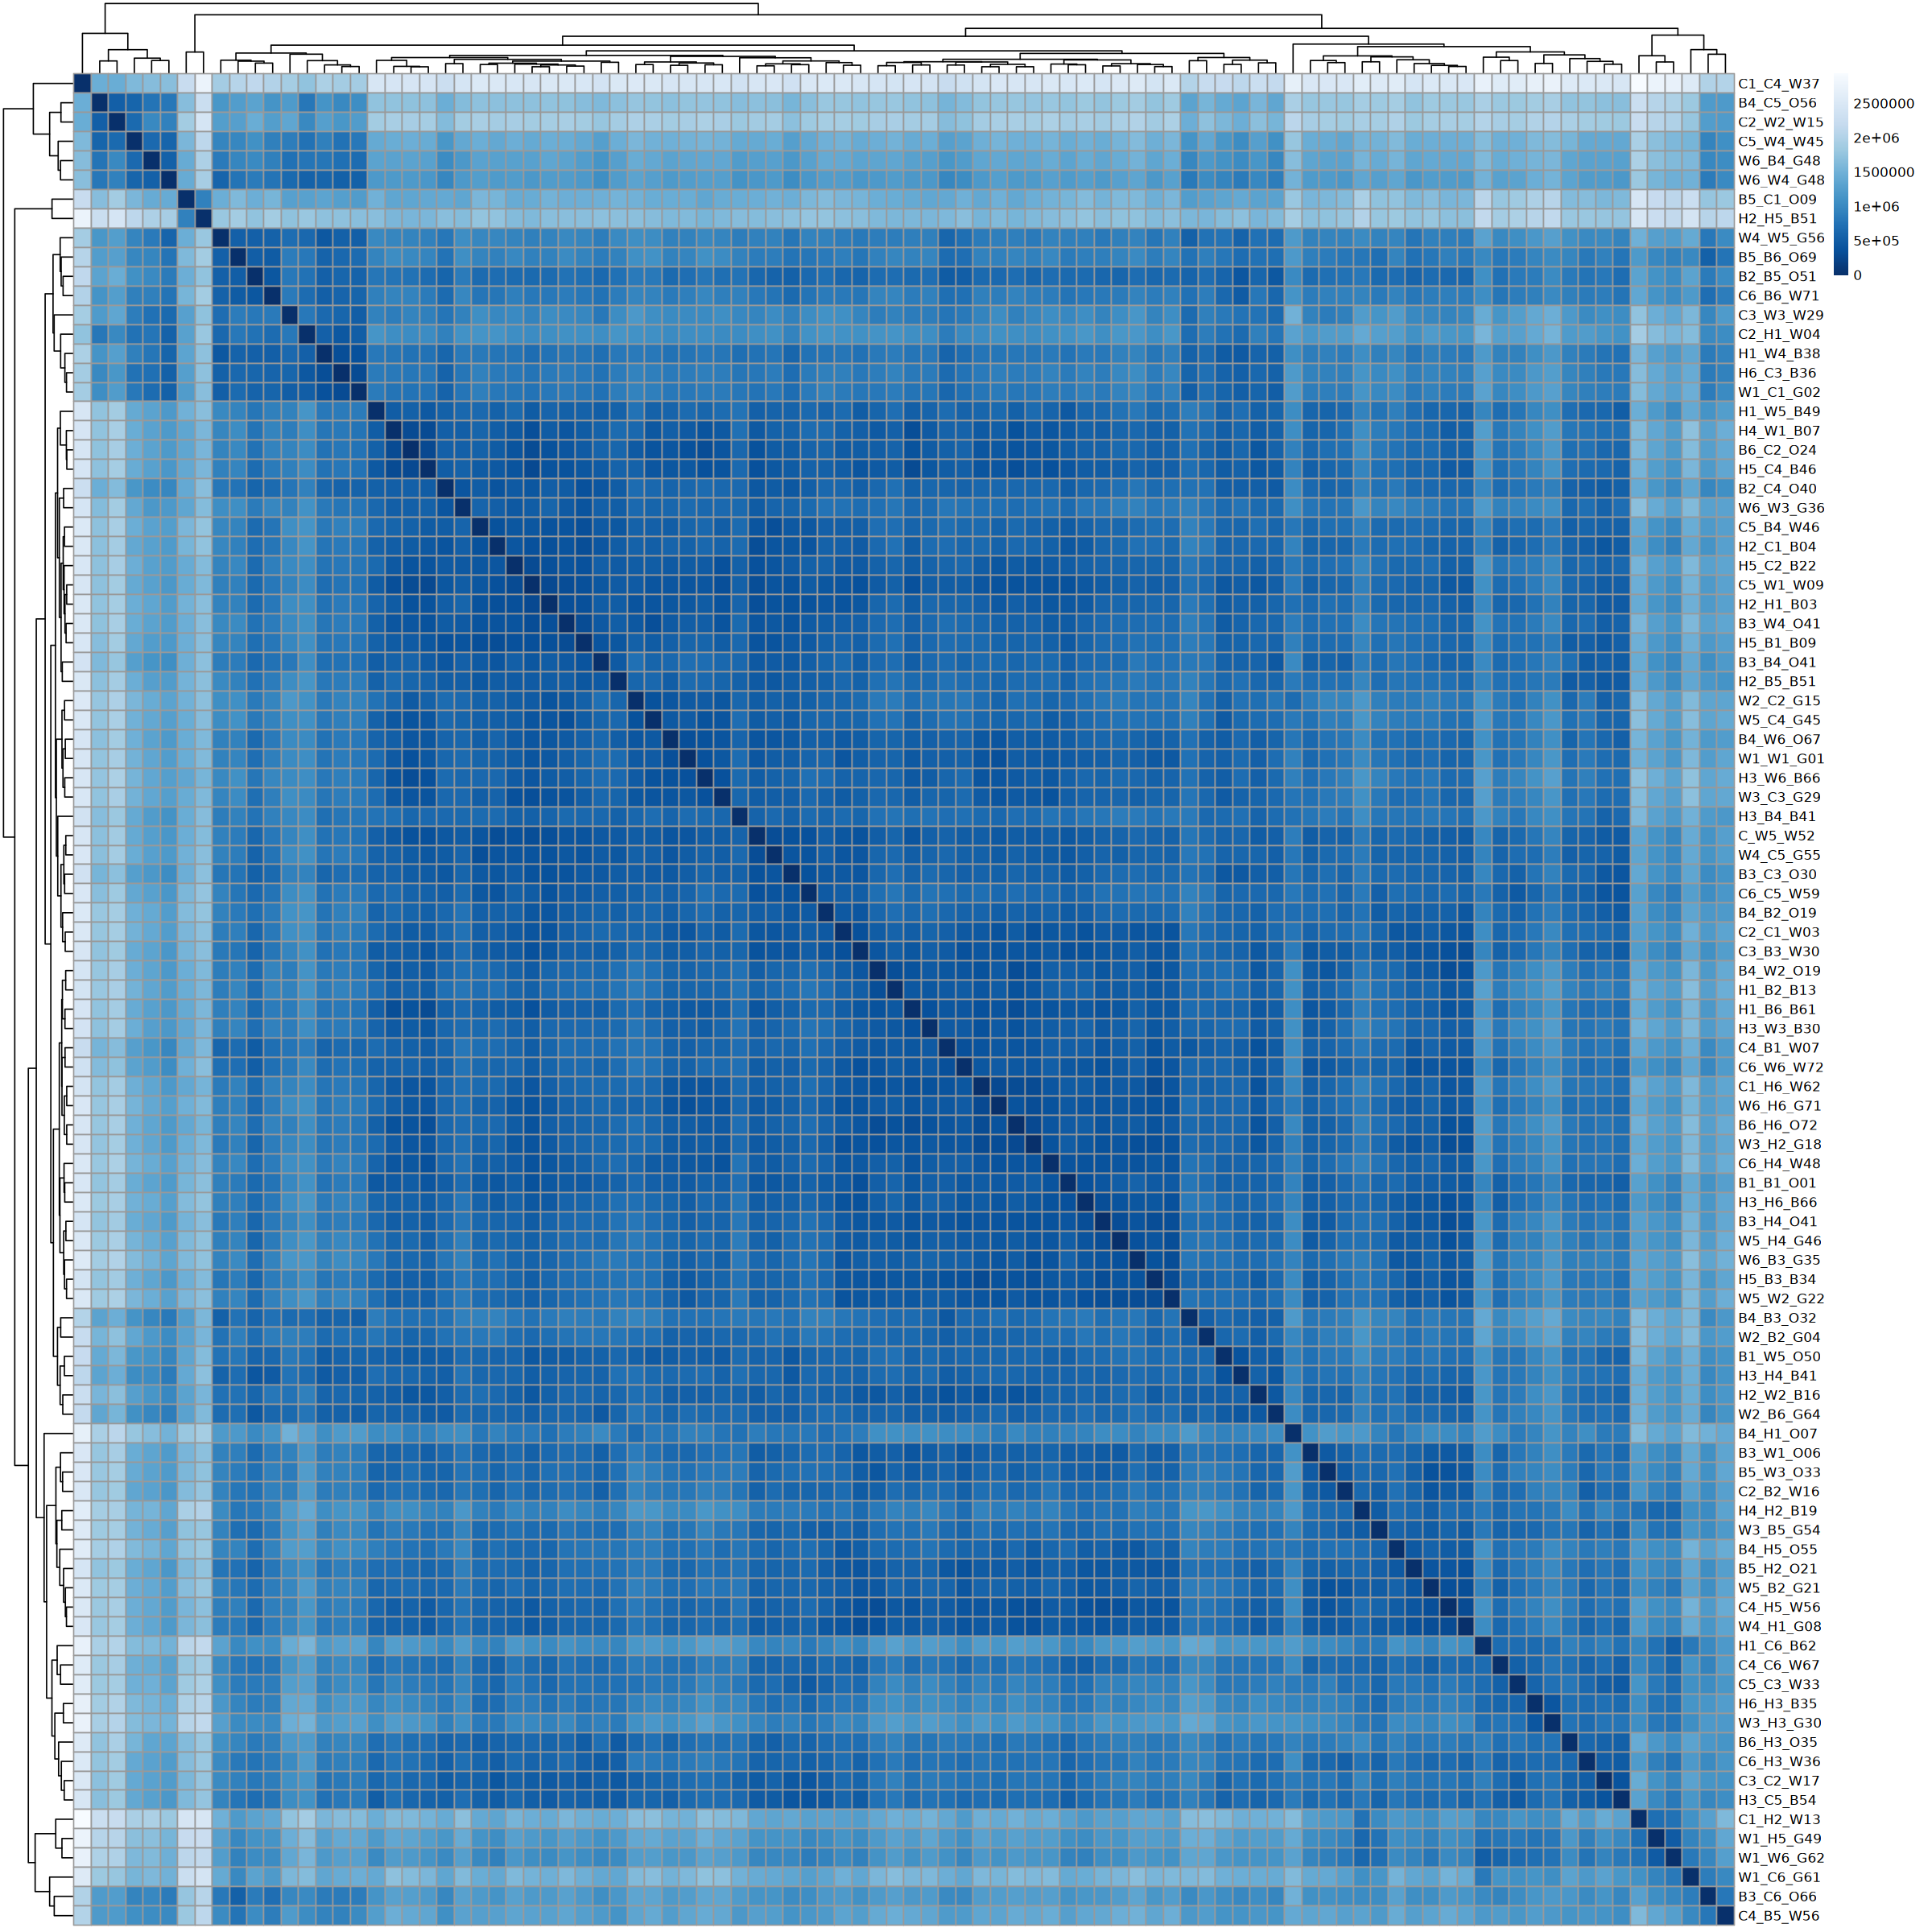

In [24]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

it's weird that there's two samples that are very dissimilar to every other sample, but appear closer together - (HH and BC) - if you look at the nMDS plots too, they look like outliers from their replicates so should consider removing those samples from analysis 

In [25]:
pcaData <- plotPCA(vsd, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-13.0437674,-3.611237,both:both,both,both,B1_B1_O01
B1_W5_O50,10.9126353,8.420179,both:warm,both,warm,B1_W5_O50
B2_B5_O51,15.6111253,-4.280954,both:both,both,both,B2_B5_O51
B2_C4_O40,1.7498153,5.145200,both:control,both,control,B2_C4_O40
B3_B4_O41,15.1470227,6.226355,both:both,both,both,B3_B4_O41
B3_C3_O30,0.4126957,5.078508,both:control,both,control,B3_C3_O30


### PCA

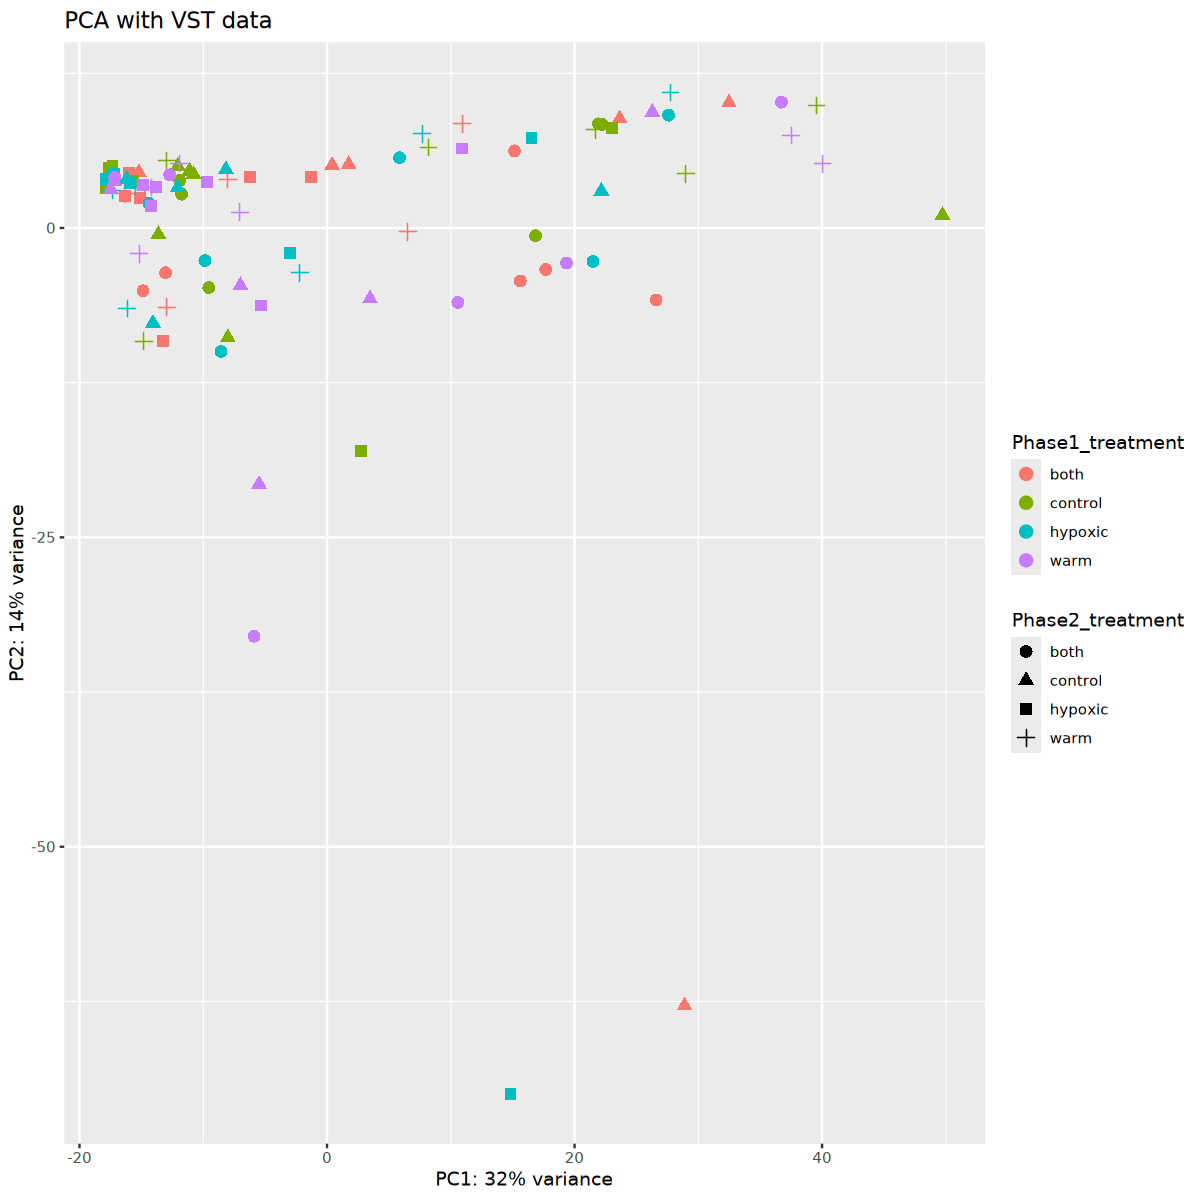

In [26]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData, "percentVar"))

ggplot(pcaData, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with VST data")

there's those two samples again in the bottom of the plot - B5_C1_O09 and H2_H5_B51 - that cluster away from everything else 

what do things look like if I remove those?

In [27]:
# remove two samples
dds_rm<- dds_filtered[, !colnames(dds_filtered) %in% c("B5_C1_O09", "H2_H5_B51")]

In [28]:
# normalization & transformation
vsd_filtered <- vst(dds_rm)

# calculate sample distances
sample_dists_filtered <- dist(t(assay(vsd_filtered)))
head(sample_dists_filtered)

[1] 80.56880 83.86479 78.49837 83.33886 81.75433 90.81074

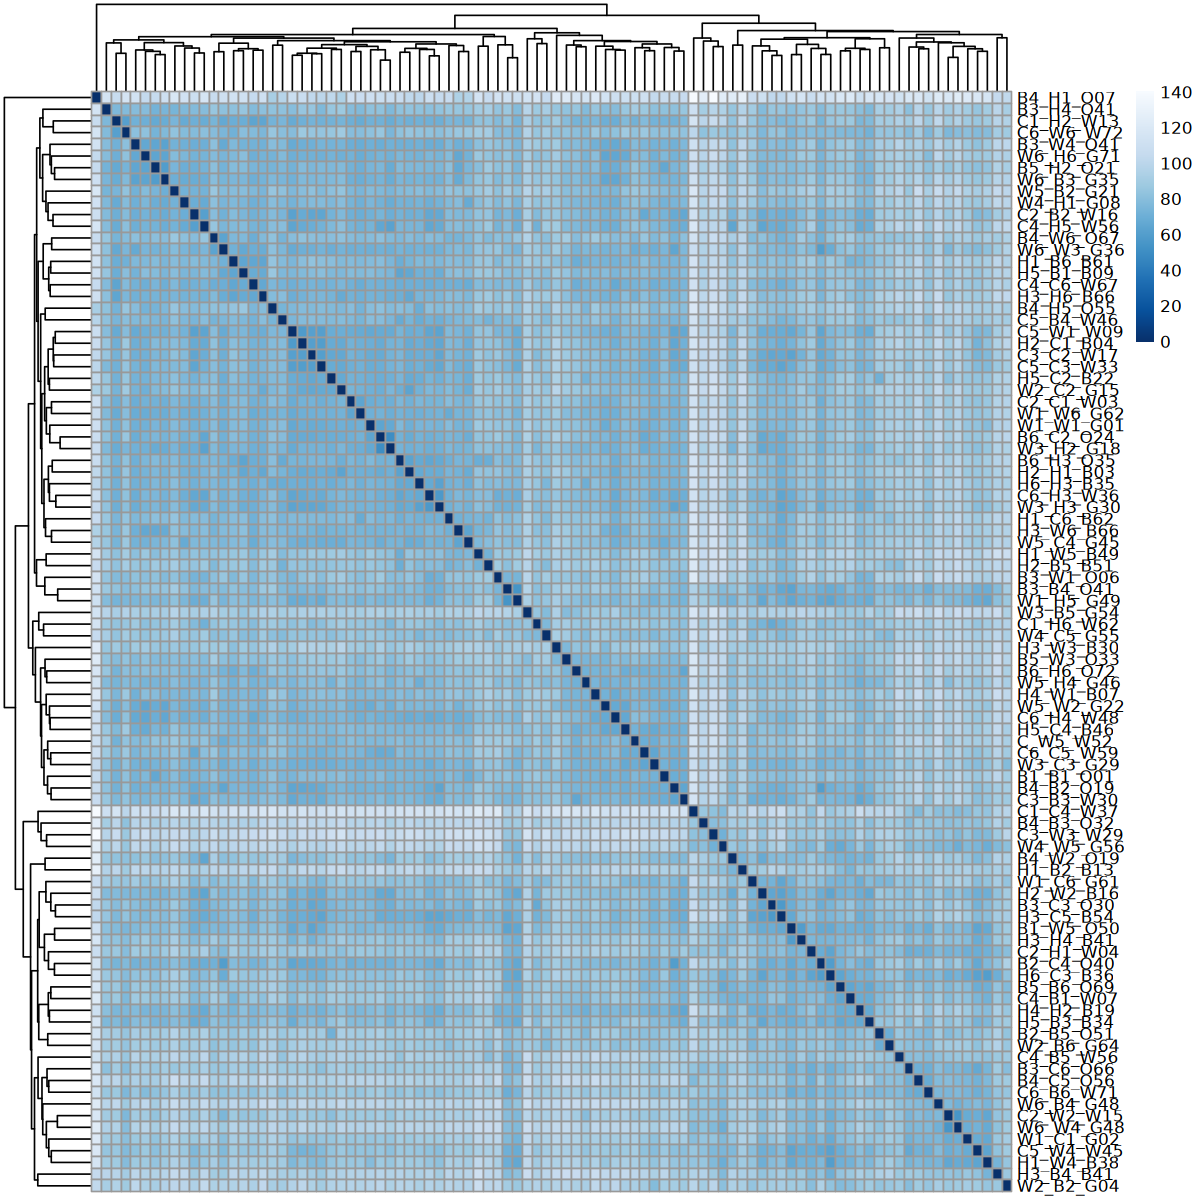

In [29]:
sampleDistMatrix <- as.matrix(sample_dists_filtered)
rownames(sampleDistMatrix) <- paste(colnames(vsd_filtered))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists_filtered,
         clustering_distance_cols = sample_dists_filtered,
         col = colors)

In [30]:
pcaData_filtered <- plotPCA(vsd_filtered, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData_filtered)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-13.110647,-8.330373,both:both,both,both,B1_B1_O01
B1_W5_O50,12.421904,4.383282,both:warm,both,warm,B1_W5_O50
B2_B5_O51,15.652446,-13.012978,both:both,both,both,B2_B5_O51
B2_C4_O40,2.546170,7.187841,both:control,both,control,B2_C4_O40
B3_B4_O41,15.867706,6.575690,both:both,both,both,B3_B4_O41
B3_C3_O30,1.332008,5.057415,both:control,both,control,B3_C3_O30


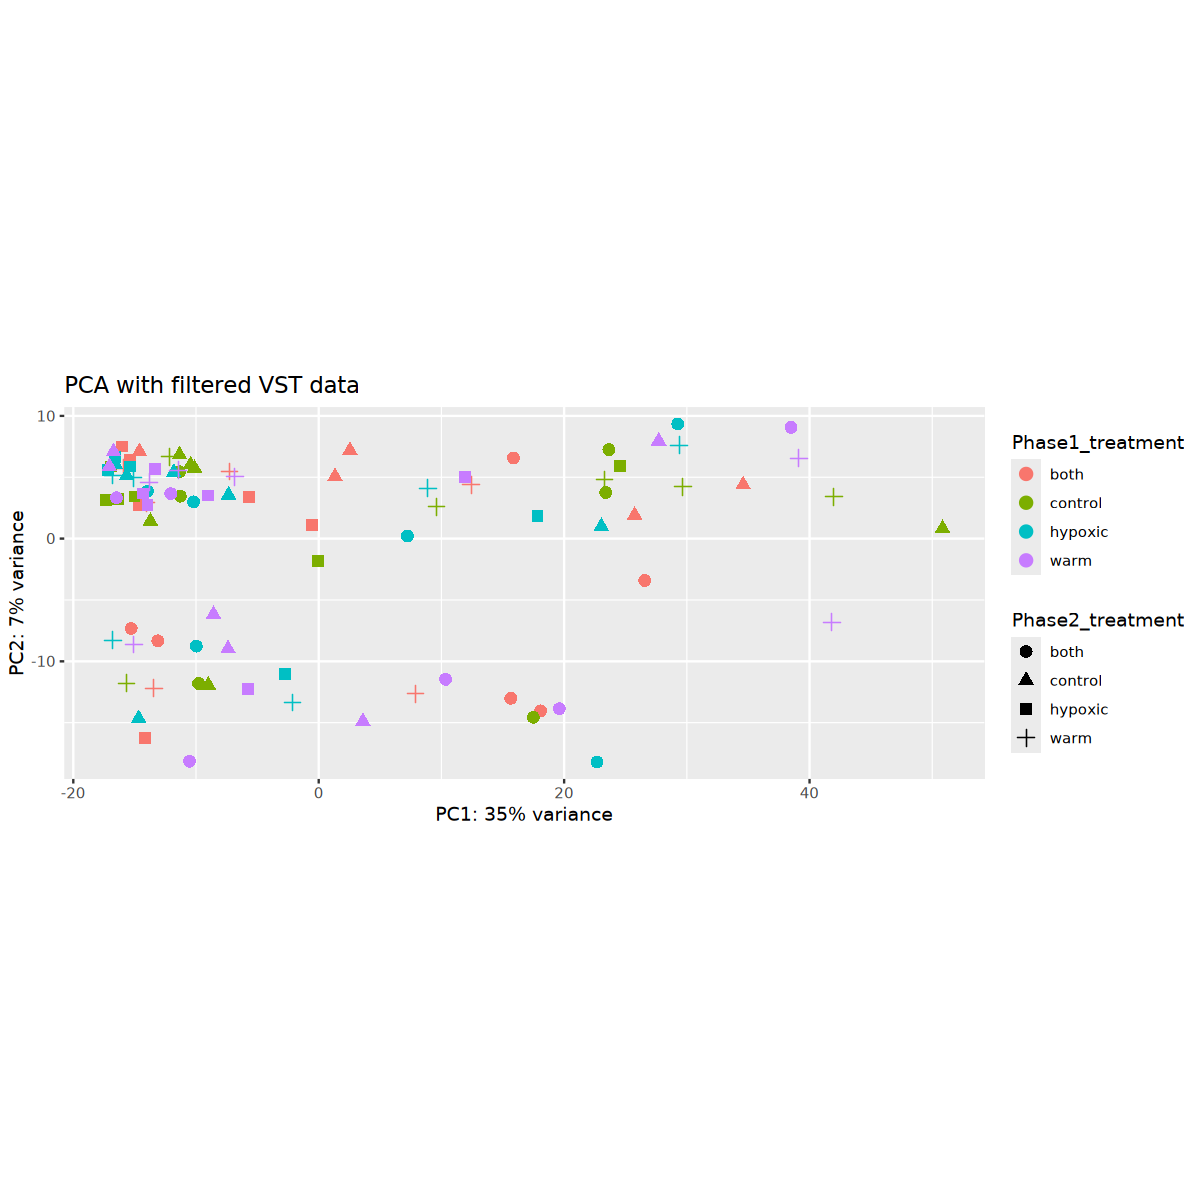

In [31]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData_filtered, "percentVar"))

ggplot(pcaData_filtered, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with filtered VST data")

In [32]:
# calculate MDS value from distance matrix
mdsData_filtered <- data.frame(cmdscale(sample_dists_filtered))
mds_filtered <- cbind(mdsData_filtered, as.data.frame(colData(vsd_filtered))) # combine with sample data
head(mds_filtered)

,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,16.0046465,-8.792288998,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-13.6021237,6.083812880,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-18.8291291,-0.658455087,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-0.9679314,0.006604586,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-17.3399189,9.290500622,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,0.1441657,15.910793629,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


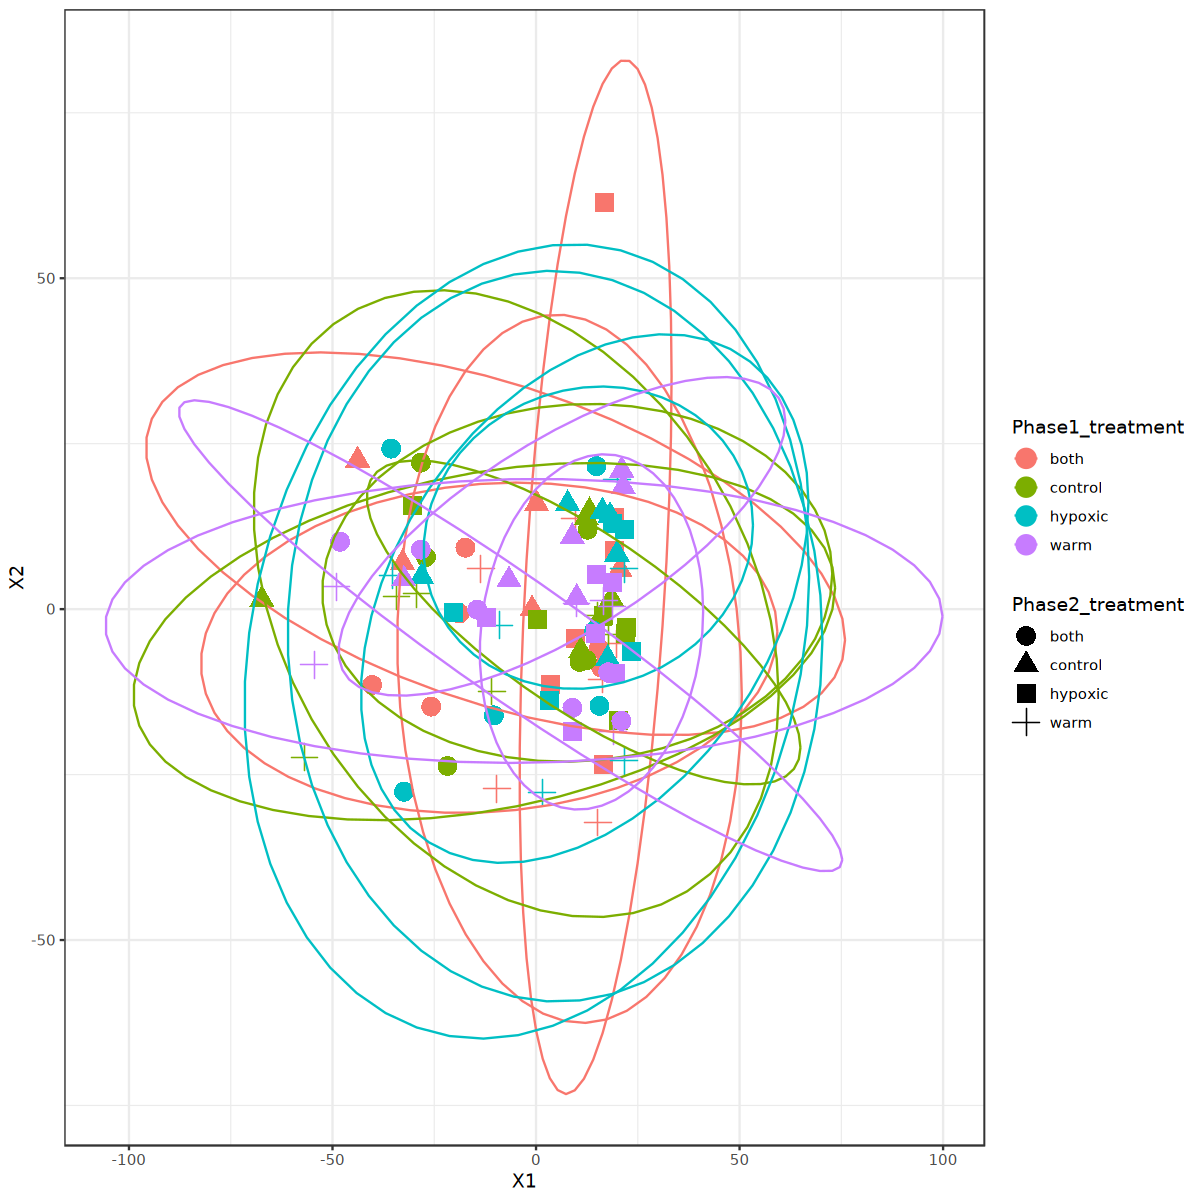

In [33]:
ggplot(mds_filtered, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

okay so it appears when we remove those two seemingly outlier samples, the data gets a little bit 'more clear' and replicates segregate a little better

let's remove those samples (**B5_C1_O09** and **H2_H5_B51**) and re-run DESeq2

## 2. remove outliers, run DESeq again

In [34]:
outlier_samples <- c('B5_C1_O09', 'H2_H5_B51')

dds_rm <- dds_filtered[, !colnames(dds_filtered) %in% outlier_samples]
dds_rm <- DESeq(dds_rm)
vst_mat <- assay(vst(dds_rm, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [35]:
write.csv(vst_mat, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/vst_filtered.csv', row.names = FALSE)

In [47]:
meta_noOutliers <- meta[!rownames(meta) %in% outlier_samples, ]

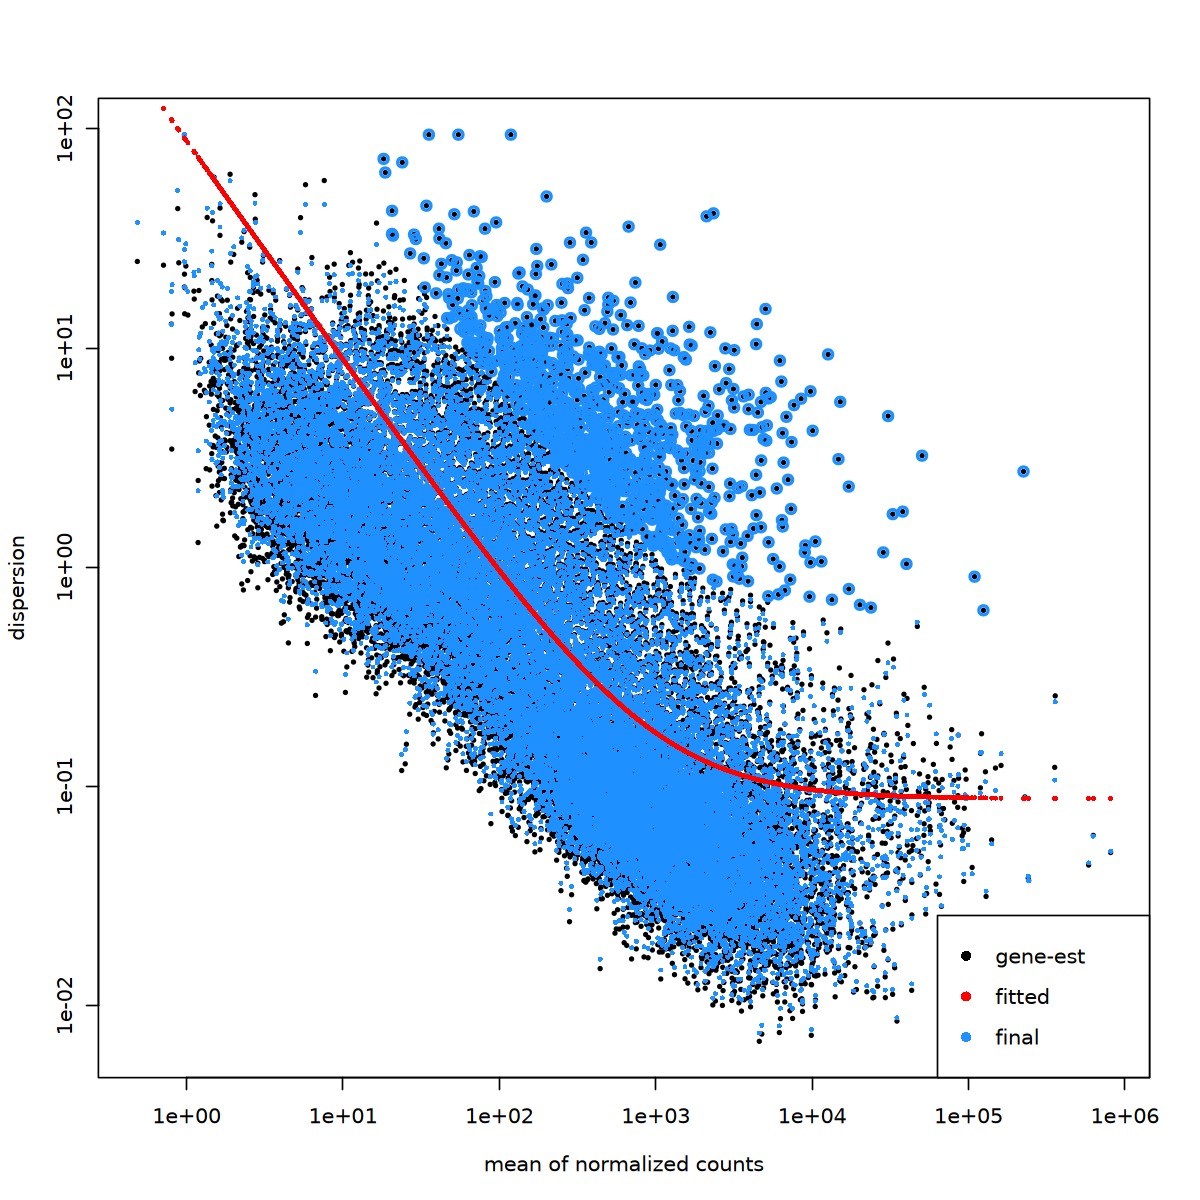

In [48]:
options(repr.plot.height = 10, repr.plot.width = 10)

plotDispEsts(dds_rm)

### PCA

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-11.579759,-7.053367,both:both,both,both,B1_B1_O01
B1_W5_O50,10.490395,3.587316,both:warm,both,warm,B1_W5_O50
B2_B5_O51,13.443795,-11.485622,both:both,both,both,B2_B5_O51
B2_C4_O40,1.839809,6.911596,both:control,both,control,B2_C4_O40
B3_B4_O41,13.792347,5.824017,both:both,both,both,B3_B4_O41
B3_C3_O30,1.073118,4.558061,both:control,both,control,B3_C3_O30


using ntop=500 top features by variance



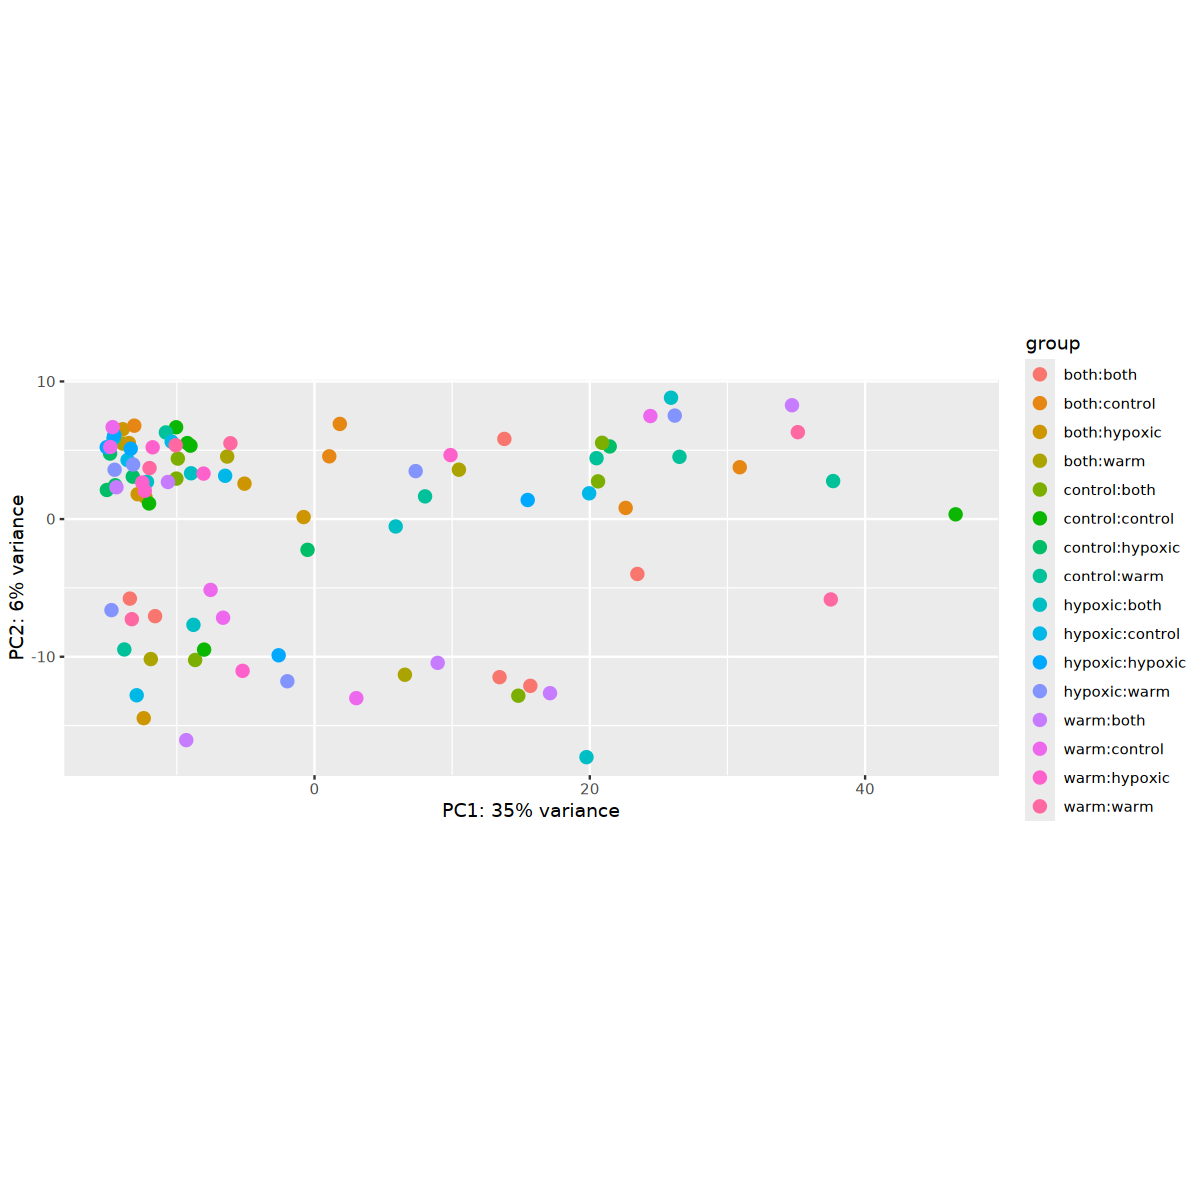

In [49]:
options(repr.plot.height = 10, repr.plot.width = 10)

vsd <- vst(dds_rm, blind=FALSE)
pca_data <- plotPCA(vsd, intgroup=c("Phase1_treatment", "Phase2_treatment"), returnData=TRUE)
head(pca_data)

plotPCA(vsd, intgroup=c("Phase1_treatment", "Phase2_treatment"))

two groups seperating on the y axis

also PC1 explains 34% of the variance

using ntop=500 top features by variance



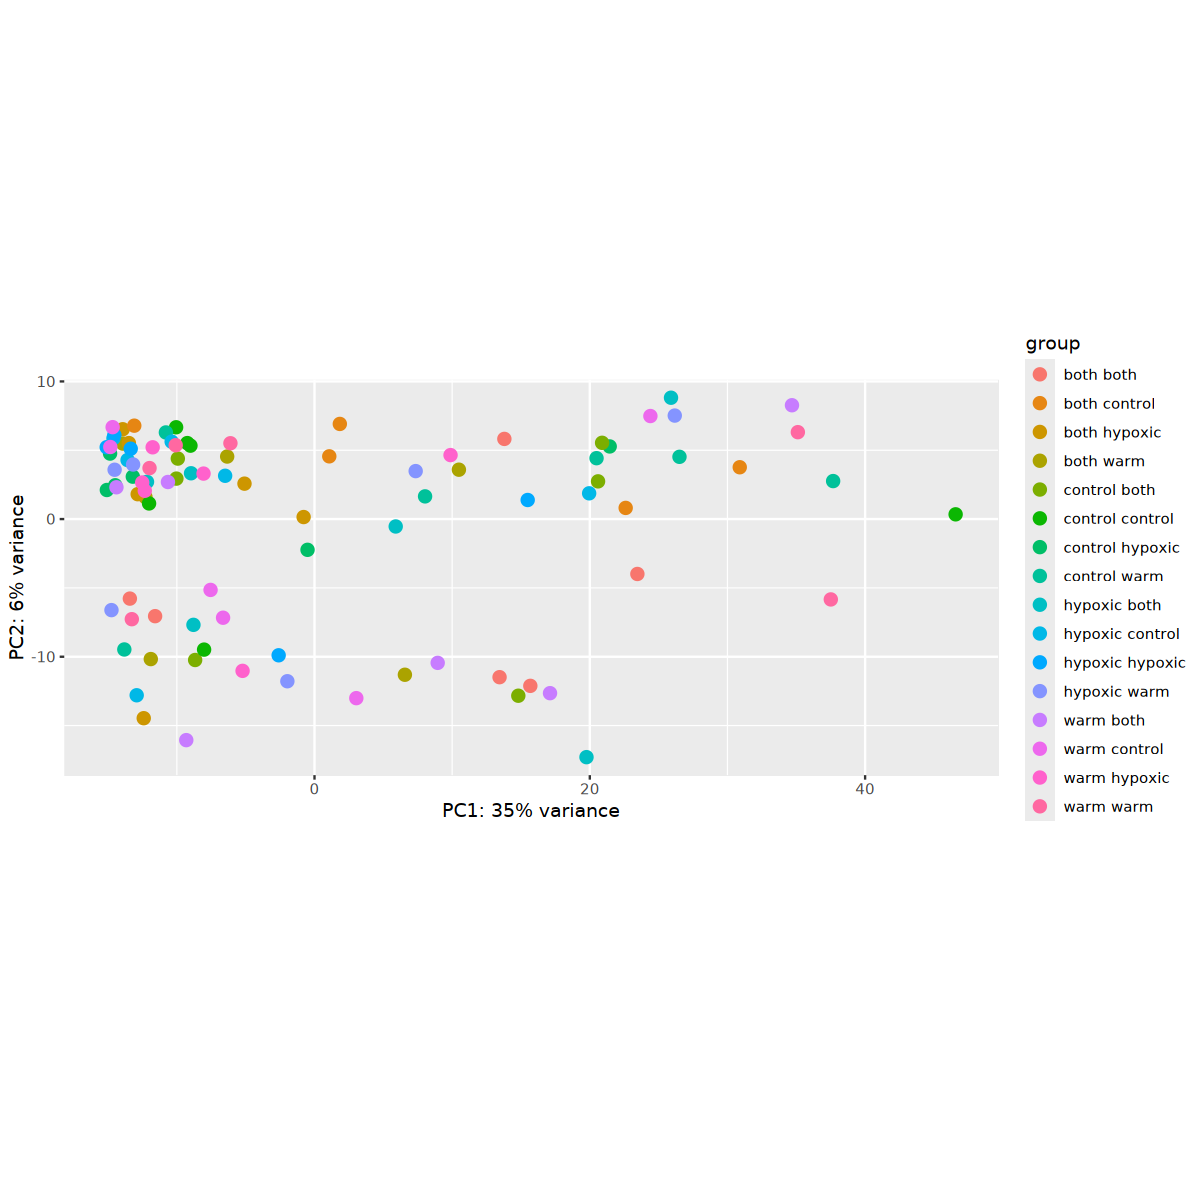

In [50]:
plotPCA(vsd, intgroup=c("complete_trtmt"))

### nMDS
normalize and transform DESeq object using vst (variance stabilized expression matrix)

In [51]:
# variance stabilizing transformation
vsd <- vst(dds_rm)
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.628602,11.429277,11.414696,11.281505,11.008056,10.991599,11.373718,11.070443,11.171820,11.193119,⋯,11.839799,10.670423,11.116112,11.550856,11.418345,11.246206,11.377952,11.231423,11.814137,11.661608
LOC144621269,9.050233,11.171930,11.572112,10.575355,11.609840,10.713686,12.823953,11.076133,8.844727,8.708255,⋯,13.913519,8.645209,8.714535,10.285500,8.989611,9.282198,13.470705,8.825895,9.984049,13.448667
LOC111120925,9.118683,8.870681,10.032502,8.742844,8.822801,8.724052,8.508609,8.585390,8.508609,8.584120,⋯,9.911873,8.508609,8.654282,10.049252,9.162679,8.919430,8.689983,8.588080,8.769339,8.742660
LOC144621283,10.167967,10.555077,10.576471,10.416804,10.502746,10.762039,10.730579,10.042431,10.351471,10.442462,⋯,10.251490,10.684806,10.451751,10.578471,10.551616,10.474844,10.230386,11.021278,10.243315,10.271354
LOC144621276,13.473038,13.515685,13.686073,13.521960,13.796391,13.916541,13.732776,13.243430,13.775053,13.456364,⋯,14.040143,13.332086,13.867237,13.566895,13.123602,13.304679,13.950866,13.396795,13.441963,13.393289
LOC111115920,9.446989,9.506950,9.419593,9.283389,9.214805,9.169954,9.091328,9.925994,9.253588,9.804894,⋯,9.187230,9.266805,9.667150,9.371678,9.951345,9.953929,9.508709,9.649484,9.235160,9.331322


In [52]:
# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,80.56880,83.86479,78.49837,83.33886,81.75433,90.81074,82.86221,82.87158,74.15903,⋯,98.62448,79.64069,69.87628,73.90093,70.82269,74.24983,94.64169,77.28274,75.57003,99.35424
B1_W5_O50,80.56880,0.00000,77.66133,68.07119,64.30180,69.95450,71.13919,81.63487,78.51600,77.77645,⋯,81.55031,85.62397,79.26677,79.39698,81.80345,79.00936,83.37486,80.79568,75.63375,79.93205
B2_B5_O51,83.86479,77.66133,0.00000,85.53509,79.93363,84.82395,81.43301,92.04599,95.11897,91.64252,⋯,87.11073,97.58302,89.12982,77.30419,88.12956,90.26955,87.76406,90.51748,86.39344,82.95123
B2_C4_O40,78.49837,68.07119,85.53509,0.00000,71.81700,70.00923,79.29250,79.64918,82.33671,72.66578,⋯,87.49751,80.80158,76.95948,76.93013,77.81906,76.03880,90.73629,75.13099,60.50500,87.95502
B3_B4_O41,83.33886,64.30180,79.93363,71.81700,0.00000,74.88809,76.94882,86.67994,75.28019,81.61082,⋯,79.61242,89.30451,80.33994,83.02712,86.85697,83.68961,79.32042,83.95771,78.98902,79.95785
B3_C3_O30,81.75433,69.95450,84.82395,70.00923,74.88809,0.00000,81.88262,85.41097,85.84253,80.82103,⋯,90.86949,87.37672,73.63613,83.14800,84.18360,80.48991,93.72790,77.68832,78.19714,92.06977


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,16.0046465,-8.792288998,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-13.6021237,6.083812880,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-18.8291291,-0.658455087,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-0.9679314,0.006604586,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-17.3399189,9.290500622,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,0.1441657,15.910793629,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [53]:
mds$Phase1_treatment <- factor(mds$Phase1_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

mds$Phase2_treatment <- factor(mds$Phase2_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

Ignoring unknown labels:
• fill : "Phase 1 Treatment"


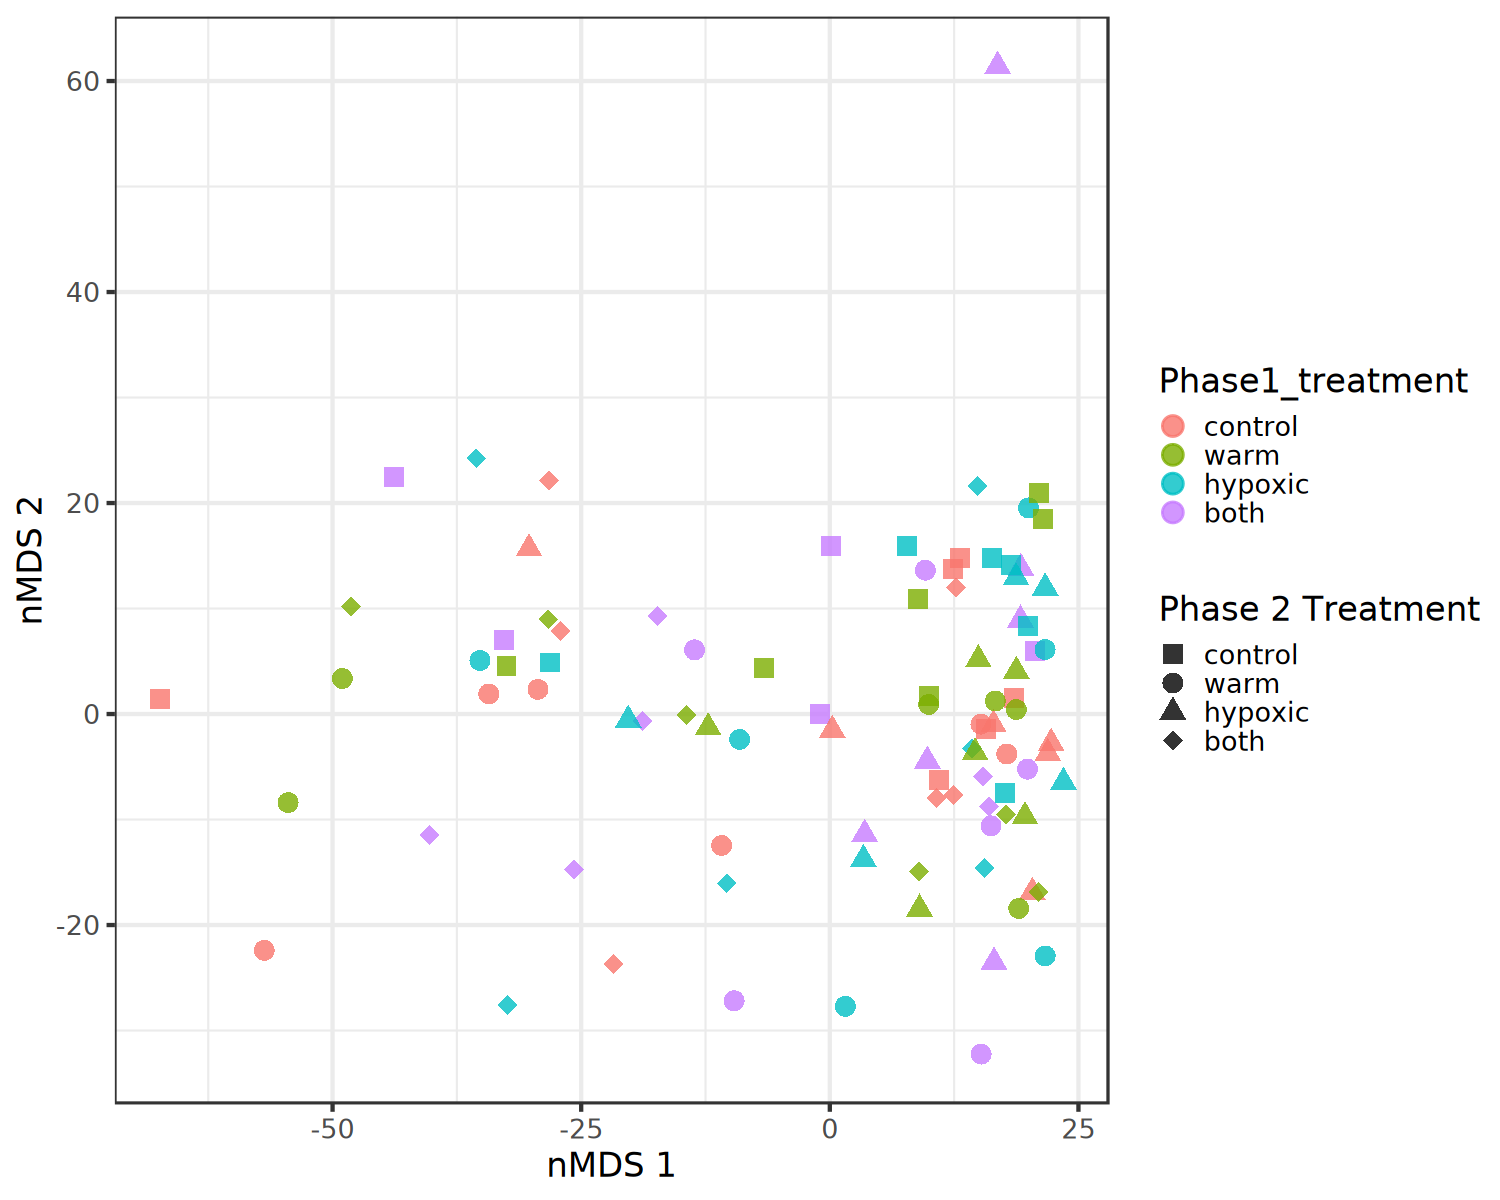

In [89]:
options(repr.plot.width = 12.5, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(
    size = 5,
    alpha = 0.8,
  ) +
scale_shape_manual(values = c(15, 16, 17,18)) +
# stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'nMDS 1', 
     y = 'nMDS 2',
    fill = 'Phase 1 Treatment',
    shape = 'Phase 2 Treatment')

nmds.plot

### permANOVA

differences in centroid location(position) between two groups

In [75]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3119.772,0.009336223,0.8784118,0.683
Phase1_DO,1,2945.964,0.008816085,0.8294739,0.762
Phase2_temp,1,8741.375,0.026159422,2.4612463,0.001
Phase2_DO,1,5576.782,0.016689065,1.5702144,0.021
Phase1_temp:Phase1_DO,1,2671.352,0.007994283,0.7521535,0.934
Phase1_temp:Phase2_temp,1,2646.331,0.007919406,0.7451085,0.942
Phase1_DO:Phase2_temp,1,2927.775,0.008761654,0.8243527,0.770
Phase1_temp:Phase2_DO,1,2708.622,0.008105815,0.7626471,0.914
Phase1_DO:Phase2_DO,1,3682.692,0.011020815,1.0369090,0.337


significant effects:
- phase2_temp (2.6% of variance)
- phase2_DO (1.7% of variance)
- phase2_temp:phase2_DO (1.7% of variance)

reformatting the nmds to look at the sig. effects of phase 2 temp and DO

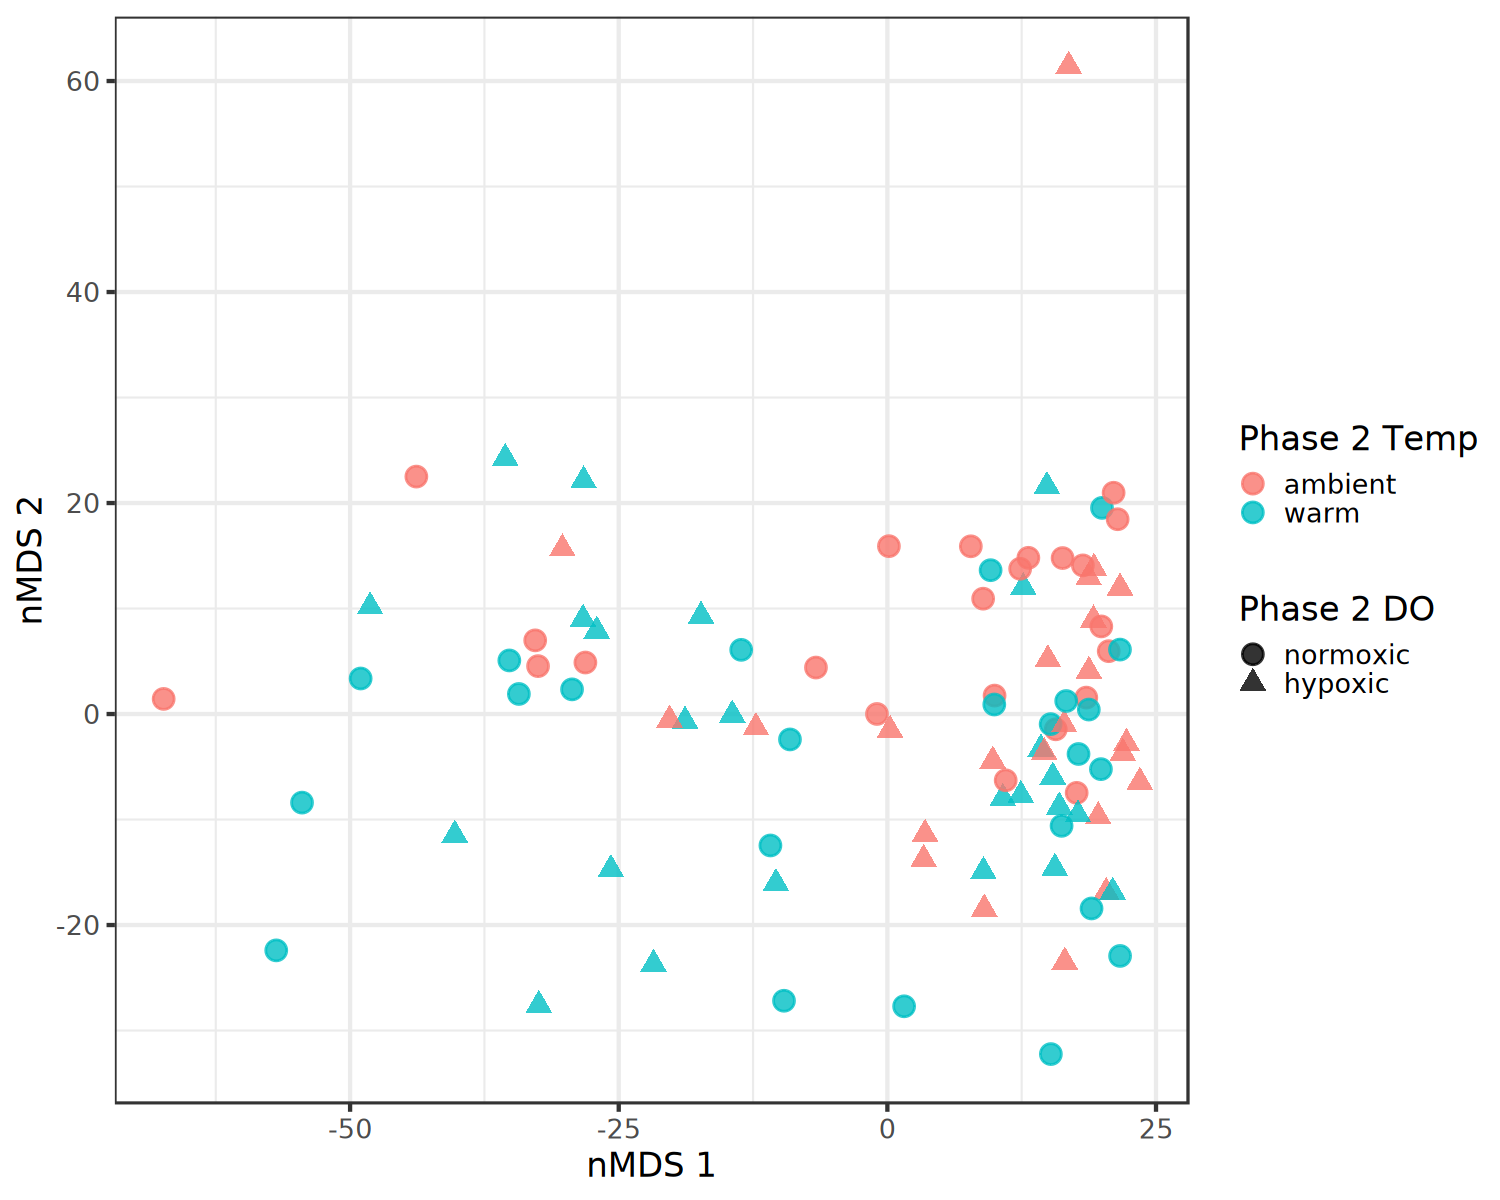

In [98]:
options(repr.plot.width = 12.5, repr.plot.height = 10)

nmds.plot2 <- ggplot(mds, aes(X1, X2, col = Phase2_temp, shape = Phase2_DO)) +
geom_point(
    size = 5,
    alpha = 0.8
  ) +
scale_shape_manual(values = c(19, 17)) +
# stat_ellipse() + 
theme_bw(base_size = 20) +
labs(x = 'nMDS 1', 
     y = 'nMDS 2',
    col = 'Phase 2 Temp',
    shape = 'Phase 2 DO')

nmds.plot2

### heatmap 
of sample-to-sample distances using the variance stabilizing transformed values


following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [99]:
# normalization & transformation
vsd <- vst(dds_rm)

# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

[1] 80.56880 83.86479 78.49837 83.33886 81.75433 90.81074

In [100]:
head(vsd)

class: DESeqTransform 
dim: 6 94 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(94): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

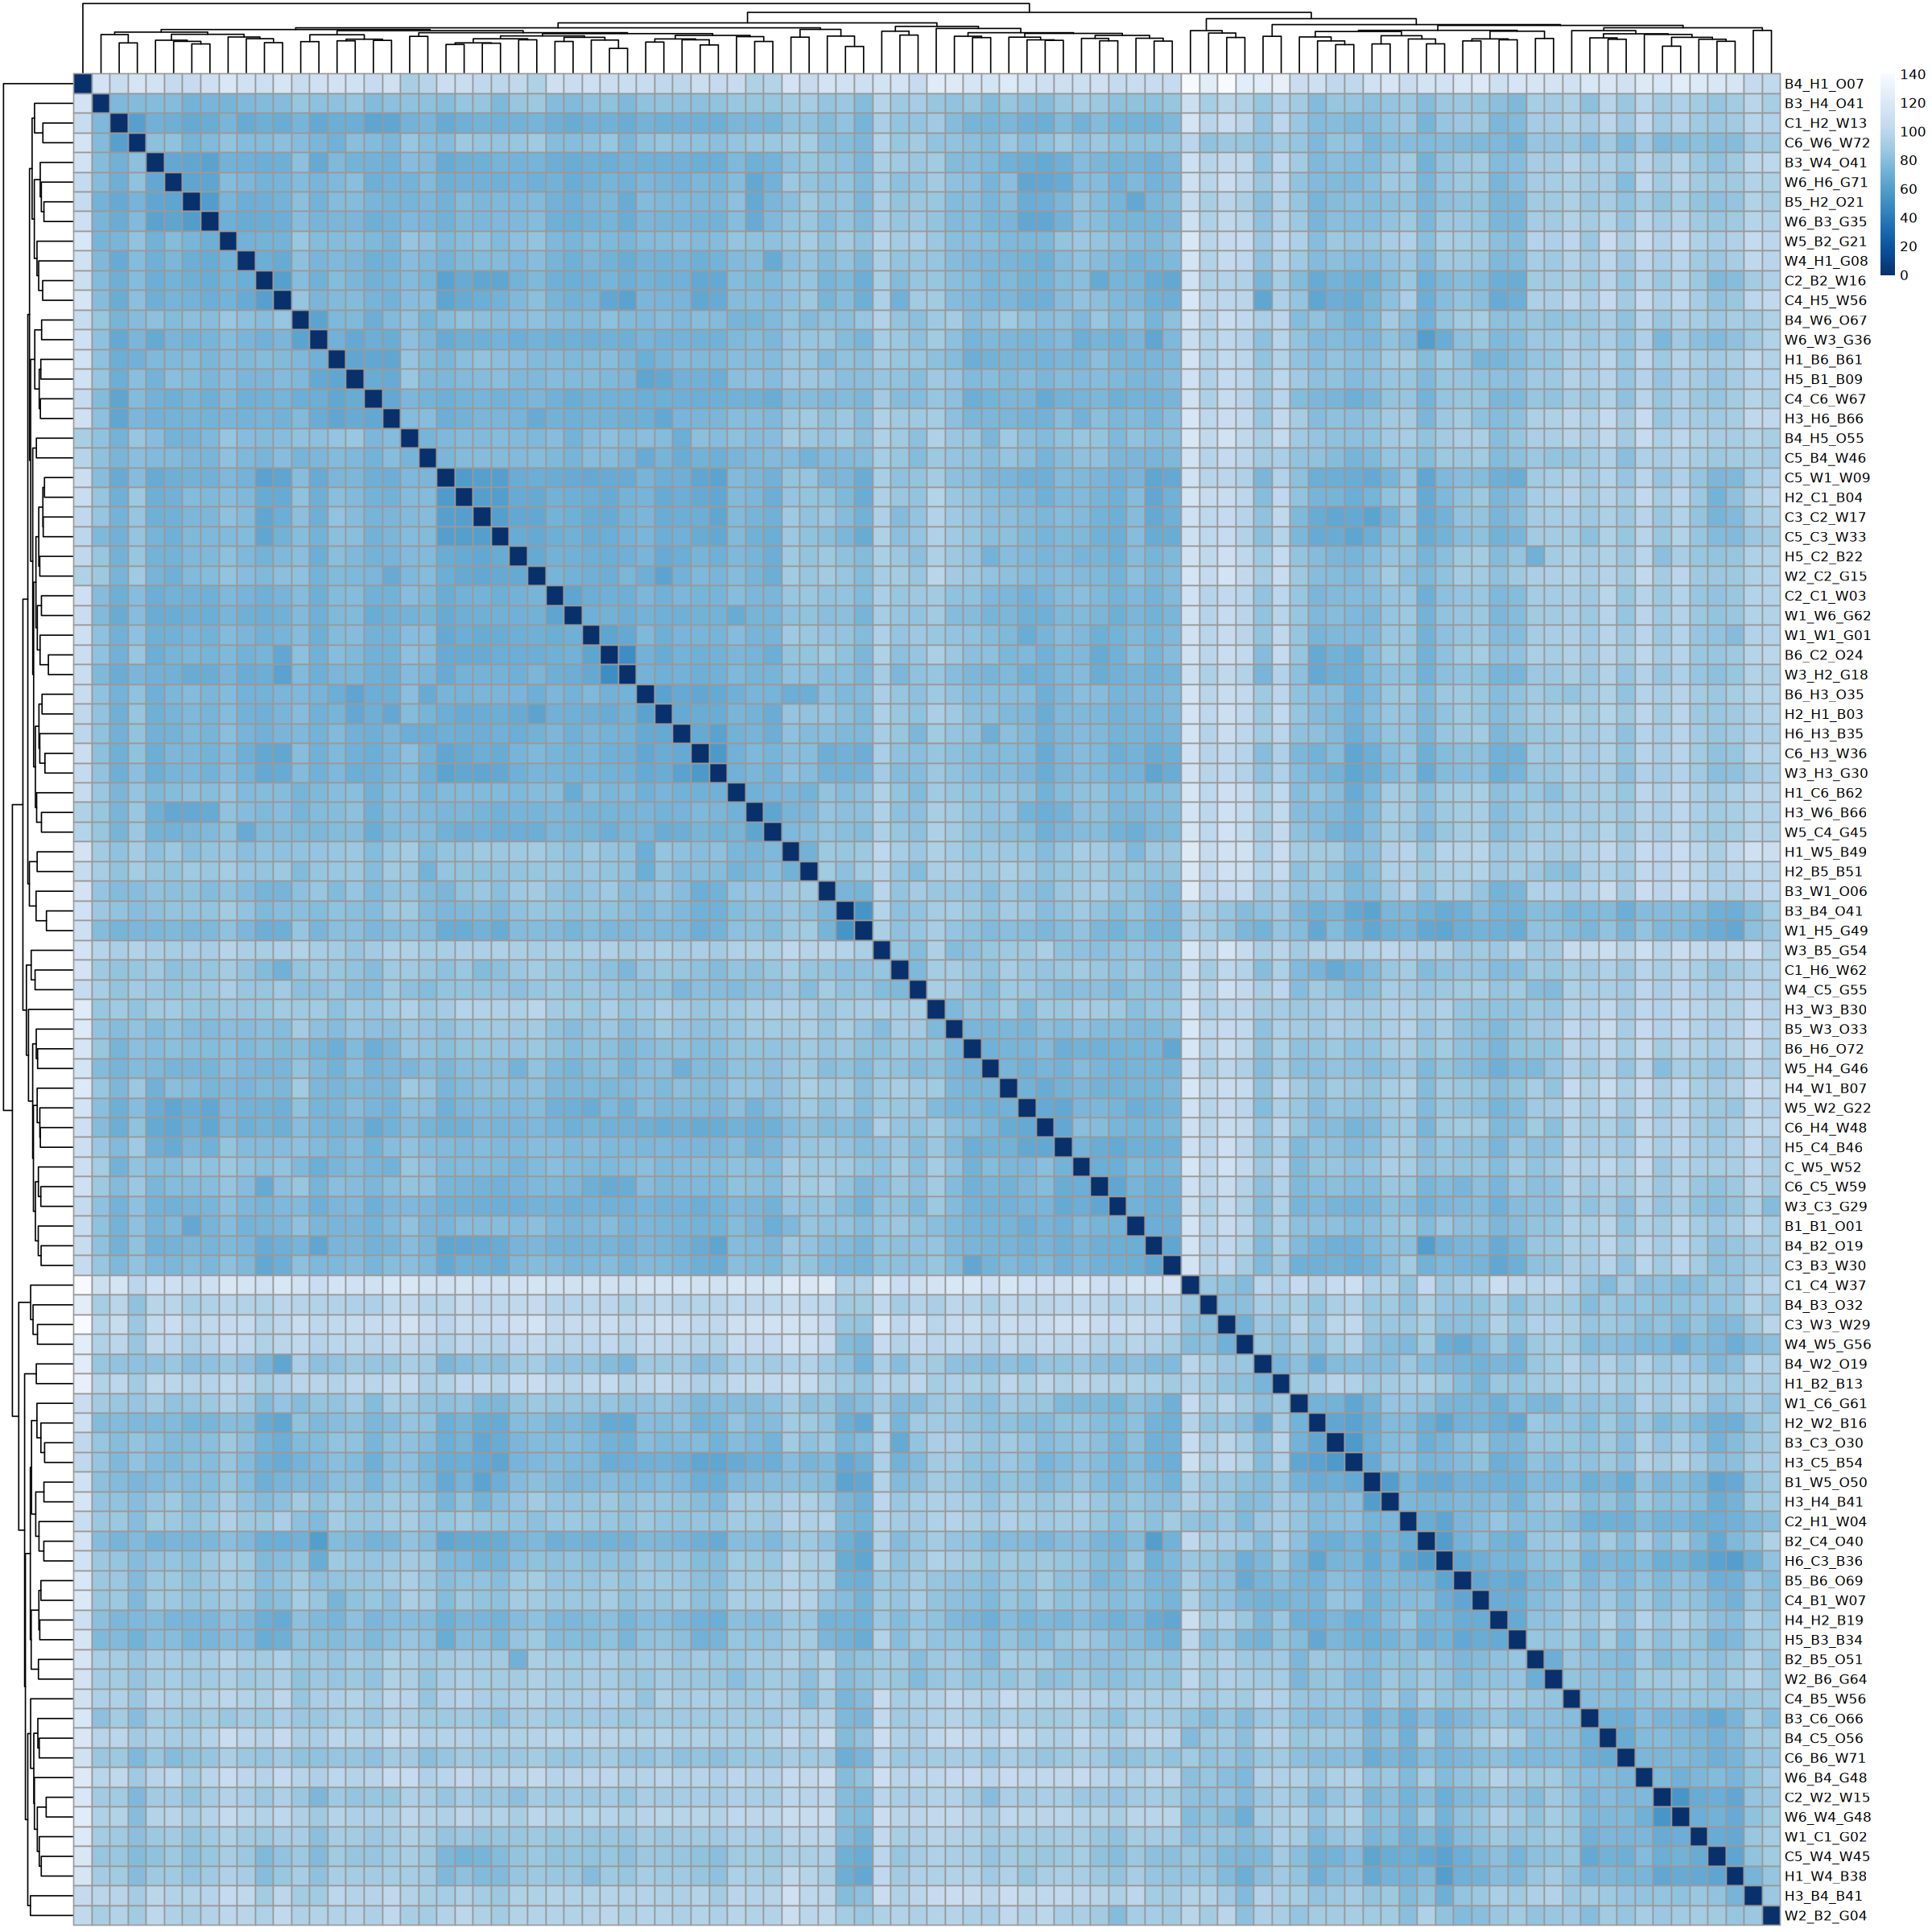

In [101]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

In [102]:
resultsNames(dds_rm)

[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

### MA plot
of one example comparison between HC and CC

In [103]:
# Unshrunken results for your contrast/interaction term
res <- results(dds_rm, contrast = c("complete_trtmt", "hypoxic.control", "control.control"))
# or for an interaction/complex contrast:
# res <- results(dds, name = "phase1stressorA.phase2stressorB")

# Shrunken with ashr — works with contrast= or name= directly, no coef restriction
res_shrunk <- lfcShrink(dds_rm, contrast = c("complete_trtmt", "hypoxic.control", "control.control"), type = "ashr")
# or: res_shrunk <- lfcShrink(dds, res = res, type = "ashr")

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041



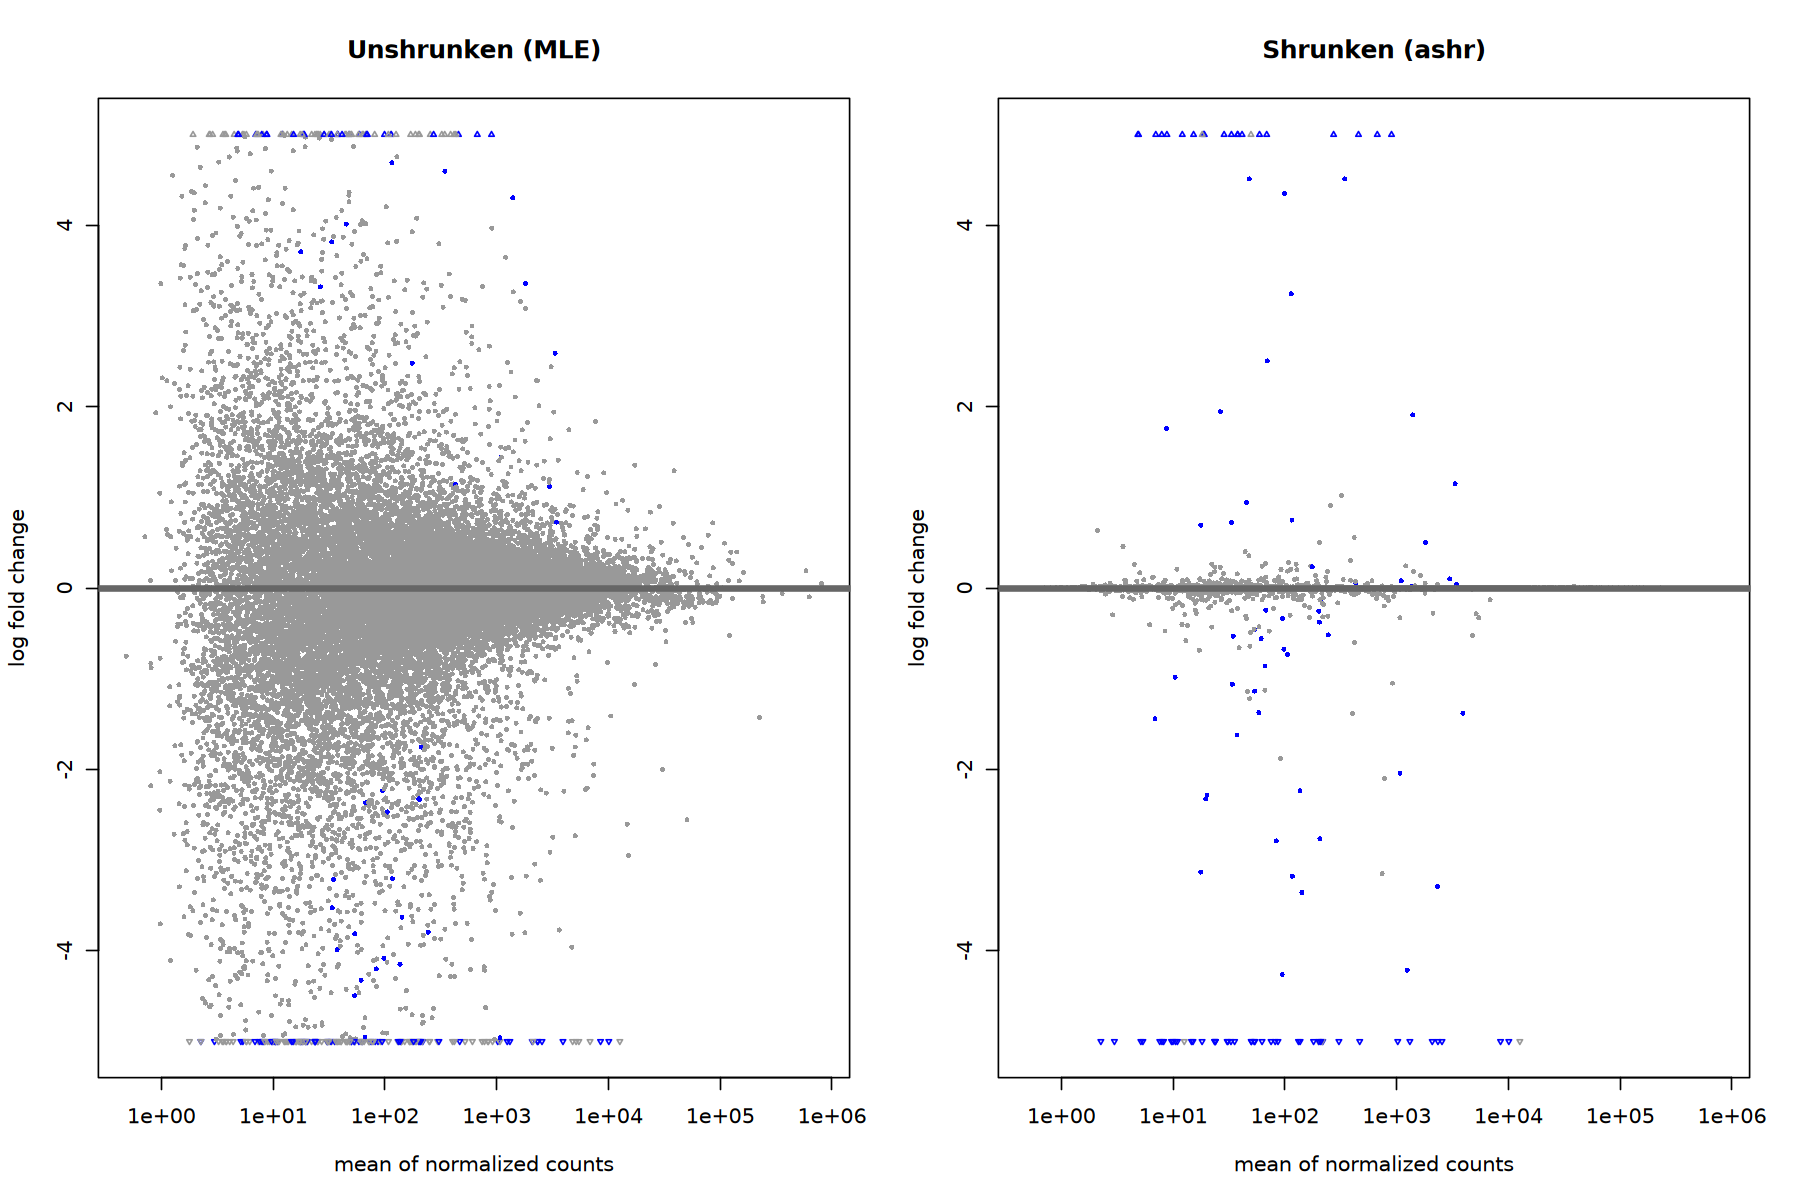

In [104]:
options(repr.plot.height = 10, repr.plot.width = 15)
par(mfrow = c(1, 2))
DESeq2::plotMA(res, ylim = c(-5, 5), main = "Unshrunken (MLE)")
DESeq2::plotMA(res_shrunk, ylim = c(-5, 5), main = "Shrunken (ashr)")

shrinking collapes the grey cloud to LFC = 0, so that genes with large LFC and low mean counts aren't showing up as DEGs (likely due to noise)

this shouldn't change the number of DEGs really - checking below:

In [105]:
sum(res$padj < 0.05, na.rm = TRUE)
sum(res_shrunk$padj < 0.05, na.rm = TRUE)  # should be ~identical to above

# now check with your actual FC cutoff
sum(res_shrunk$padj < 0.05 & abs(res_shrunk$log2FoldChange) > 1, na.rm = TRUE)
sum(res$padj < 0.05 & abs(res$log2FoldChange) > 1, na.rm = TRUE)  # unshrunken FC filter, for comparison

[1] 89

[1] 89

[1] 88

[1] 89

## Pairwise comparisons

### 1. Effect of single exposure on GE after a period of recovery
- CC vs. WC
- CC vs. HC
- CC vs. BC

**CC vs. WC**

In [106]:
options(repr.plot.width = 5, repr.plot.height = 10)

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 36, 0.14%
LFC < 0 (down)     : 47, 0.18%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.179339e-04,0.006541955,0.4740673,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-2.048231e-03,0.080618960,0.1807687,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-3.013050e-05,0.035182951,0.9673229,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-5.152407e-05,0.006206983,0.7616950,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,5.737408e-05,0.006094911,0.7649241,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,1.824889e-04,0.010947169,0.2903443,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


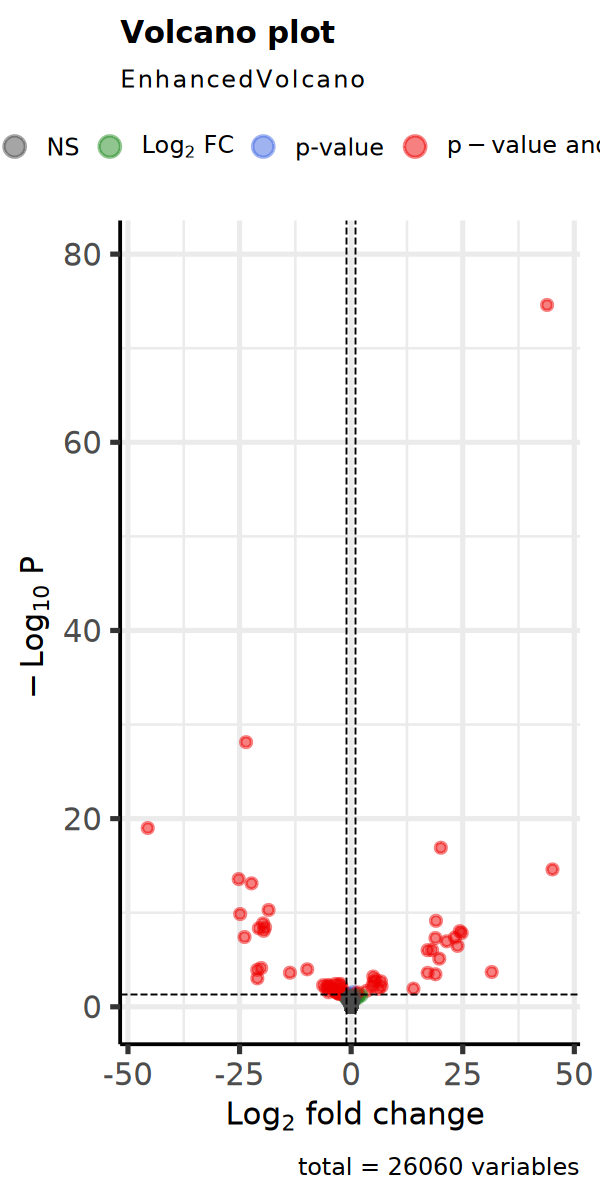

In [107]:
res.wc.cc <- lfcShrink(dds_rm, 
                       contrast= c('complete_trtmt', 'warm.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.wc.cc)

EnhancedVolcano(res.wc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.cc <- merge(res.wc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.cc)[1] <- 'Gene'

head(res.wc.cc)

In [108]:
write.csv(res.wc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_cc.csv', row.names = FALSE)

**CC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 40, 0.15%
LFC < 0 (down)     : 76, 0.29%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-3.765044e-04,0.010297747,0.08971541,0.9954698,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.038607e-02,0.200894300,0.04332045,0.8900849,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-2.002299e-05,0.036894515,0.98026881,1.0000000,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,3.563598e-05,0.006287678,0.83881860,1.0000000,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,2.432044e-05,0.006172941,0.90206951,1.0000000,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,1.562449e-05,0.007808631,0.91063338,1.0000000,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


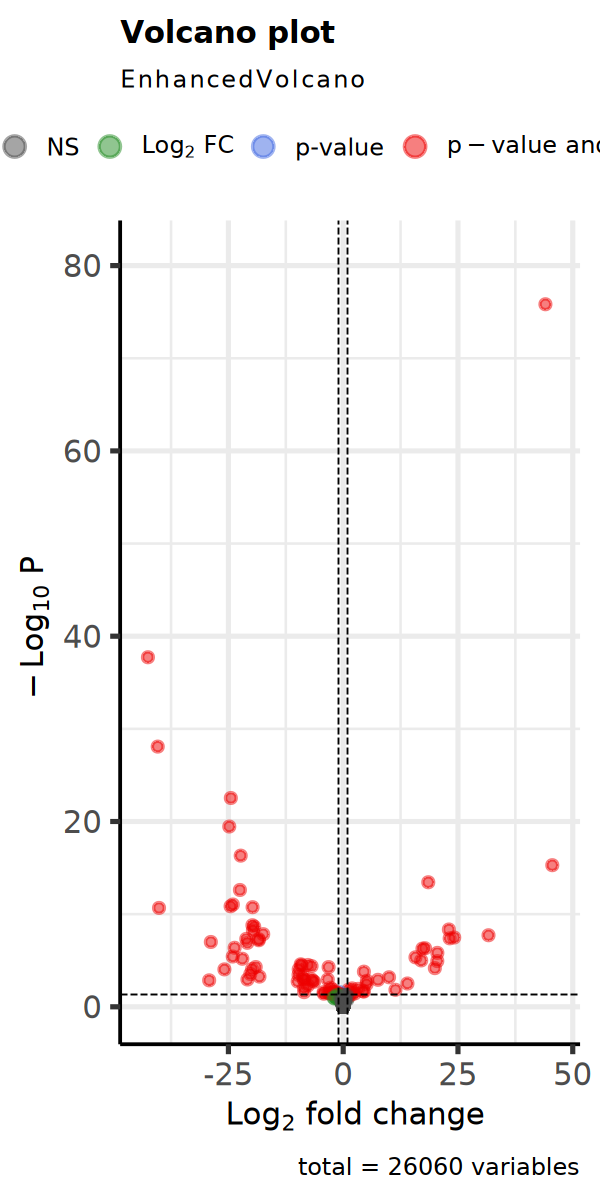

In [109]:
res.hc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.hc.cc)

EnhancedVolcano(res.hc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hc.cc <- merge(res.hc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hc.cc)[1] <- 'Gene'

head(res.hc.cc)

In [110]:
write.csv(res.hc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hc_cc.csv', row.names = FALSE)

**CC vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 34, 0.13%
LFC < 0 (down)     : 125, 0.48%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-3.349439e-04,0.010340079,0.11401440,1.0000000,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-5.419381e-04,0.048257667,0.63526456,1.0000000,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-1.129829e-02,0.217284064,0.06442549,0.9684062,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,1.570403e-05,0.006150221,0.92191594,1.0000000,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,4.241985e-05,0.006019574,0.81215222,1.0000000,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-6.546415e-06,0.008239433,0.96480623,1.0000000,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


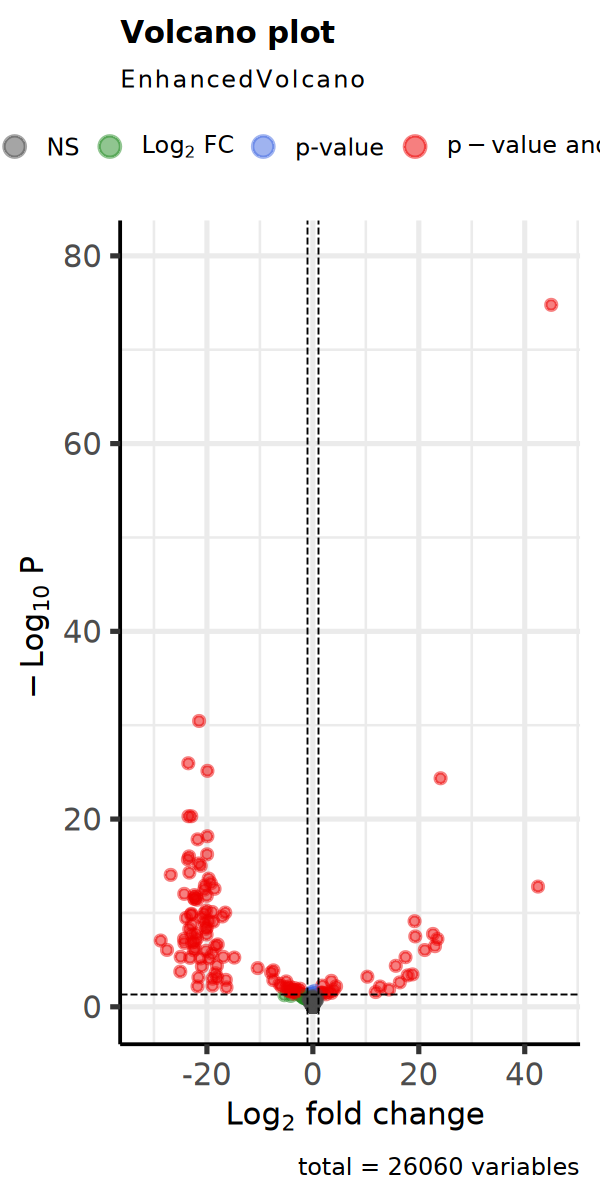

In [111]:
res.bc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.control', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.bc.cc)

EnhancedVolcano(res.bc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.cc <- merge(res.bc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.cc)[1] <- 'Gene'

head(res.bc.cc)

In [112]:
write.csv(res.bc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_cc.csv', row.names = FALSE)

### 2. Effect of single exposure experienced only later in life
- CC vs. CW
- CC vs. CH
- CC vs. CB

**CC vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 66, 0.25%
LFC < 0 (down)     : 59, 0.23%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0051205571,0.08203601,0.8529863,0.9925759,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0007926855,0.10061445,0.9003234,0.9960063,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0042140567,0.10978005,0.5168314,0.9566245,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0111521614,0.08122980,0.7033904,0.9822676,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0178753554,0.07930671,0.5828893,0.9673835,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0044158286,0.08611637,0.7950771,0.9907766,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


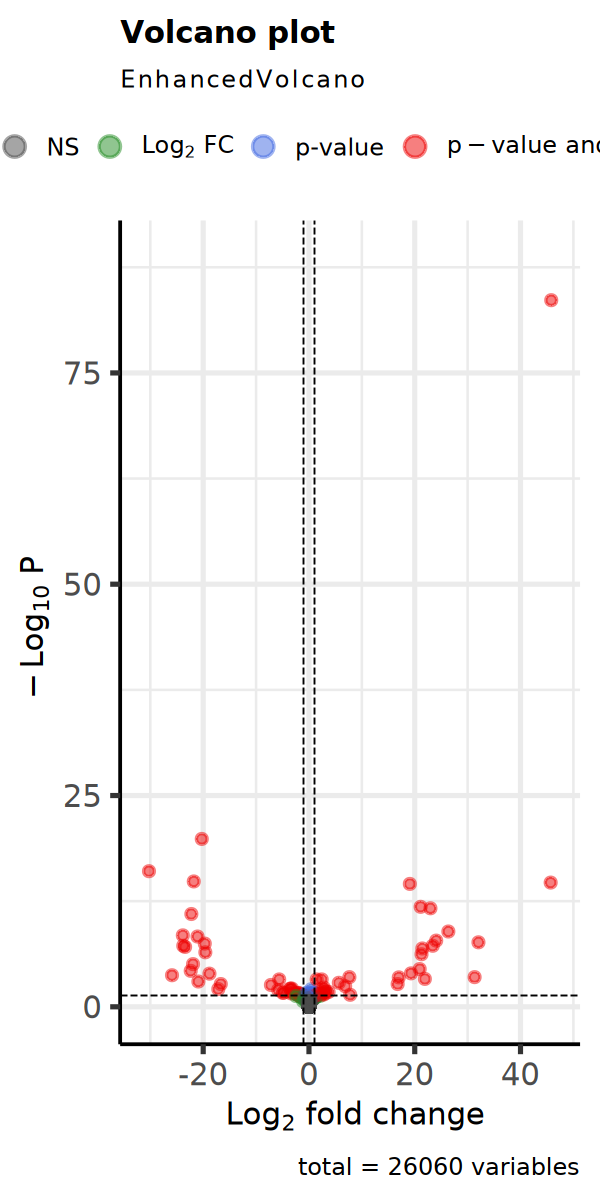

In [113]:
res.cw.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cw.cc)

EnhancedVolcano(res.cw.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.cc <- merge(res.cw.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.cc)[1] <- 'Gene'

head(res.cw.cc)

In [114]:
write.csv(res.cw.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_cc.csv', row.names = FALSE)

**CC vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 68, 0.26%
LFC < 0 (down)     : 90, 0.35%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.070930757,0.09676794,0.04968871,0.5975700,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.019703902,0.19914106,0.10165263,0.7040150,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.018491671,0.19907089,0.11335322,0.7326227,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.025706666,0.09176763,0.49000363,0.9142414,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.070005334,0.09108435,0.09113327,0.6891893,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.003035332,0.09857506,0.89172846,0.9919023,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


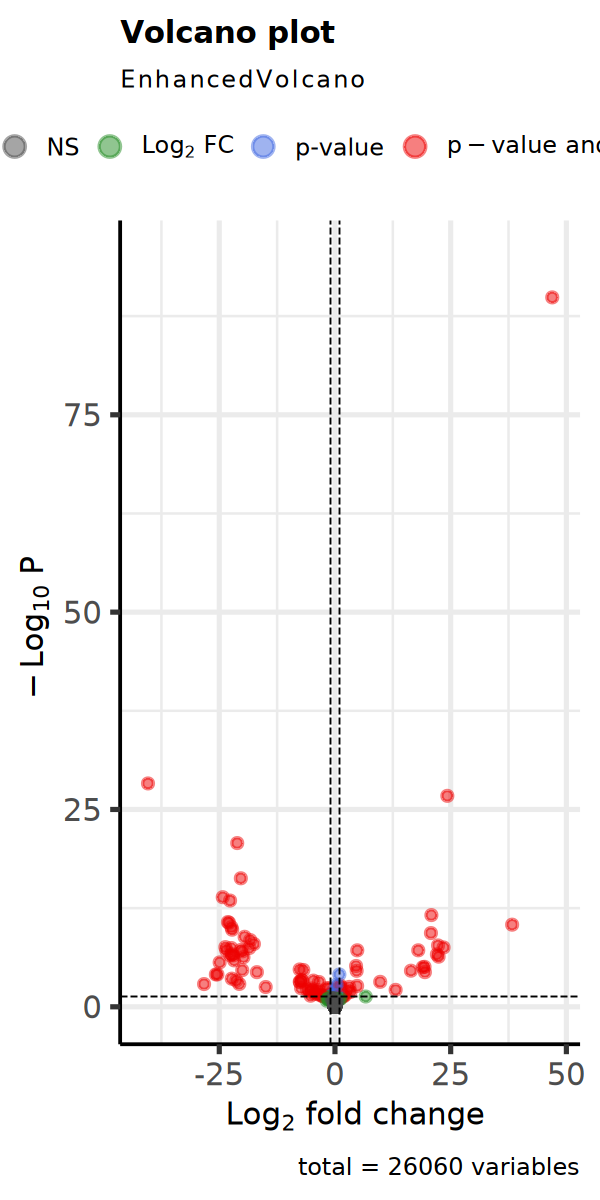

In [115]:
res.ch.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.ch.cc)

EnhancedVolcano(res.ch.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.cc <- merge(res.ch.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.cc)[1] <- 'Gene'

head(res.ch.cc)

In [116]:
write.csv(res.ch.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ch_cc.csv', row.names = FALSE)

**CC vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 187, 0.72%
LFC < 0 (down)     : 131, 0.5%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.058082738,0.1287892,0.3596544,0.8611038,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.022304960,0.1946707,0.2811688,0.8194038,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.019346132,0.1930048,0.3278018,0.8427093,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.004628419,0.1181792,0.9405551,0.9945862,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.069171806,0.1188631,0.2983289,0.8269712,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.010708199,0.1450949,0.8239284,0.9800276,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


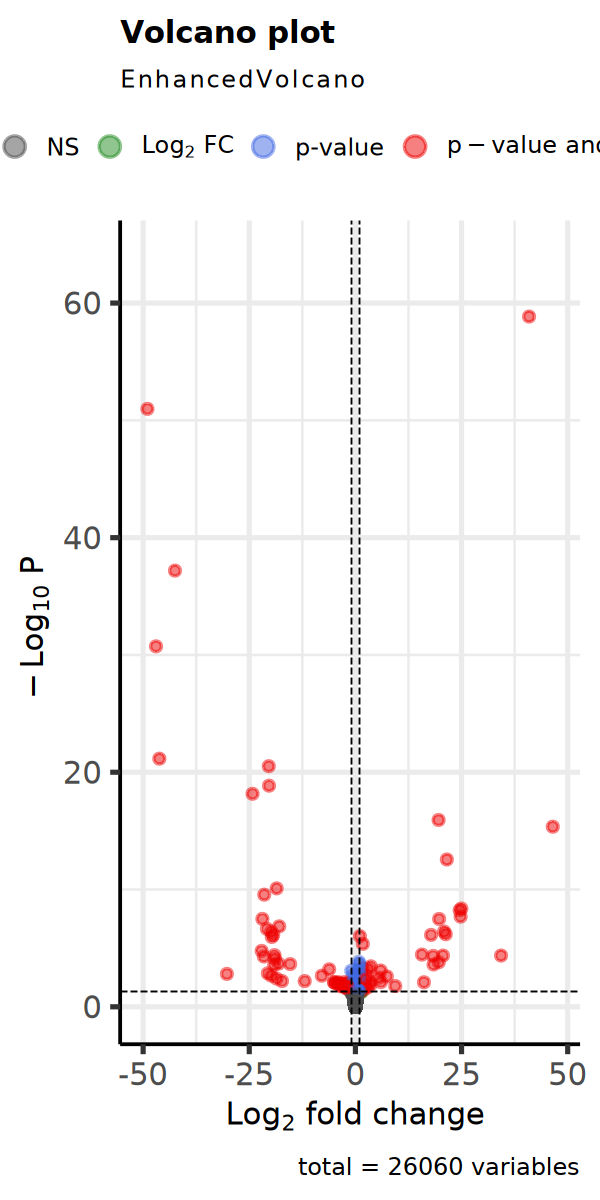

In [117]:
res.cb.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cb.cc)

EnhancedVolcano(res.cb.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cc <- merge(res.cb.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cc)[1] <- 'Gene'

head(res.cb.cc)

In [118]:
write.csv(res.cb.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_cc.csv', row.names = FALSE)

### 3. Timing of Stress Exposure
How does GE change depending on when stress is experienced (when all oysters only experience stress once)?
- CH vs. HC
- CW vs. WC
- CB vs. BC

**CH vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 73, 0.28%
LFC < 0 (down)     : 62, 0.24%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.482763e-03,0.03689489,0.79054036,0.9940248,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,9.307807e-04,0.06467325,0.70116255,0.9940248,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-8.306069e-03,0.15782157,0.11910113,0.8231865,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-5.389627e-03,0.03700568,0.37156685,0.9580931,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-1.281211e-02,0.03818560,0.06991535,0.7568051,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,7.845987e-05,0.03786878,0.98097984,1.0000000,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


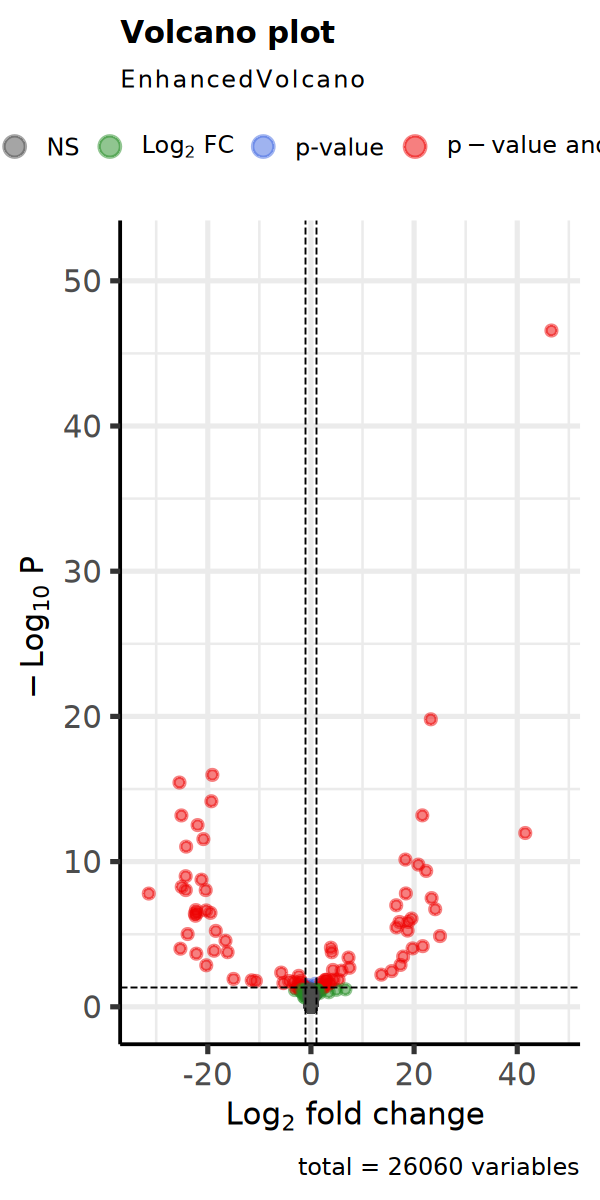

In [119]:
res.ch.hc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.ch.hc)

EnhancedVolcano(res.ch.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.hc <- merge(res.ch.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.hc)[1] <- 'Gene'

head(res.ch.hc)

In [120]:
write.csv(res.ch.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ch_hc.csv', row.names = FALSE)

**CW vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 128, 0.49%
LFC < 0 (down)     : 87, 0.33%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.042975043,0.1406935,0.5957833,0.8879751,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.027253157,0.2065082,0.2250764,0.6808359,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.012382735,0.1884655,0.5436898,0.8679806,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.006401293,0.1363609,0.9382251,0.9883659,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.072105056,0.1284955,0.3963519,0.8003431,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.047811361,0.1621113,0.4254483,0.8149512,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


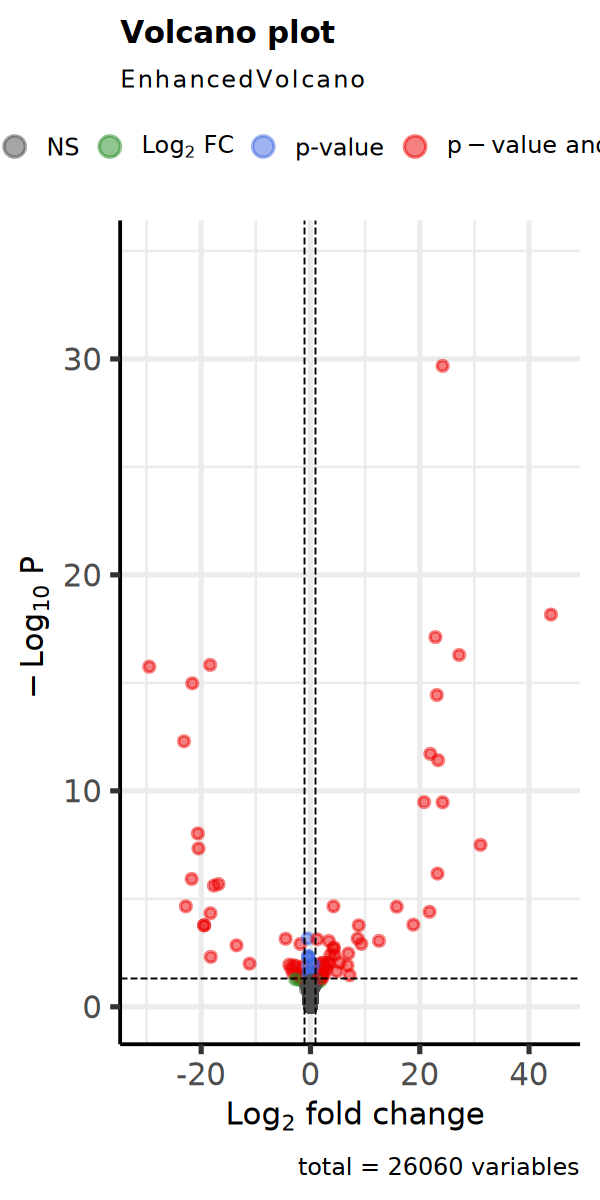

In [121]:
res.cw.wc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.cw.wc)

EnhancedVolcano(res.cw.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.wc <- merge(res.cw.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.wc)[1] <- 'Gene'

head(res.cw.wc)

In [122]:
write.csv(res.cw.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_wc.csv', row.names = FALSE)

**CB vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 297, 1.1%
LFC < 0 (down)     : 140, 0.54%
outliers [1]       : 78, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.040910549,0.1254197,0.47964908,0.8994960,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.010813996,0.1842994,0.58011332,0.9306294,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.221494069,0.9357886,0.00547945,0.1828065,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.001528453,0.1158050,0.97854988,0.9968726,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.045109403,0.1135849,0.45086633,0.8887551,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.011801381,0.1455958,0.79779897,0.9704631,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


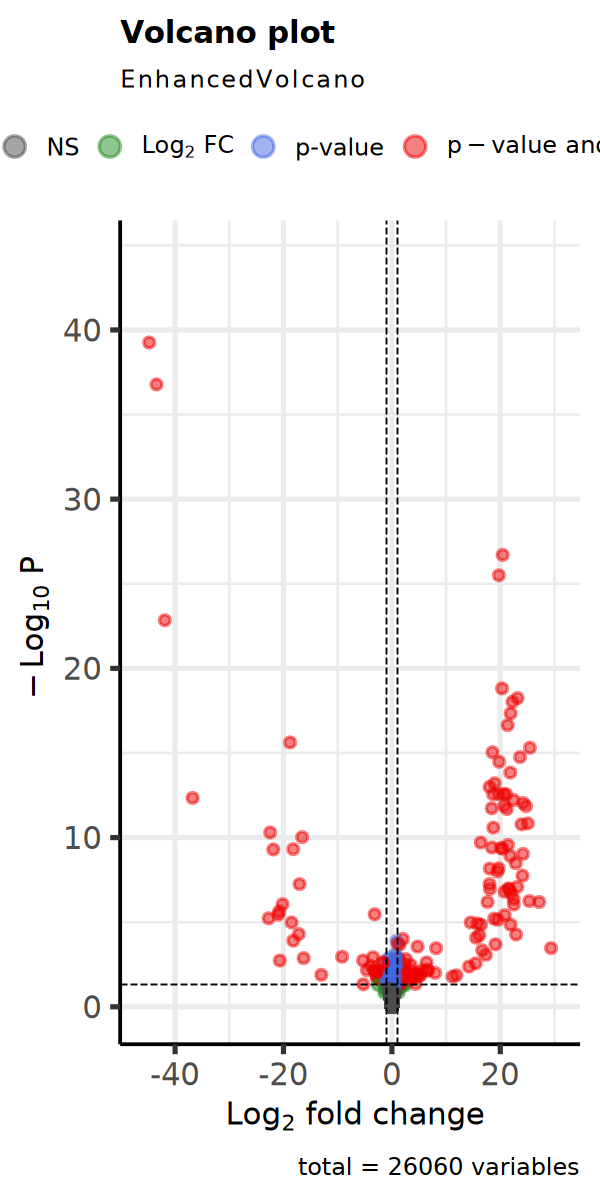

In [123]:
res.cb.bc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'both.control'), # BC is the "control"
                     type = 'ashr')

summary(res.cb.bc)

EnhancedVolcano(res.cb.bc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bc <- merge(res.cb.bc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bc)[1] <- 'Gene'

head(res.cb.bc)

In [124]:
write.csv(res.cb.bc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_bc.csv', row.names = FALSE)

### 4. No stress vs. most stress
- CC vs. WW
- CC vs. HH
- CC vs. BB

**CC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 57, 0.22%
LFC < 0 (down)     : 28, 0.11%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0012106347,0.03394433,0.7980503,0.9993605,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0005757083,0.05066444,0.7021257,0.9993605,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0002078130,0.05035253,0.8894102,0.9993605,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0064277679,0.03410581,0.2089342,0.9964366,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0042344242,0.03374043,0.4731121,0.9993605,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0018694874,0.03479294,0.4959870,0.9993605,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


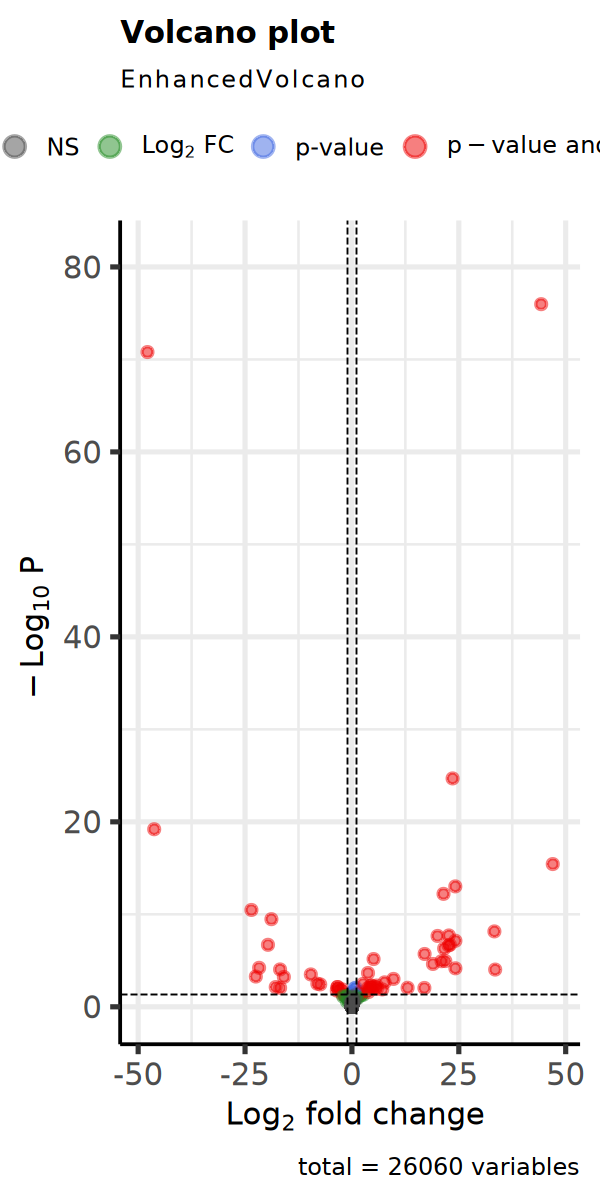

In [125]:
res.cc.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.ww)

EnhancedVolcano(res.cc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.ww <- merge(res.cc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.ww)[1] <- 'Gene'

head(res.cc.ww)

In [126]:
write.csv(res.cc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ww_cc.csv', row.names = FALSE)

**CC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 76, 0.29%
LFC < 0 (down)     : 138, 0.53%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0439720423,0.08987930,0.1312979,0.7277371,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0171545581,0.20026915,0.1085330,0.6940705,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0009139569,0.10911260,0.8918881,0.9904712,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0062181625,0.08338513,0.8326876,0.9842157,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0011795553,0.08058722,0.9707269,0.9992507,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0064606014,0.09017936,0.7159532,0.9695904,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


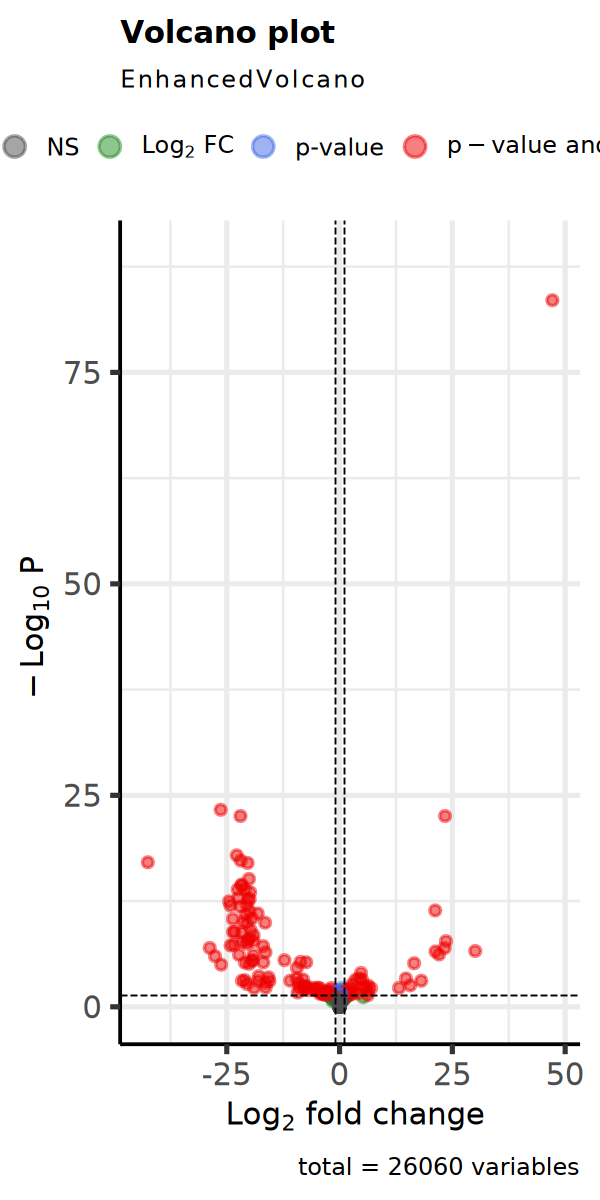

In [127]:
res.cc.hh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr')

summary(res.cc.hh)

EnhancedVolcano(res.cc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.hh <- merge(res.cc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.hh)[1] <- 'Gene'

head(res.cc.hh)

In [128]:
write.csv(res.cc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hh_cc.csv', row.names = FALSE)

**CC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 59, 0.23%
LFC < 0 (down)     : 113, 0.43%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.033450923,0.10024624,0.4060442,0.8949663,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.007913147,0.14787825,0.5347197,0.9337169,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.008537284,0.15201180,0.4970282,0.9231507,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.003767546,0.09675251,0.9278622,0.9959662,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.004096765,0.09309425,0.9274315,0.9959662,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.007487776,0.10920871,0.7832450,0.9794562,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


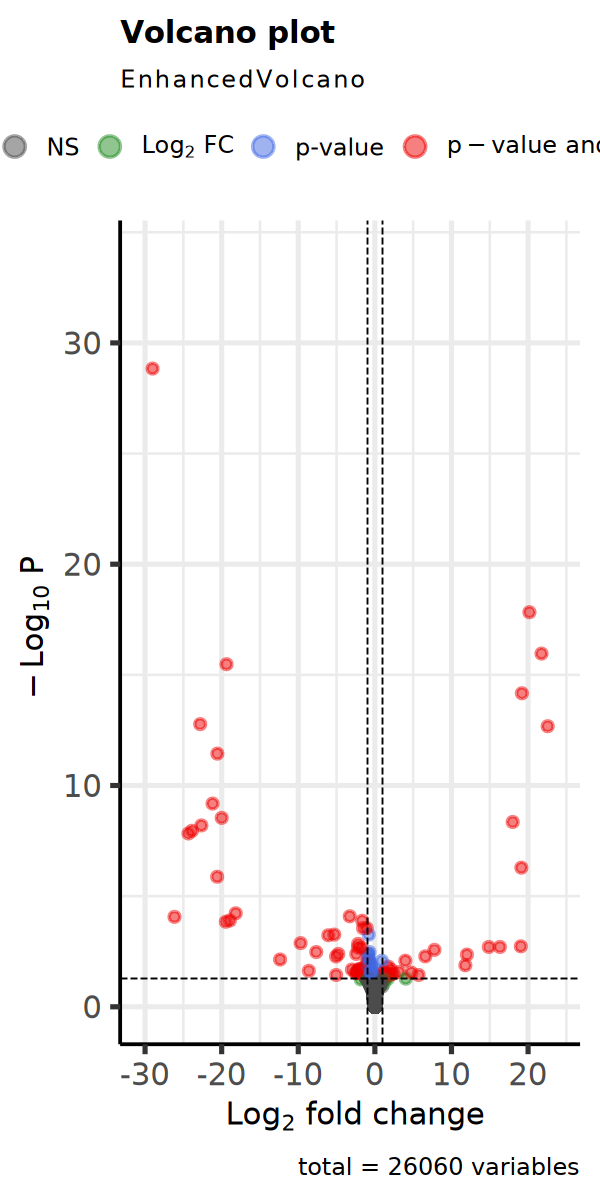

In [129]:
res.cc.bb <- lfcShrink(dds_rm, coef='complete_trtmt_control.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.cc.bb)

EnhancedVolcano(res.cc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.bb <- merge(res.cc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.bb)[1] <- 'Gene'

head(res.cc.bb)

switch LFC direction so CC is the baseline (deseq recognizes as bb as the baseline rn)

In [130]:
cc.bb.df <- as.data.frame(res.cc.bb) %>% # create df
mutate(log2FoldChange = log2FoldChange * -1) # multiple by -1 to make pos to neg and vice versa 

# validate
head(res.cc.bb)
head(cc.bb.df)

,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.033450923,0.10024624,0.4060442,0.8949663,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.007913147,0.14787825,0.5347197,0.9337169,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.008537284,0.15201180,0.4970282,0.9231507,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.003767546,0.09675251,0.9278622,0.9959662,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.004096765,0.09309425,0.9274315,0.9959662,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.007487776,0.10920871,0.7832450,0.9794562,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.033450923,0.10024624,0.4060442,0.8949663,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.007913147,0.14787825,0.5347197,0.9337169,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.008537284,0.15201180,0.4970282,0.9231507,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.003767546,0.09675251,0.9278622,0.9959662,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.004096765,0.09309425,0.9274315,0.9959662,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.007487776,0.10920871,0.7832450,0.9794562,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


In [131]:
write.csv(cc.bb.df, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bb_cc.csv', row.names = FALSE)

### 5. Effect of initial exposure on response in later exposure
(also gets at the effect of priming to stress)

#### 5A. Matched stressors
Oyster is primed with a stress, and experiences the *same* stressor again
- HH vs. CH
- WW vs. CW
- BB vs. CB

**HH vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 91, 0.35%
LFC < 0 (down)     : 180, 0.69%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.0001224203,0.009501357,0.71715564,0.9990569,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0001753403,0.081604980,0.96481311,0.9990569,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0234499152,0.291842157,0.09982335,0.8638497,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0003264713,0.010623760,0.38462140,0.9990569,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0008113741,0.014906493,0.11545665,0.8880387,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0001125897,0.015116838,0.81493917,0.9990569,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


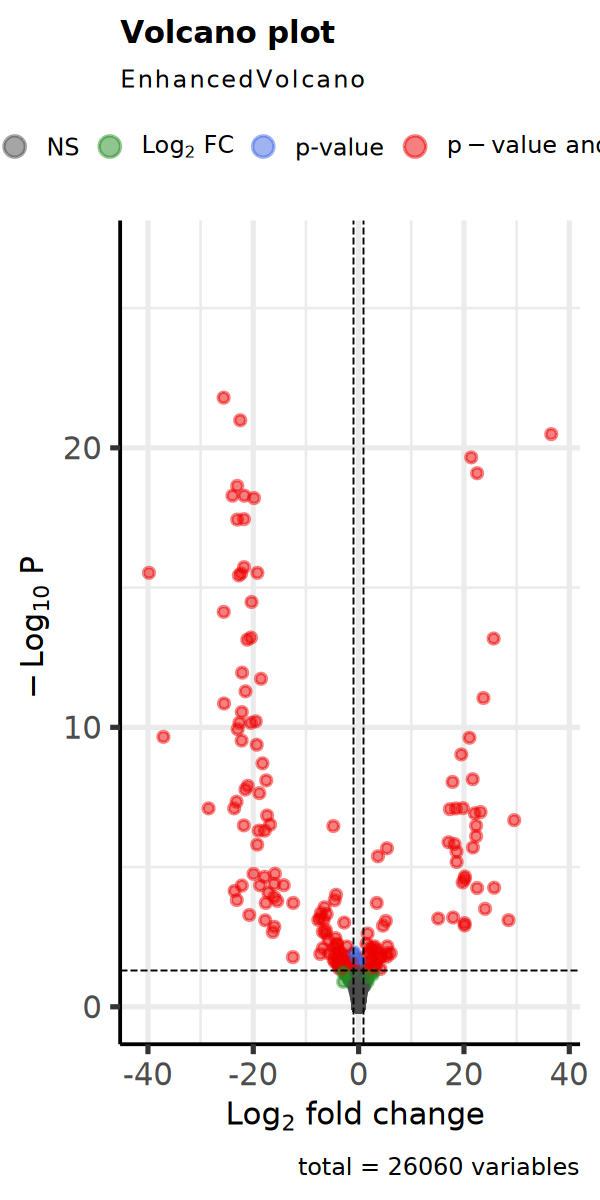

In [132]:
res.hh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.hh.ch)

EnhancedVolcano(res.hh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.ch <- merge(res.hh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.ch)[1] <- 'Gene'

head(res.hh.ch)

In [133]:
write.csv(res.hh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hh_ch.csv', row.names = FALSE)

**WW vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 39, 0.15%
LFC < 0 (down)     : 29, 0.11%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.162237e-05,0.006336226,0.9437705,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.653181e-04,0.032883906,0.7970248,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,3.836443e-04,0.039236734,0.6106045,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-1.585793e-04,0.006681831,0.3814544,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-3.313358e-05,0.006164790,0.8664020,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,6.040154e-05,0.008197583,0.6740002,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


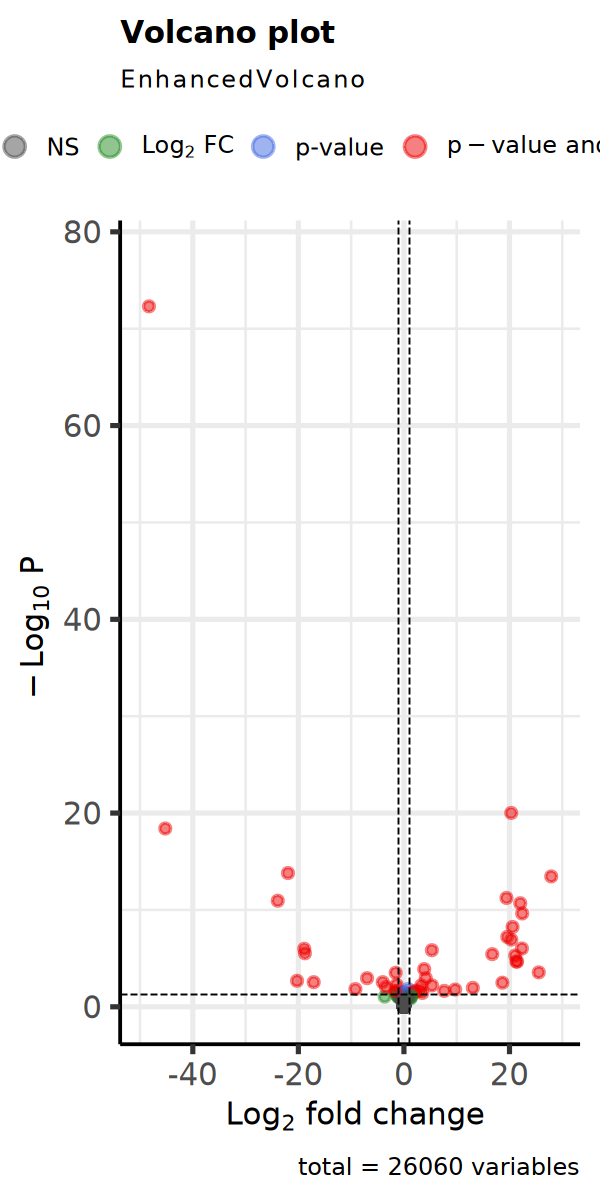

In [134]:
res.ww.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.ww.cw)

EnhancedVolcano(res.ww.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ww.cw <- merge(res.ww.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ww.cw)[1] <- 'Gene'

head(res.ww.cw)

In [135]:
write.csv(res.ww.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/ww_cw.csv', row.names = FALSE)

**BB vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 36, 0.14%
LFC < 0 (down)     : 67, 0.26%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-2.141232e-05,0.007828547,0.9321115,0.9991327,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-6.406451e-04,0.051440835,0.6477461,0.9991327,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,4.331826e-04,0.051177420,0.7646137,0.9991327,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,4.365838e-05,0.007726063,0.8689056,0.9991327,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,3.560654e-04,0.008402824,0.2580265,0.9991327,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,1.214684e-04,0.010941341,0.6189889,0.9991327,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


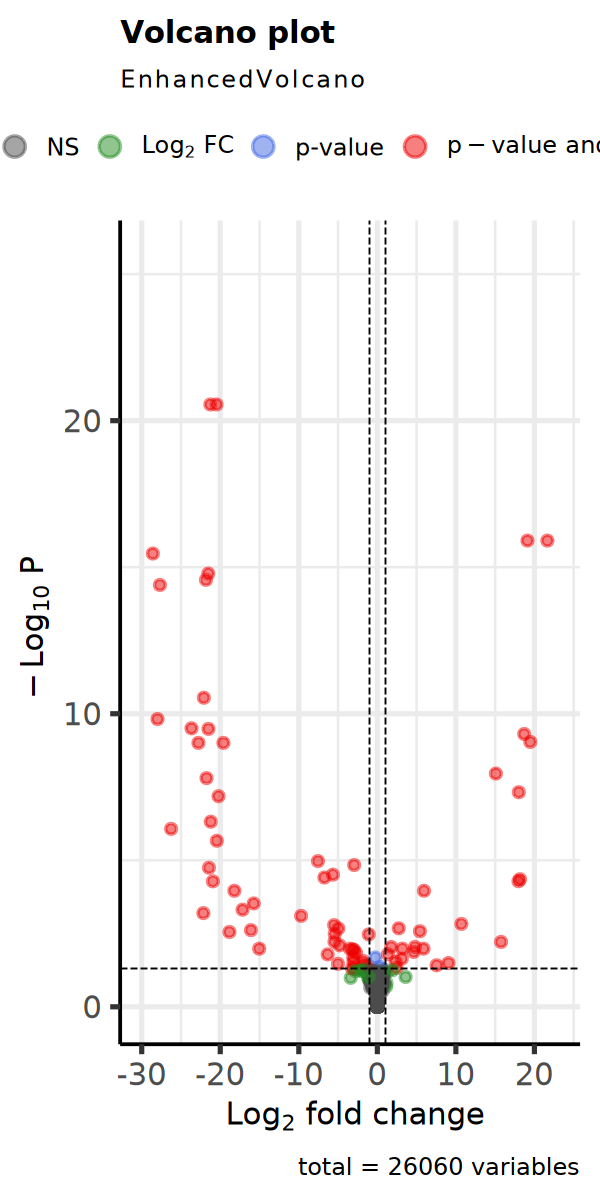

In [136]:
res.cb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_control.both_vs_both.both', # BB is the "control"
                       type = 'ashr')

summary(res.cb.bb)

EnhancedVolcano(res.cb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bb <- merge(res.cb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bb)[1] <- 'Gene'

head(res.cb.bb)

In [137]:
write.csv(res.cb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_bb.csv', row.names = FALSE)

#### 5B. Semi-matched priming: in context of later *single* stress
- CH vs. BH
- CW vs. BW

**CH vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 670, 2.6%
LFC < 0 (down)     : 492, 1.9%
outliers [1]       : 78, 0.3%
low counts [2]     : 1011, 3.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.02697541,0.1545749,0.78124273,0.9371539,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.03567532,0.2741716,0.39276041,0.7391160,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.04941659,0.3071542,0.25338899,0.6282882,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.11844344,0.1620947,0.24921270,0.6238427,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.33143306,0.1650361,0.00542325,0.1084259,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.07608641,0.2026817,0.40131941,0.7447121,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


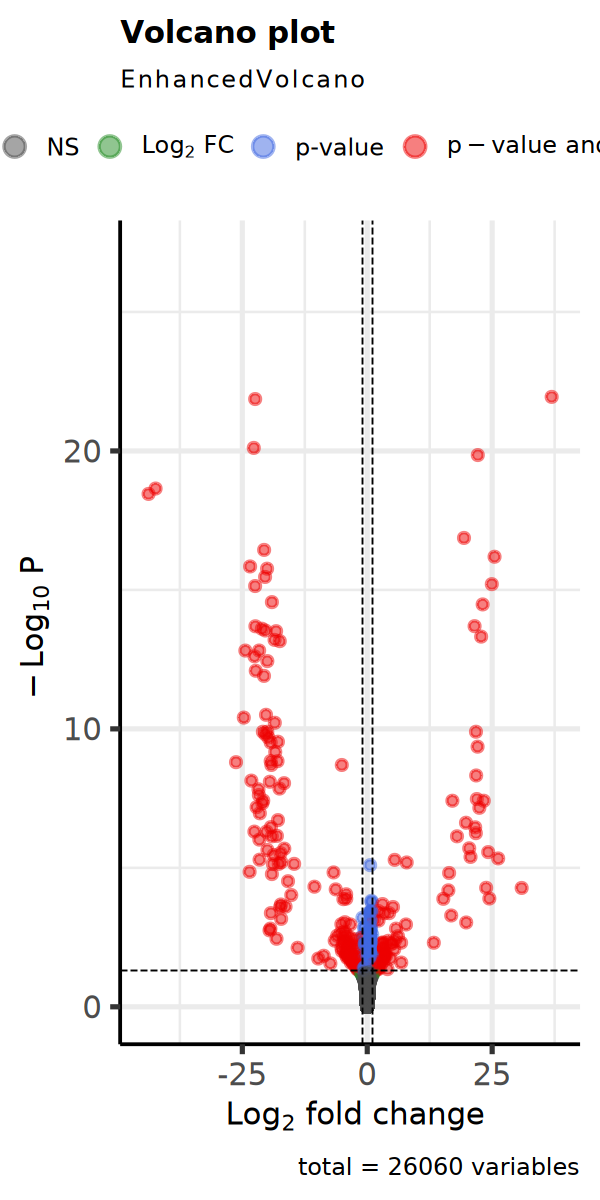

In [138]:
res.bh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.bh.ch)

EnhancedVolcano(res.bh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bh.ch <- merge(res.bh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bh.ch)[1] <- 'Gene'

head(res.bh.ch)

In [139]:
write.csv(res.bh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bh_ch.csv', row.names = FALSE)

**CW vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 44, 0.17%
LFC < 0 (down)     : 112, 0.43%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0027515749,0.04285395,0.7149438,0.9868538,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0054687030,0.11788128,0.2015291,0.8628236,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0033380889,0.09533060,0.3466404,0.9222922,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0052059094,0.04276436,0.5203953,0.9628972,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0055731793,0.04241146,0.5499678,0.9667319,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0002322858,0.04388375,0.9580553,0.9989460,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


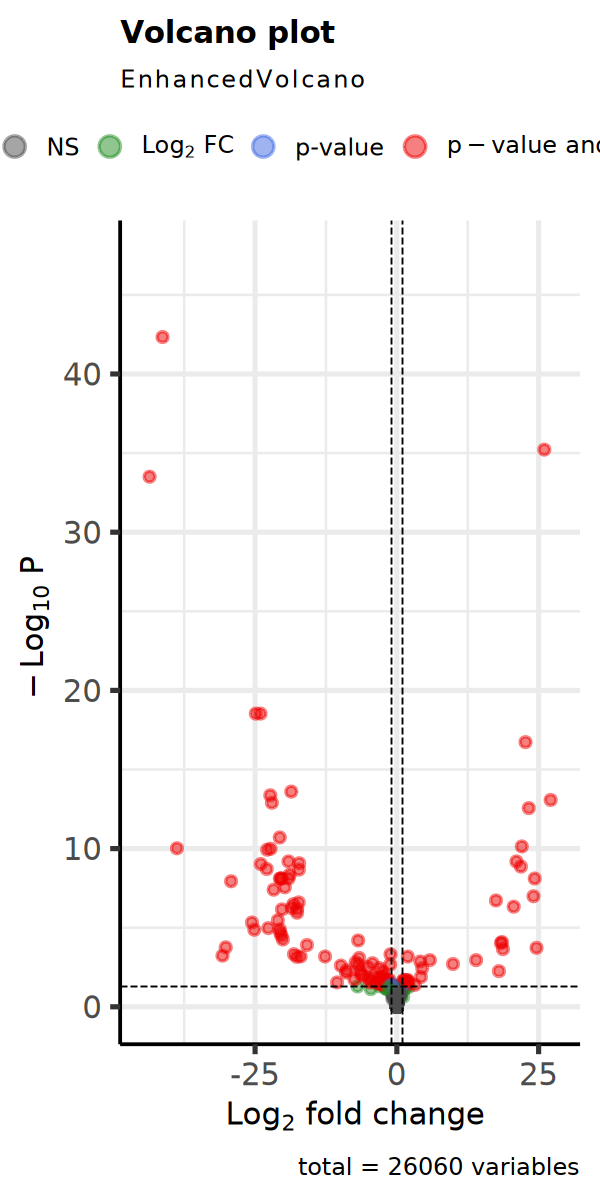

In [140]:
res.bw.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.bw.cw)

EnhancedVolcano(res.bw.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.cw <- merge(res.bw.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.cw)[1] <- 'Gene'

head(res.bw.cw)

In [141]:
write.csv(res.bw.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bw_cw.csv', row.names = FALSE)

#### 5C. Semi-matched priming: in context of later *multiple* stress
- CB vs. WB
- CB vs. HB

**CB vs. WB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 234, 0.9%
LFC < 0 (down)     : 75, 0.29%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,7.341953e-05,0.01016275,0.8598315,0.9959086,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,2.378662e-03,0.12294710,0.7903716,0.9925369,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,2.546427e-03,0.13097554,0.7921440,0.9925369,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-7.348327e-04,0.01681553,0.2327436,0.8723119,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-3.176207e-04,0.01021424,0.4396038,0.9527413,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,8.148620e-04,0.02696975,0.4745126,0.9601041,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


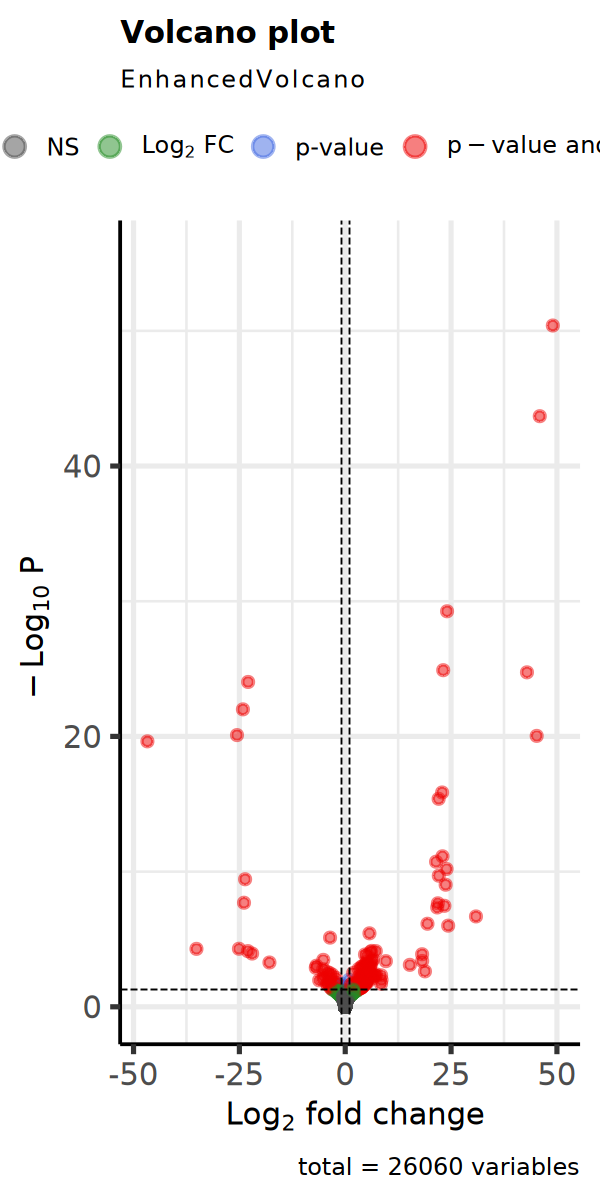

In [142]:
res.wb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.wb.cb)

EnhancedVolcano(res.wb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.cb <- merge(res.wb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.cb)[1] <- 'Gene'

head(res.wb.cb)

In [143]:
write.csv(res.wb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_cb.csv', row.names = FALSE)

**CB vs. HB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 65, 0.25%
LFC < 0 (down)     : 46, 0.18%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.042564e-04,0.006583904,0.5386111,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,3.060514e-04,0.038033215,0.7015719,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-7.345608e-05,0.037256866,0.9286746,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-8.223758e-05,0.006379112,0.6421521,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,3.003197e-05,0.006180847,0.8794780,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-4.513574e-05,0.008085406,0.7534552,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


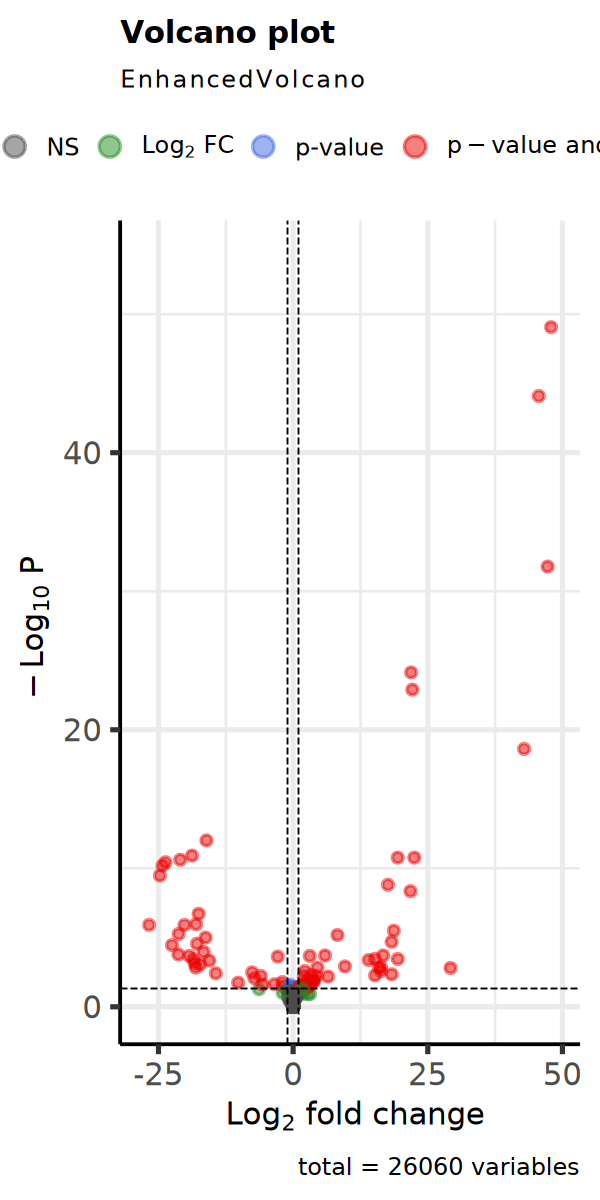

In [144]:
res.hb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.both', 'control.both'), # CB is the "control"
                       type = 'ashr')

summary(res.hb.cb)

EnhancedVolcano(res.hb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.cb <- merge(res.hb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.cb)[1] <- 'Gene'

head(res.hb.cb)

In [145]:
write.csv(res.hb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_cb.csv', row.names = FALSE)

### 6. Effect of initial exposure on subsequent response to stress
Oysters all experience the same early stressor, but either return to that stressor or experience control conditions
- HC vs. HH
- WC vs. WW
- BB vs. BC

**HC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 150, 0.58%
LFC < 0 (down)     : 111, 0.43%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0020240342,0.06889116,0.9132127,0.9936949,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0020455825,0.10541210,0.7476196,0.9807954,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0010137994,0.10643929,0.8732816,0.9900241,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0003427056,0.06837931,0.9862107,0.9995353,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0034459103,0.06723882,0.8775968,0.9907667,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0028879819,0.07174904,0.7973815,0.9854605,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


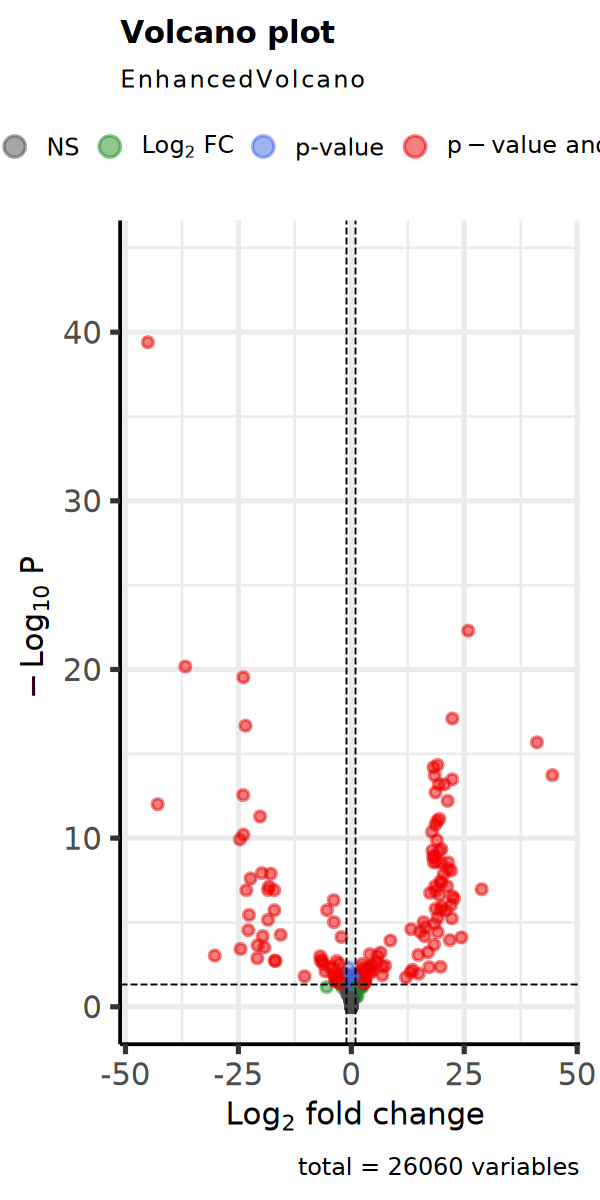

In [146]:
res.hc.hh <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.control', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hc.hh)

EnhancedVolcano(res.hc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hc.hh <- merge(res.hc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hc.hh)[1] <- 'Gene'

head(res.hc.hh)

In [147]:
write.csv(res.hc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hc_hh.csv', row.names = FALSE)

**WC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 57, 0.22%
LFC < 0 (down)     : 82, 0.31%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.030761018,0.1278540,0.6455216,0.9141027,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.016693973,0.1770968,0.3390998,0.7857133,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.001567873,0.1640006,0.9218713,0.9845875,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.065996723,0.1258983,0.3406664,0.7869297,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.073502678,0.1190999,0.3094329,0.7686995,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.017879721,0.1438255,0.7064518,0.9341546,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


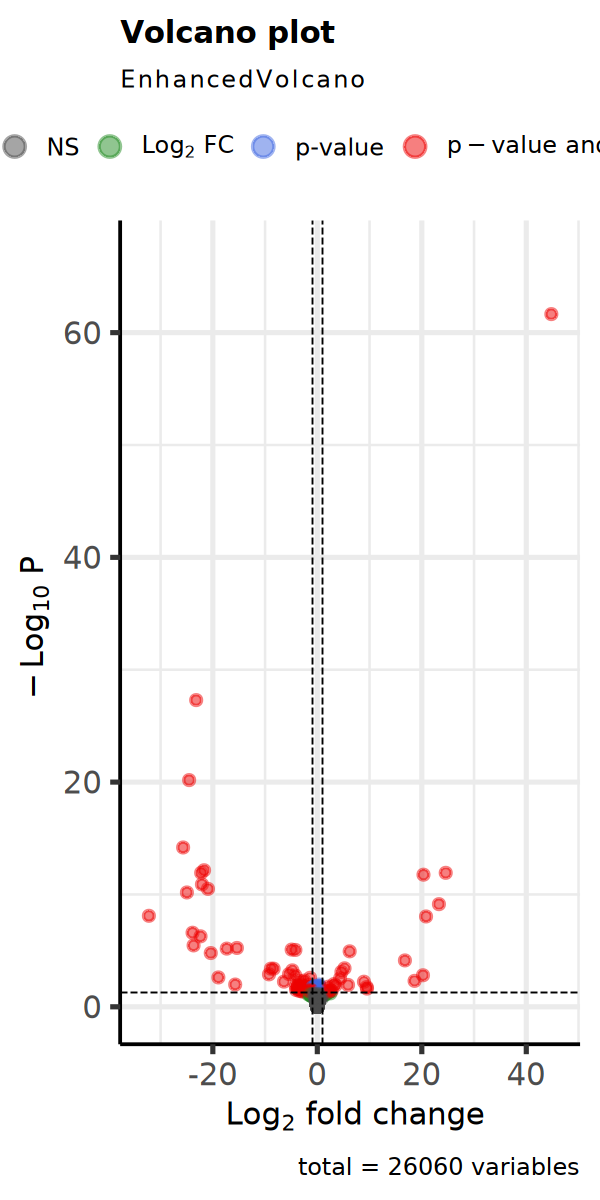

In [148]:
res.wc.ww <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.control', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.wc.ww)

EnhancedVolcano(res.wc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.ww <- merge(res.wc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.ww)[1] <- 'Gene'

head(res.wc.ww)

In [149]:
write.csv(res.wc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_ww.csv', row.names = FALSE)

**BC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 69, 0.26%
LFC < 0 (down)     : 302, 1.2%
outliers [1]       : 78, 0.3%
low counts [2]     : 1011, 3.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.021120489,0.08566805,0.43061814,0.9272835,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.001186708,0.13026102,0.90639129,0.9927329,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.183960137,0.87271215,0.01264806,0.2946484,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.004947648,0.07973328,0.85376981,0.9898510,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.009276737,0.07651488,0.74557294,0.9828802,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.004004393,0.09180847,0.82730755,0.9887083,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


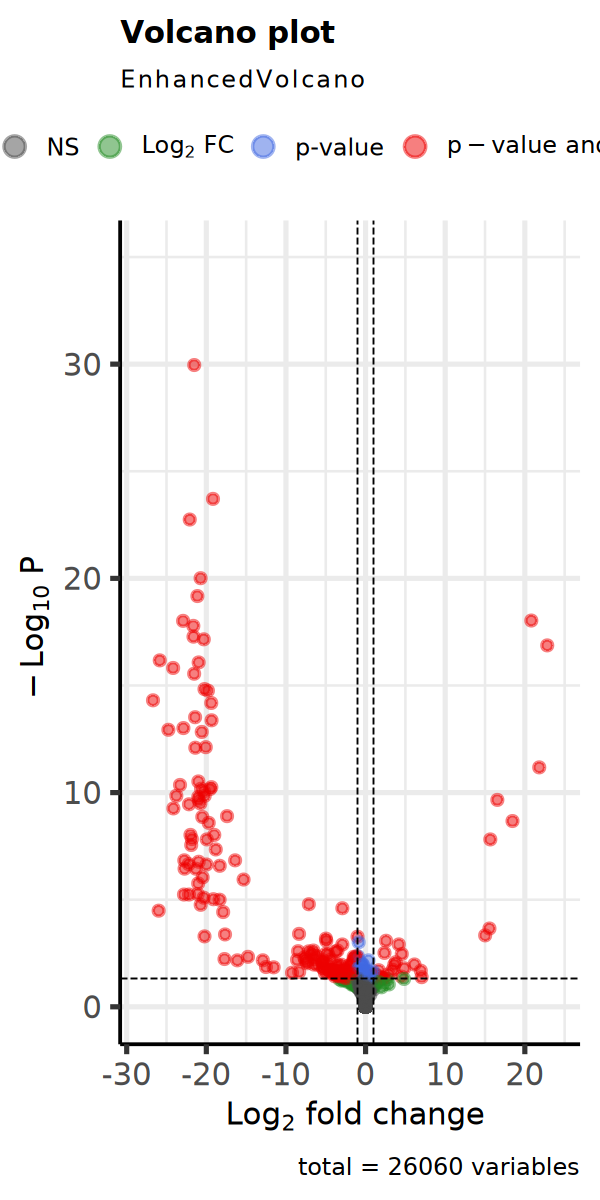

In [150]:
res.bc.bb <- lfcShrink(dds_rm, coef = 'complete_trtmt_both.control_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.bc.bb)

EnhancedVolcano(res.bc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.bb <- merge(res.bc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.bb)[1] <- 'Gene'

head(res.bc.bb)

In [151]:
write.csv(res.bc.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_bb.csv', row.names = FALSE)

### 7. Effect of initial single/multiple stress on response in ...
Is it better to be primed with a single stressor or multiple stressor, depending on the context of the future enviornment (single/multiple stressor)?

#### 7A. ...later *single* stress
Oyster is primed with either multiple or a single stressors, and then experiences only a sinlge stressor later
- BH vs. HH
- BW vs. WW

**BH vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 393, 1.5%
LFC < 0 (down)     : 282, 1.1%
outliers [1]       : 78, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.008574018,0.1501298,0.92247552,0.9872407,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.022441082,0.2286692,0.44085577,0.8250986,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.015430157,0.2252548,0.57768574,0.8819817,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.198000689,0.1686585,0.04916306,0.3844587,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.098964365,0.1428215,0.28130588,0.7213614,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.041578505,0.1843356,0.57103901,0.8798906,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


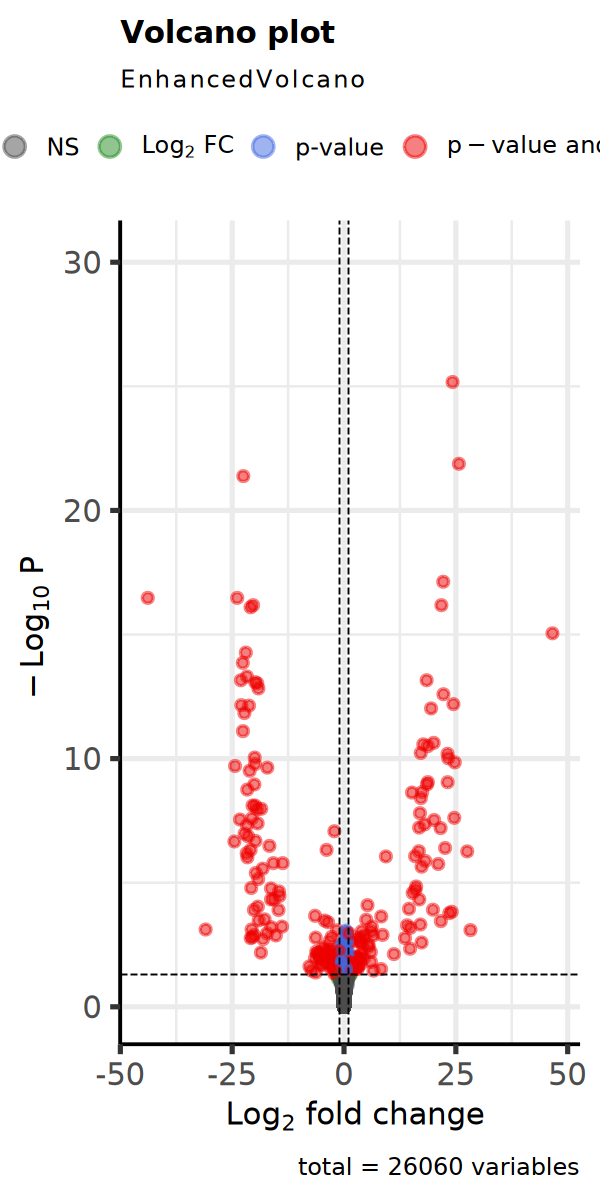

In [152]:
res.hh.bh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr')

summary(res.hh.bh)

EnhancedVolcano(res.hh.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.bh <- merge(res.hh.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.bh)[1] <- 'Gene'

head(res.hh.bh)

In [153]:
write.csv(res.hh.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bh_hh.csv', row.names = FALSE)

**BW vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 57, 0.22%
LFC < 0 (down)     : 108, 0.41%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.006211608,0.07167528,0.7682020,0.9821142,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.006595807,0.12003302,0.3077219,0.8848752,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.002406540,0.09966233,0.6656791,0.9710528,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.005203096,0.07104932,0.8162723,0.9847707,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.010803400,0.06968581,0.6674901,0.9713501,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.006066983,0.07486473,0.6359818,0.9651354,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


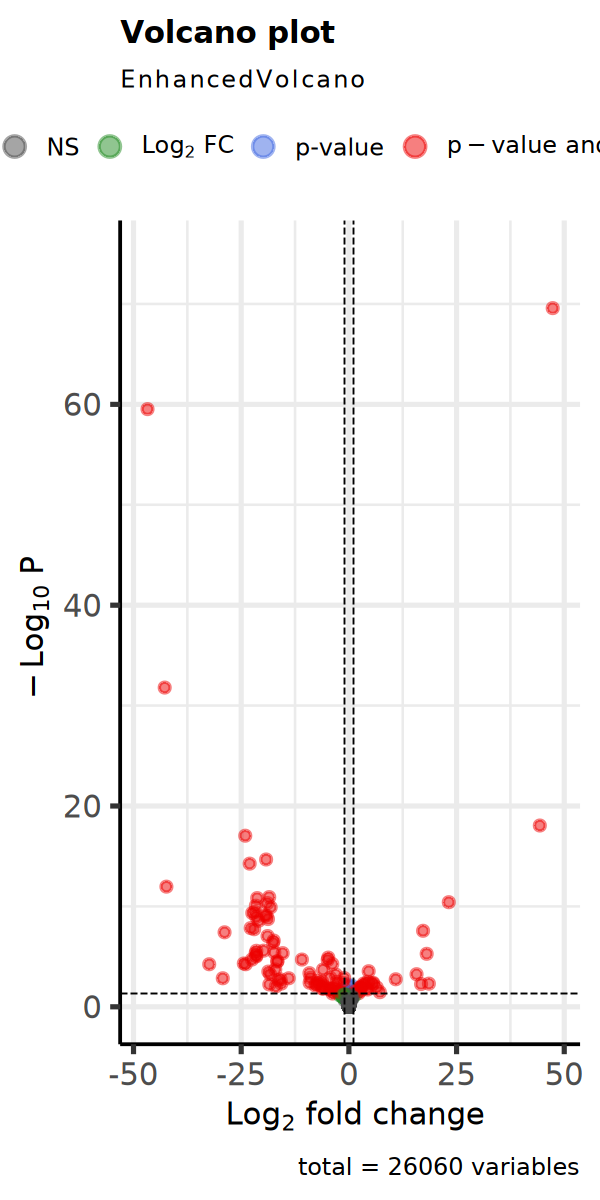

In [154]:
res.bw.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'warm.warm'), # WW is the "control"
                     type = 'ashr')

summary(res.bw.ww)

EnhancedVolcano(res.bw.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.ww <- merge(res.bw.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.ww)[1] <- 'Gene'

head(res.bw.ww)

In [155]:
write.csv(res.bw.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bw_ww.csv', row.names = FALSE)

#### 7B. ...later *multiple* stressors
Oyster is primed with either multiple or a single stressors, and then experiences multiple stressors later
- HB vs. BB
- WB vs. BB

**HB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 52, 0.2%
LFC < 0 (down)     : 81, 0.31%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.903735e-04,0.008635364,0.4838539,0.9999069,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.379139e-04,0.054754361,0.9412566,0.9999069,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,4.318704e-04,0.059850491,0.8337422,0.9999069,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-8.020538e-05,0.007824608,0.7643304,0.9999069,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,4.274341e-04,0.009421956,0.1996141,0.9999069,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,5.283549e-05,0.011353230,0.8550413,0.9999069,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


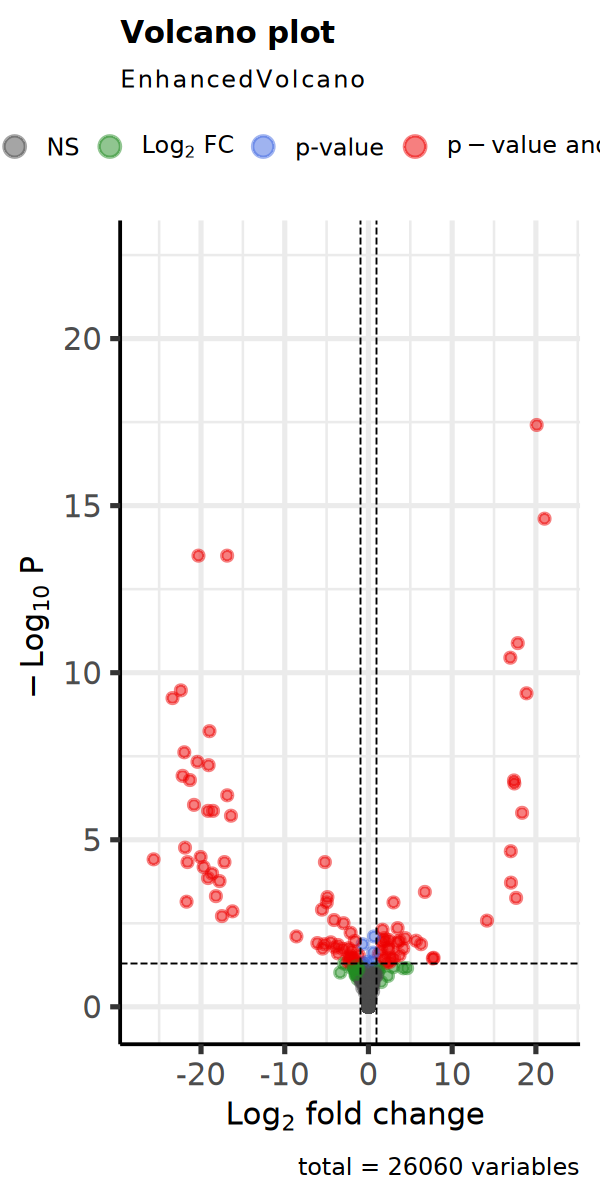

In [156]:
res.hb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_hypoxic.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.hb.bb)

EnhancedVolcano(res.hb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bb <- merge(res.hb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bb)[1] <- 'Gene'

head(res.hb.bb)

In [157]:
write.csv(res.hb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_bb.csv', row.names = FALSE)

**WB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 61, 0.23%
LFC < 0 (down)     : 42, 0.16%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.0000251683,0.008197222,0.9271625,0.9998781,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0003851659,0.057511340,0.8484753,0.9998781,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0013579044,0.071093166,0.5734671,0.9998781,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0003300084,0.009703669,0.3037208,0.9998781,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0001108754,0.007789979,0.7202109,0.9998781,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0006425064,0.022119351,0.2253576,0.9899961,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


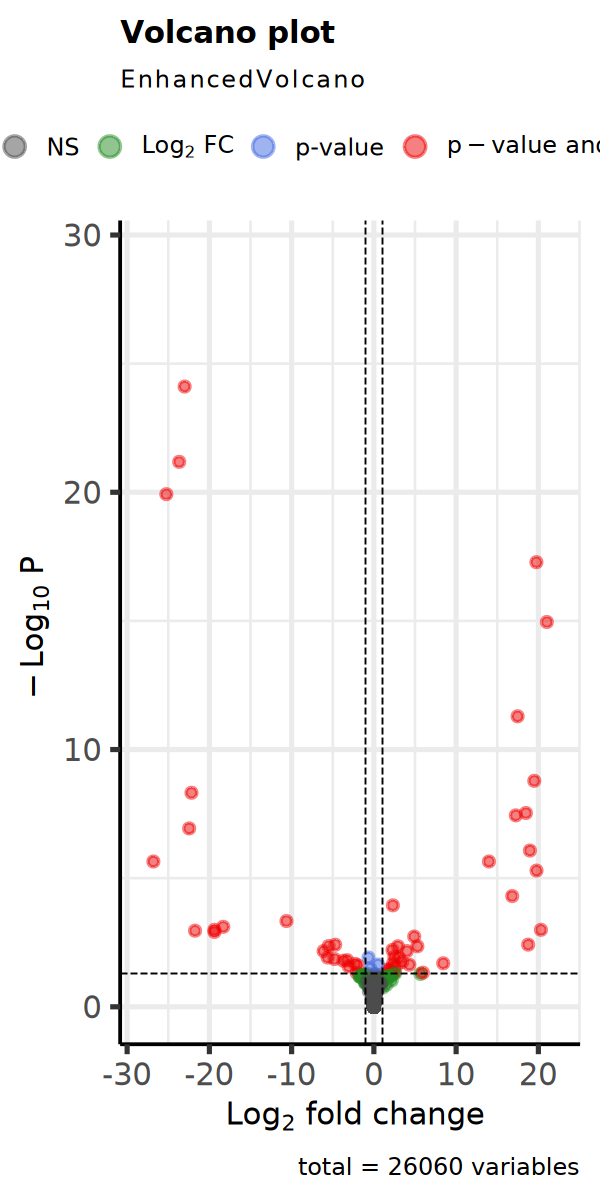

In [158]:
res.wb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_warm.both_vs_both.both', # BB is the "control"
                     type = 'ashr')

summary(res.wb.bb)

EnhancedVolcano(res.wb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bb <- merge(res.wb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bb)[1] <- 'Gene'

head(res.wb.bb)

In [159]:
write.csv(res.wb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_bb.csv', row.names = FALSE)

### 8. Shared/Unique responses among stressors with ...

#### 8A. ...different *early* stressors
>can compare these with the phase 1 vs. phase 1 DEGs to see if there are similarities
- WC vs. HC: single early stress
- BC vs. HC: mulitple vs. single
- BC vs. WC: multiple vs. single

**WC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 61, 0.23%
LFC < 0 (down)     : 39, 0.15%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,1.686327e-04,0.007116258,0.3266533,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,7.589576e-04,0.050241159,0.4950783,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-1.599553e-05,0.040696543,0.9870475,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-8.512825e-05,0.006253347,0.6124943,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,3.250518e-05,0.005972457,0.8603164,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,1.793630e-04,0.011262296,0.3447482,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


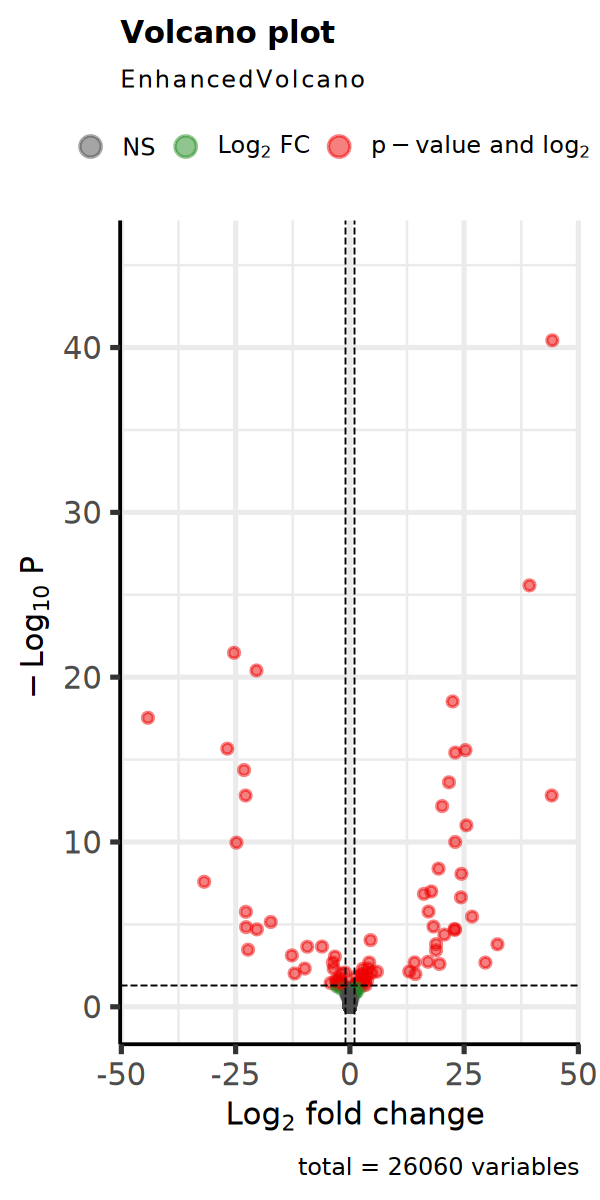

In [160]:
res.wc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.wc.hc)

EnhancedVolcano(res.wc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.hc <- merge(res.wc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.hc)[1] <- 'Gene'

head(res.wc.hc)

In [161]:
write.csv(res.wc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wc_hc.csv', row.names = FALSE)

**BC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 46, 0.18%
LFC < 0 (down)     : 115, 0.44%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,5.366742e-06,0.006044220,0.97004833,1,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,3.995407e-03,0.118879794,0.14642406,1,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-1.025139e-02,0.206312308,0.06789782,1,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-1.435426e-05,0.005944277,0.92358521,1,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,2.000291e-05,0.005798884,0.90422524,1,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-2.129551e-05,0.008074755,0.87989409,1,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


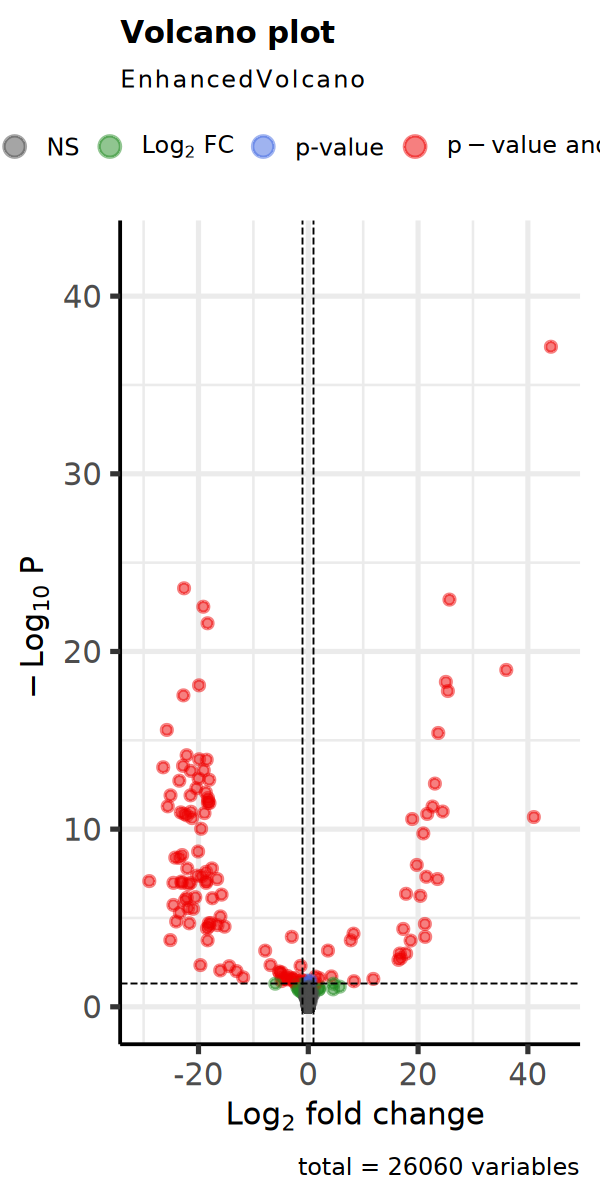

In [162]:
res.bc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr')

summary(res.bc.hc)

EnhancedVolcano(res.bc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.hc <- merge(res.bc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.hc)[1] <- 'Gene'

head(res.bc.hc)

In [163]:
write.csv(res.bc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_hc.csv', row.names = FALSE)

**BC vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 56, 0.21%
LFC < 0 (down)     : 194, 0.74%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.894347e-04,0.008479370,0.36933437,0.9998895,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,2.452363e-03,0.090380299,0.42267653,0.9998895,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-2.078002e-02,0.286884750,0.07026051,0.8375080,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,7.259246e-05,0.006792752,0.69867297,0.9998895,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-9.148647e-06,0.006241844,0.96214632,0.9998895,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-4.116894e-04,0.018451055,0.29282972,0.9998895,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


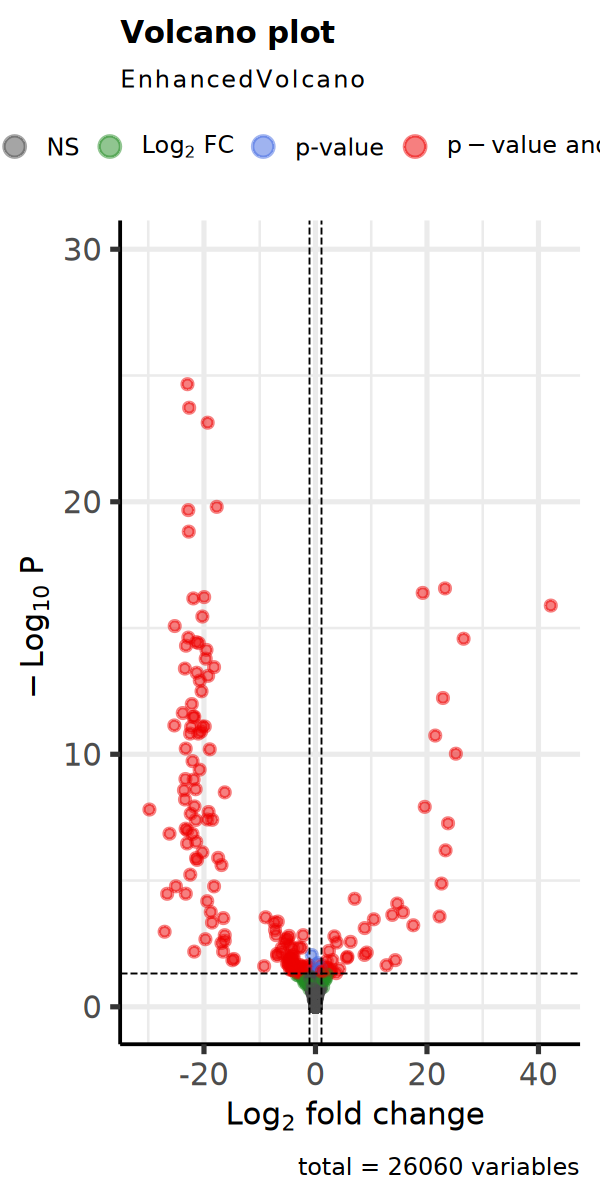

In [164]:
res.bc.wc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'warm.control'), # WC is the "control"
                     type = 'ashr')

summary(res.bc.wc)

EnhancedVolcano(res.bc.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.wc <- merge(res.bc.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.wc)[1] <- 'Gene'

head(res.bc.wc)

In [165]:
write.csv(res.bc.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/bc_wc.csv', row.names = FALSE)

#### 8B. ...different *late* stressors
- CW vs. CH: single early stress
- CB vs. CH: mulitple vs. single
- CB vs. CW: multiple vs. single

**CW vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 129, 0.5%
LFC < 0 (down)     : 68, 0.26%
outliers [1]       : 78, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.0229915083,0.06093682,0.07556639,0.6361961,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.0201844611,0.23165231,0.13062485,0.7325112,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0083184654,0.15129408,0.34936518,0.8840941,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0040666386,0.05444678,0.75714642,0.9747589,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0171997210,0.05453032,0.25420278,0.8401500,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0009370485,0.05748982,0.90156506,0.9935979,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


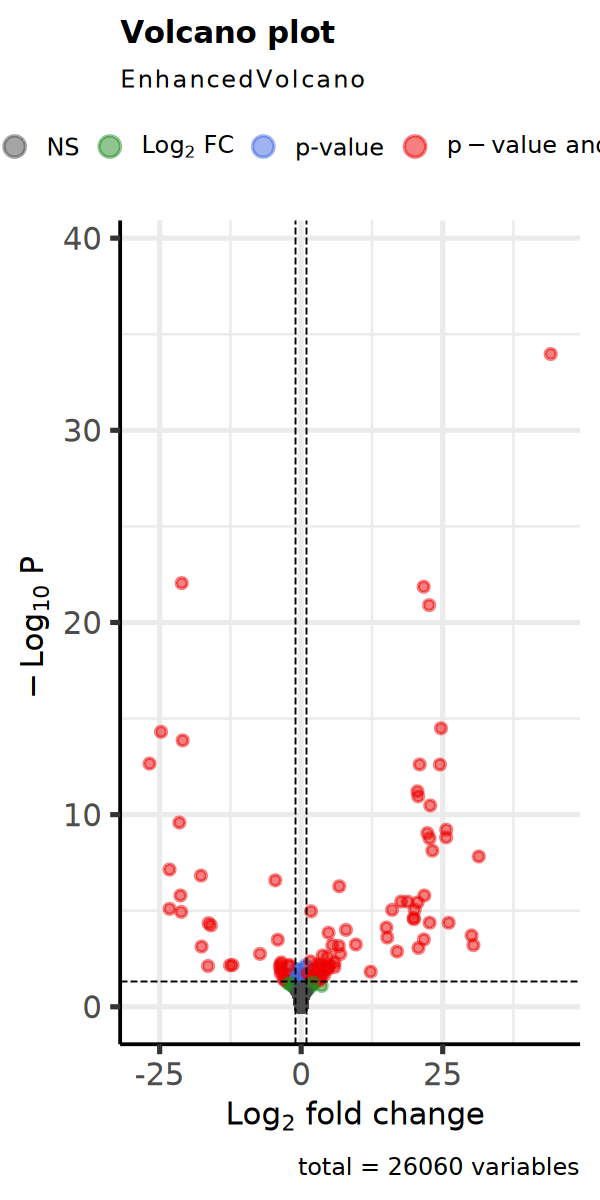

In [166]:
res.cw.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.warm', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cw.ch)

EnhancedVolcano(res.cw.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.ch <- merge(res.cw.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.ch)[1] <- 'Gene'

head(res.cw.ch)

In [167]:
write.csv(res.cw.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cw_ch.csv', row.names = FALSE)

**CB vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 120, 0.46%
LFC < 0 (down)     : 135, 0.52%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.032610886,0.08860311,0.295399206,0.8528137,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.006381610,0.14322691,0.576019792,0.9377752,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.196031864,0.85484530,0.010489433,0.3121838,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.024903451,0.08631570,0.444520013,0.9067155,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.114009079,0.11218296,0.006345184,0.2519879,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.001712304,0.09292105,0.931111529,0.9924406,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


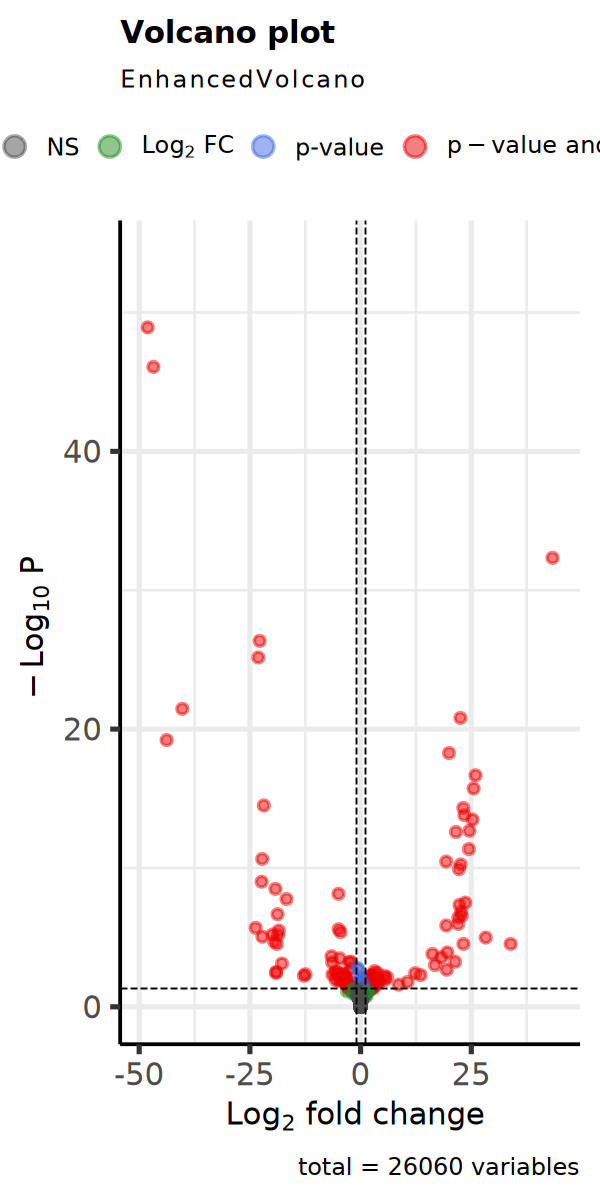

In [168]:
res.cb.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr')

summary(res.cb.ch)

EnhancedVolcano(res.cb.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.ch <- merge(res.cb.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.ch)[1] <- 'Gene'

head(res.cb.ch)

In [169]:
write.csv(res.cb.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_ch.csv', row.names = FALSE)

**CB vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 105, 0.4%
LFC < 0 (down)     : 108, 0.41%
outliers [1]       : 78, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0176675716,0.07736524,0.4650281,0.9107515,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0099897387,0.15116298,0.3408716,0.8759662,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0257361603,0.25082407,0.1039078,0.7109953,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0115854738,0.07589298,0.6490202,0.9524037,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0464209651,0.07839398,0.1120342,0.7215342,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0005755842,0.08210875,0.9703051,0.9963922,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


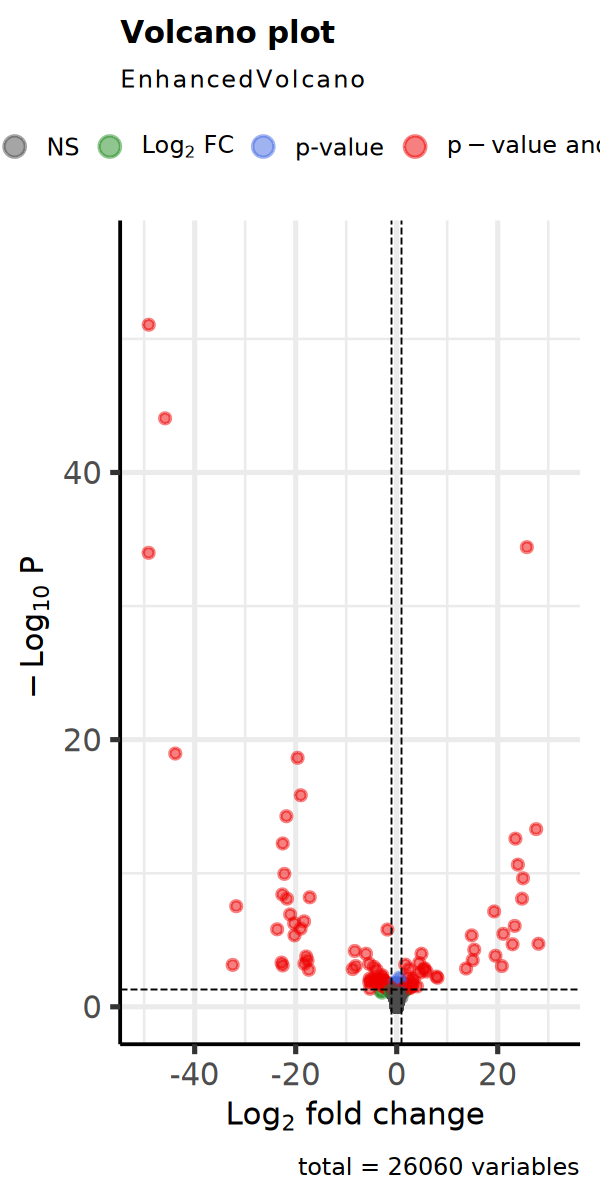

In [170]:
res.cb.cw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.warm'), # CW is the "control"
                     type = 'ashr')

summary(res.cb.cw)

EnhancedVolcano(res.cb.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cw <- merge(res.cb.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cw)[1] <- 'Gene'

head(res.cb.cw)

In [171]:
write.csv(res.cb.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/cb_cw.csv', row.names = FALSE)

### 9. Effect of the order of stressors
Does the order of when stress is experienced matter? Maybe one stressor is an informative cue for a later environmnet?
- WH vs. HW
- WB vs. BW
- HB vs. BH

**WH vs. HW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 52, 0.2%
LFC < 0 (down)     : 88, 0.34%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.0002410519,0.03686729,0.9655257,0.9974285,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0025367617,0.08420966,0.4774033,0.9784170,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0005862220,0.07455506,0.8572365,0.9931552,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0019290604,0.03662502,0.7433340,0.9900821,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0011636013,0.03537058,0.8573605,0.9931552,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0008099363,0.04173762,0.8391922,0.9931552,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


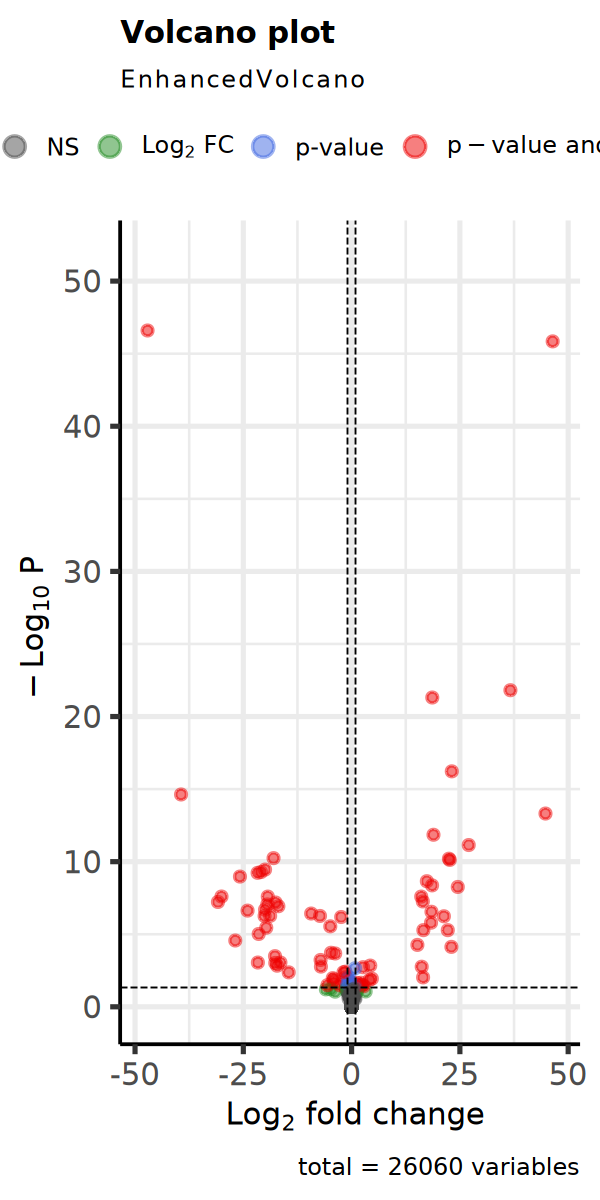

In [172]:
res.wh.hw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.hypoxic', 'hypoxic.warm'), # HW is the "control"
                     type = 'ashr')

summary(res.wh.hw)

EnhancedVolcano(res.wh.hw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wh.hw <- merge(res.wh.hw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wh.hw)[1] <- 'Gene'

head(res.wh.hw)

In [173]:
write.csv(res.wh.hw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wh_hw.csv', row.names = FALSE)

**WB vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 343, 1.3%
LFC < 0 (down)     : 113, 0.43%
outliers [1]       : 78, 0.3%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.007449779,0.09807887,0.8502751,0.9742469,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.010738993,0.18461752,0.5547910,0.8889788,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.020599233,0.23437483,0.3426268,0.8025671,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.003953757,0.09653473,0.9238147,0.9858548,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.064752553,0.09584594,0.1573492,0.6585804,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.019152750,0.10813372,0.4650687,0.8596170,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


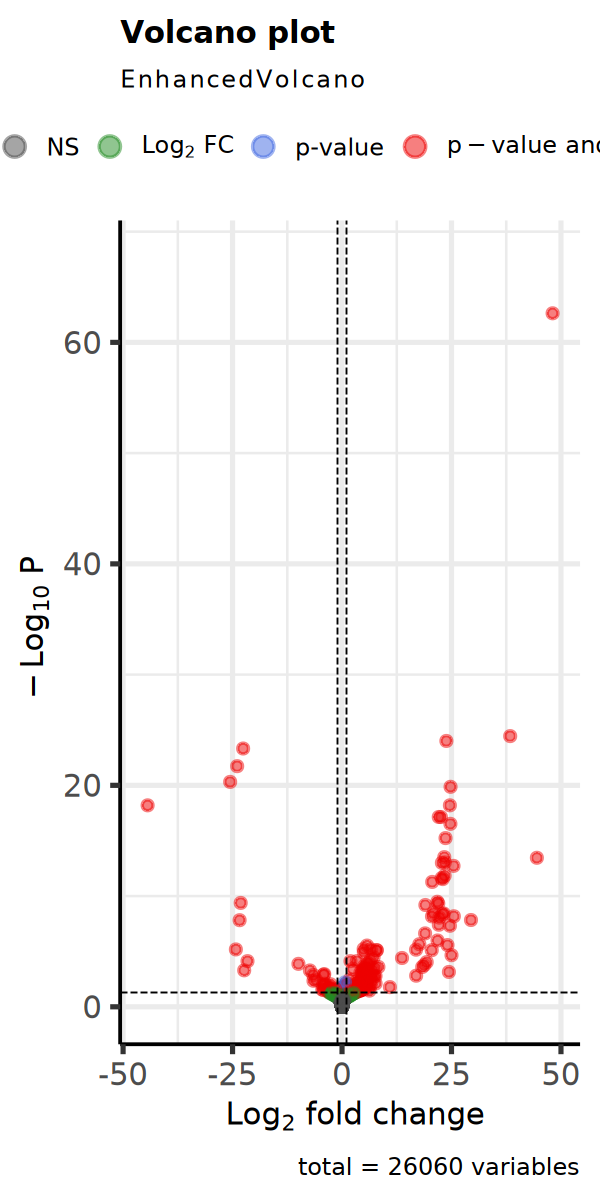

In [174]:
res.wb.bw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.both', 'both.warm'), # BW is the "control"
                     type = 'ashr')

summary(res.wb.bw)

EnhancedVolcano(res.wb.bw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bw <- merge(res.wb.bw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bw)[1] <- 'Gene'

head(res.wb.bw)

In [175]:
write.csv(res.wb.bw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/wb_bw.csv', row.names = FALSE)

**HB vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 540, 2.1%
LFC < 0 (down)     : 419, 1.6%
outliers [1]       : 78, 0.3%
low counts [2]     : 506, 1.9%
(mean count < 3)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.014331638,0.1510761,0.87815351,0.9766409,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.090975921,0.4327483,0.07234796,0.3994888,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.052072270,0.3179321,0.18354193,0.5860300,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.143570644,0.1565814,0.14703548,0.5375055,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.009231835,0.1333442,0.92027227,0.9843607,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.084663993,0.1901220,0.28662221,0.6898660,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


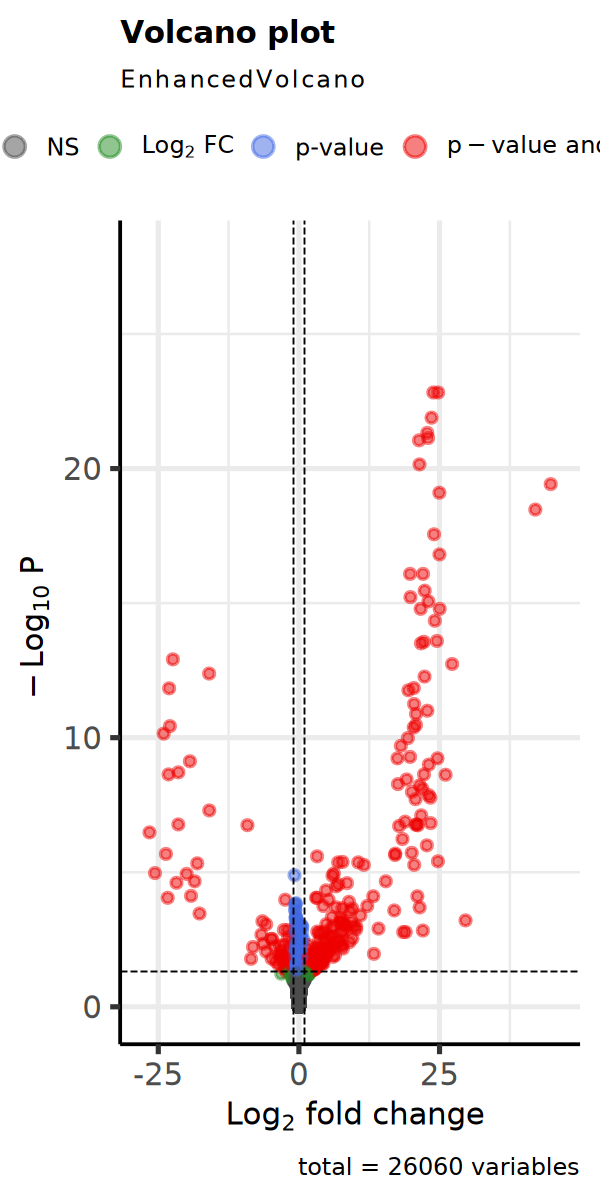

In [176]:
res.hb.bh <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'hypoxic.both', 'both.hypoxic'), # BH is the "control"
                     type = 'ashr')

summary(res.hb.bh)

EnhancedVolcano(res.hb.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bh <- merge(res.hb.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bh)[1] <- 'Gene'

head(res.hb.bh)

In [177]:
write.csv(res.hb.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/hb_bh.csv', row.names = FALSE)

### temperature and DO treatments
looking at the effects of temperature and DO in an isolated manner

#### phase 1 temp
ambient vs. warm

regardless of phase 2 treatments or phase 1 DO

In [178]:
design(dds_rm) <- ~ Phase1_temp
dds_p1temp <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1606 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 33, 0.13%
LFC < 0 (down)     : 22, 0.084%
outliers [1]       : 0, 0%
low counts [2]     : 1516, 5.8%
(mean count < 5)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,4.345911e-05,0.002821148,0.6275167,0.9884650,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-2.638636e-04,0.018988198,0.6045990,0.9876992,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,6.853190e-05,0.017636718,0.8919303,0.9936339,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-1.662233e-04,0.003675444,0.1394192,0.8897452,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-1.678138e-05,0.002682543,0.8663702,0.9936339,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,8.115249e-05,0.004509152,0.3923857,0.9738089,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


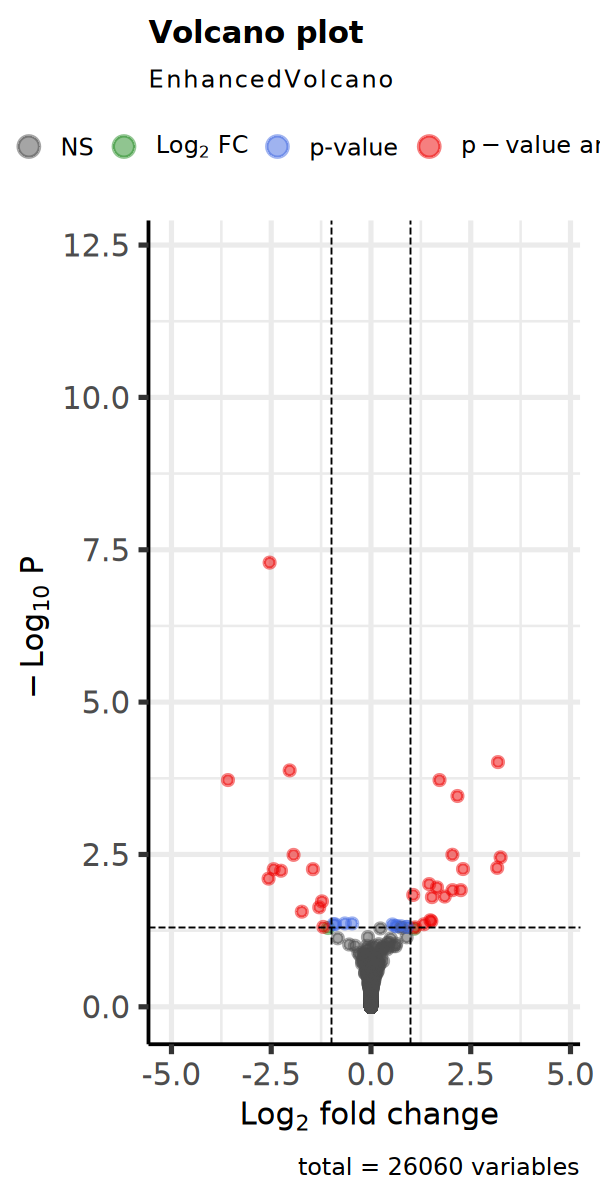

In [179]:
p1_temp.res <- lfcShrink(dds_p1temp, contrast = c('Phase1_temp', 'warm', 'ambient'),
                     type = 'ashr')

summary(p1_temp.res)

EnhancedVolcano(p1_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_temp.res <- merge(p1_temp.res, counts(dds_p1temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_temp.res)[1] <- 'Gene'

head(p1_temp.res)

In [180]:
as.data.frame(p1_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 14 DEGs

[1]  30 100

In [181]:
write.csv(p1_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_temp.csv', row.names = FALSE)

#### phase 1 DO
normoxic vs. hypoxic

In [182]:
design(dds_rm) <- ~ Phase1_DO
dds_p1DO <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1754 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 21, 0.081%
LFC < 0 (down)     : 79, 0.3%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-2.760591e-04,0.006110877,0.08085512,0.8445915,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-2.040522e-03,0.047164157,0.20660299,0.9234729,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-2.118797e-04,0.024004249,0.81513087,0.9944973,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,1.461031e-05,0.002639621,0.86785796,0.9966317,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,9.640664e-05,0.002951234,0.33548927,0.9500861,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-6.141702e-05,0.004565730,0.58664969,0.9802880,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


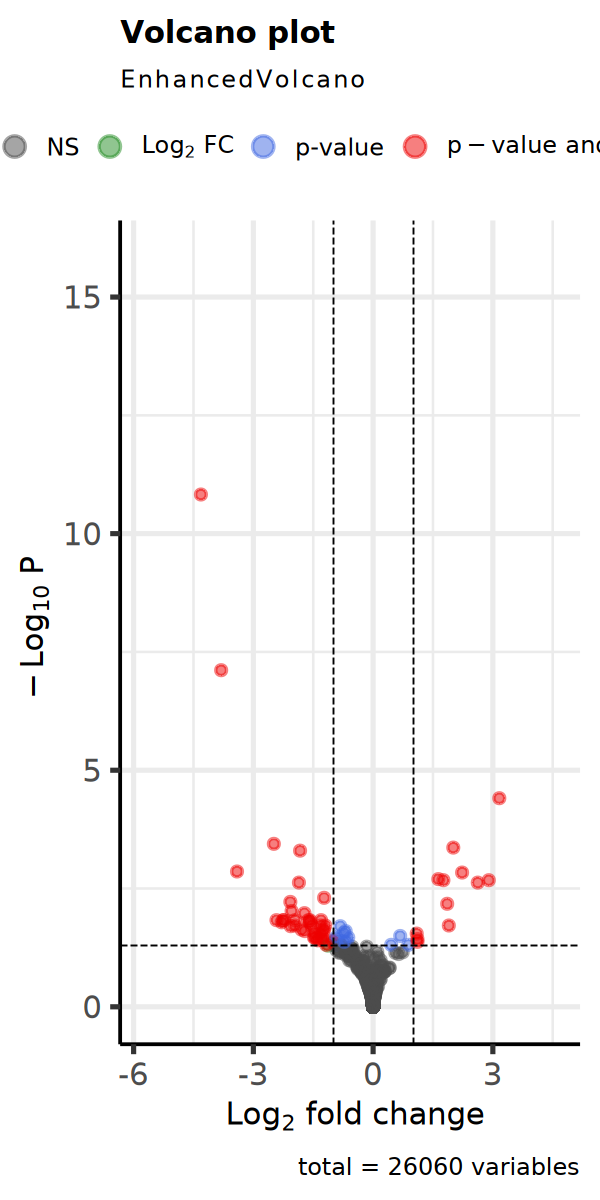

In [183]:
p1_DO.res <- lfcShrink(dds_p1DO, contrast = c('Phase1_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p1_DO.res)

EnhancedVolcano(p1_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_DO.res <- merge(p1_DO.res, counts(dds_p1DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_DO.res)[1] <- 'Gene'

head(p1_DO.res)

a couple more DEGs, but still not a ton - to be expected, since we think GE is more short term

In [184]:
as.data.frame(p1_DO.res) %>%
filter(abs(log2FoldChange) >= 1 & padj <= 0.05) %>%
dim()

# 12 DEGs

[1]  51 100

In [185]:
write.csv(p1_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p1_DO.csv', row.names = FALSE)

#### phase 2 temp
ambient vs. warm

regardless of phase 1 treatments or phase 2 DO

In [186]:
design(dds_rm) <- ~ Phase2_temp
dds_p2temp <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1706 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 1777, 6.8%
LFC < 0 (down)     : 1468, 5.6%
outliers [1]       : 0, 0%
low counts [2]     : 1011, 3.9%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.08009326,0.07135450,0.14650195,0.4026915,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.04045598,0.16052734,0.27965189,0.5643277,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.19544332,0.40706214,0.01320402,0.1012389,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.04022088,0.06439669,0.43375537,0.7027903,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.00386756,0.05888271,0.93633207,0.9773938,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.01065917,0.09492344,0.85544770,0.9438448,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


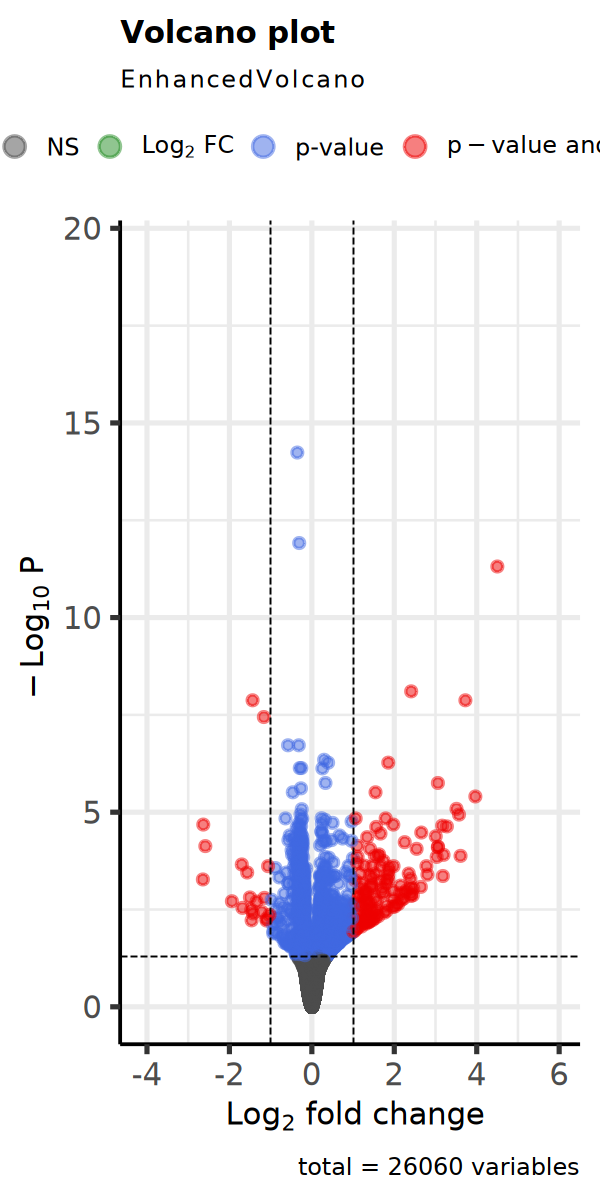

In [187]:
p2_temp.res <- lfcShrink(dds_p2temp, contrast = c('Phase2_temp', 'warm', 'ambient'), 
                     type = 'ashr')

summary(p2_temp.res)

EnhancedVolcano(p2_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_temp.res <- merge(p2_temp.res, counts(dds_p2temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_temp.res)[1] <- 'Gene'

head(p2_temp.res)

In [188]:
as.data.frame(p2_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 80 DEGs!

[1] 160 100

In [189]:
write.csv(p2_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_temp.csv', row.names = FALSE)

#### phase 2 DO
normoxic vs. hypoxic

regardless of phase 1 treatments or phase 2 temperatures

In [190]:
design(dds_rm) <- ~ Phase2_DO
dds_p2DO <- DESeq(dds_rm)

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1569 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041




out of 26060 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 942, 3.6%
LFC < 0 (down)     : 475, 1.8%
outliers [1]       : 0, 0%
low counts [2]     : 3537, 14%
(mean count < 12)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



,Gene,baseMean,log2FoldChange,lfcSE,pvalue,padj,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.067581055,0.06561099,0.11444689,0.4536904,2479.82397,2077.44032,2050.1975,1814.142102,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.034586258,0.13550776,0.14847095,0.5091125,51.93843,1636.28504,2359.9123,884.328671,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.051697558,0.17273894,0.05679438,0.3265713,66.10346,23.06039,445.5712,9.621776,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.010590208,0.05531889,0.78385623,0.9362958,537.32667,864.26330,885.4421,735.628499,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.051379677,0.05588725,0.19552638,0.5706549,10653.98858,10994.79275,12461.7428,11045.798678,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.003773554,0.07675844,0.92137832,0.9790202,159.59263,181.47524,150.1071,107.588948,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


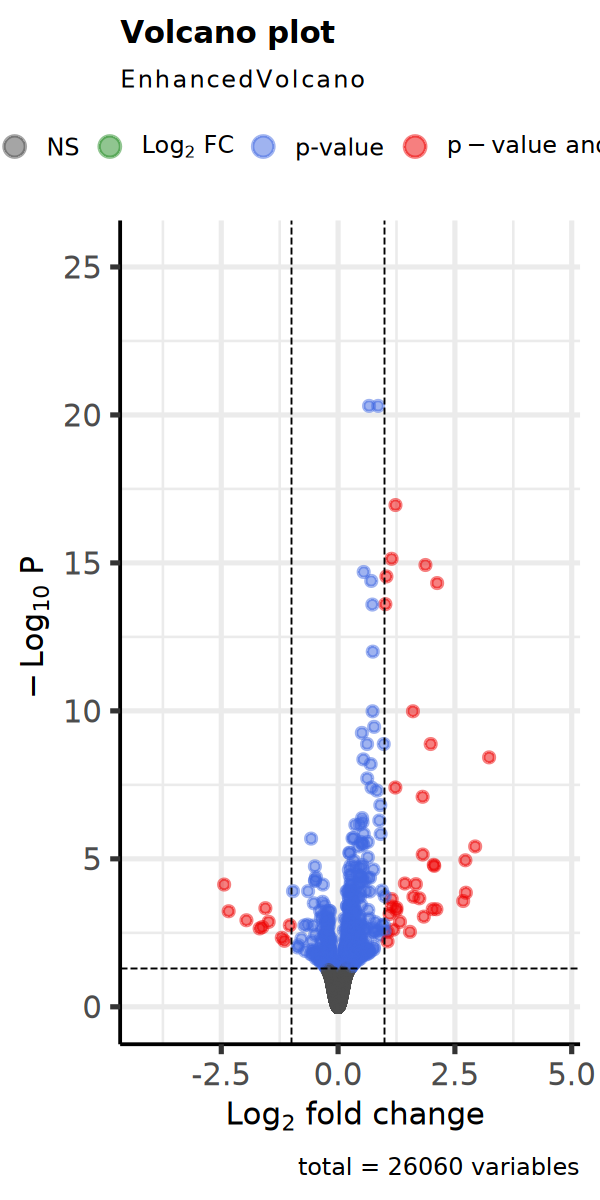

In [191]:
p2_DO.res <- lfcShrink(dds_p2DO, contrast = c('Phase2_DO', 'hypoxic', 'normoxic'), 
                     type = 'ashr')

summary(p2_DO.res)

EnhancedVolcano(p2_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_DO.res <- merge(p2_DO.res, counts(dds_p2DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_DO.res)[1] <- 'Gene'

head(p2_DO.res)

In [192]:
as.data.frame(p2_DO.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 29 DEGs!

[1]  45 100

In [193]:
write.csv(p2_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/isolated_treatments/p2_DO.csv', row.names = FALSE)

# I STOPPED HERE

### nMDS of only significant DEGs from isolated treatments

shouldn't matter which DESeq function I run, since we only need vst which is the normalized expression - should return the same numbers/counts 

In [146]:
# variance stabilizing transformation
vsd <- vst(dds.noOutliers) # from full DESeq function, without the 2 outlier samples
head(assay(vsd))

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'nrow': object 'dds.noOutliers' not found


get list of DEGs identified in the 'isolated' treatments (otherwise, there's just a million DEGs)

In [42]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "p1_DO"   "p1_temp" "p2_DO"   "p2_temp"

In [43]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::filter(padj < 0.05 & abs(log2FoldChange) > 1) %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 290 total DEGs
head(all_degs)

[1] 265

[1] "LOC111104012" "LOC111102592" "LOC144624804" "LOC144625490" "LOC144625901"
[6] "LOC111101301"

In [44]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 290 total DEGs kept
head(degs_vsd) 

[1] 265  94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111102506,10.380840,9.560323,13.467640,9.095155,10.970108,8.935006,9.062335,10.197227,11.499914,9.047712,⋯,9.050487,9.415516,9.525608,10.696301,9.276084,9.537034,10.351851,9.426189,9.549025,9.346426
LOC111103173,8.347567,8.247518,8.279739,8.161861,8.161861,8.321493,8.161861,8.161861,8.161861,8.995706,⋯,8.161861,8.161861,8.161861,8.471088,8.304568,8.161861,8.291656,8.161861,8.339826,8.338495
LOC111103490,12.325820,13.319562,13.893435,11.230966,12.825426,12.065763,12.362042,11.998235,11.651213,10.530309,⋯,11.425075,10.593363,11.145859,11.228763,12.027792,11.018941,12.625862,11.607018,11.498946,13.141607
LOC144622059,8.327985,8.876399,8.245225,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,⋯,10.237259,8.161861,8.296431,8.283347,8.161861,8.161861,9.787217,8.161861,8.161861,10.179552
LOC111105131,8.396666,8.403887,8.867176,8.300329,8.694998,8.367875,8.454862,8.161861,8.531140,8.403151,⋯,9.441800,8.440138,8.161861,8.161861,8.161861,8.314577,9.782977,8.161861,8.161861,8.610659
LOC111104543,8.161861,8.445538,8.524332,8.321730,8.619704,8.572847,8.438158,8.161861,8.161861,8.161861,⋯,9.320533,8.161861,8.161861,8.404617,8.422161,8.314577,8.779810,8.161861,8.161861,10.026920


In [45]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,12.575673,16.82096,12.932864,18.58007,12.594205,14.322617,12.745796,11.877148,14.74850,⋯,27.36305,12.869791,12.07491,13.119530,12.501106,11.169574,25.15713,12.550227,13.346193,29.06447
B1_W5_O50,12.57567,0.000000,14.84429,8.567808,15.52108,8.574989,7.974597,8.088239,8.893891,12.04086,⋯,23.28776,9.808964,10.29981,8.776904,10.301848,9.748675,23.38100,9.719817,9.762422,24.77291
B2_B5_O51,16.82096,14.844288,0.00000,17.181774,16.99998,15.616050,14.885430,15.458491,16.149148,18.88176,⋯,22.43185,17.067327,17.58493,14.626084,16.882472,16.532962,21.64151,16.288461,16.925990,24.29982
B2_C4_O40,12.93286,8.567808,17.18177,0.000000,18.24160,8.873988,11.237758,9.261132,10.947797,10.92293,⋯,25.83020,9.409984,10.18547,9.371928,8.983627,9.903190,25.75128,8.394751,7.448790,27.16068
B3_B4_O41,18.58007,15.521084,16.99998,18.241597,0.00000,17.531613,16.313913,18.262602,17.093566,20.59936,⋯,17.40215,19.204303,19.46881,16.970775,19.212475,17.971481,15.06084,17.577956,18.698433,17.14160
B3_C3_O30,12.59420,8.574989,15.61605,8.873988,17.53161,0.000000,9.610107,10.058257,9.934005,12.57127,⋯,25.32502,10.679681,10.31777,9.091426,11.205199,9.598842,25.16273,9.570942,10.089753,26.92753


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>
B1_B1_O01,3.7145466,2.5912620,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0522133
B1_W5_O50,0.7497815,0.6554000,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9902207
B2_B5_O51,-4.1042118,5.1527838,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0454603
B2_C4_O40,3.6180568,-2.3523123,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1362472
B3_B4_O41,-9.8654563,-2.7231799,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8595069
B3_C3_O30,3.0588292,-0.1253456,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8547230


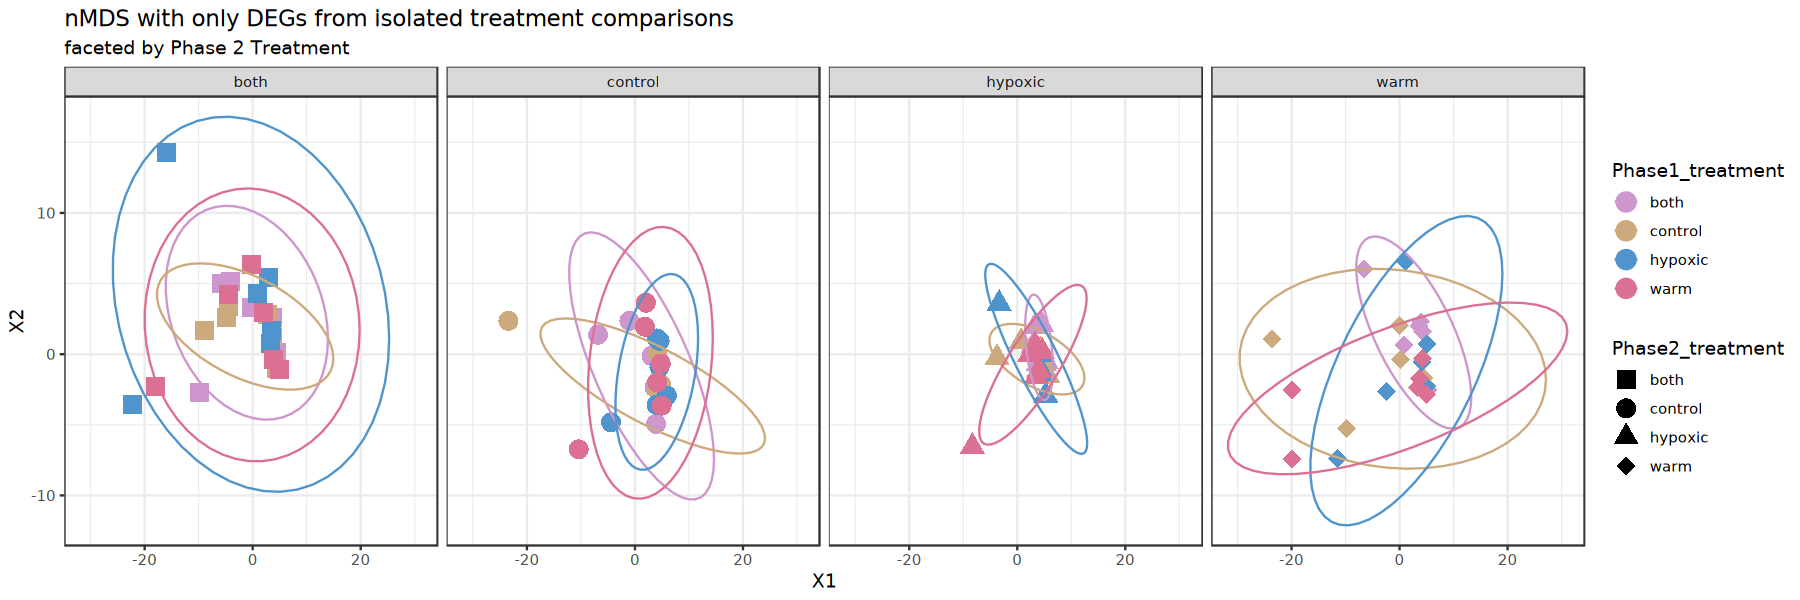

In [46]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 Treatment') + 
theme_bw()

nmds.plot

see less dispersion in phase 2 control and hypoxic (so ambient) samples compared to both and warm (so warm) samples 

this makes sense, as I've seen phase 2 temperature being a bigger driver for differential expression

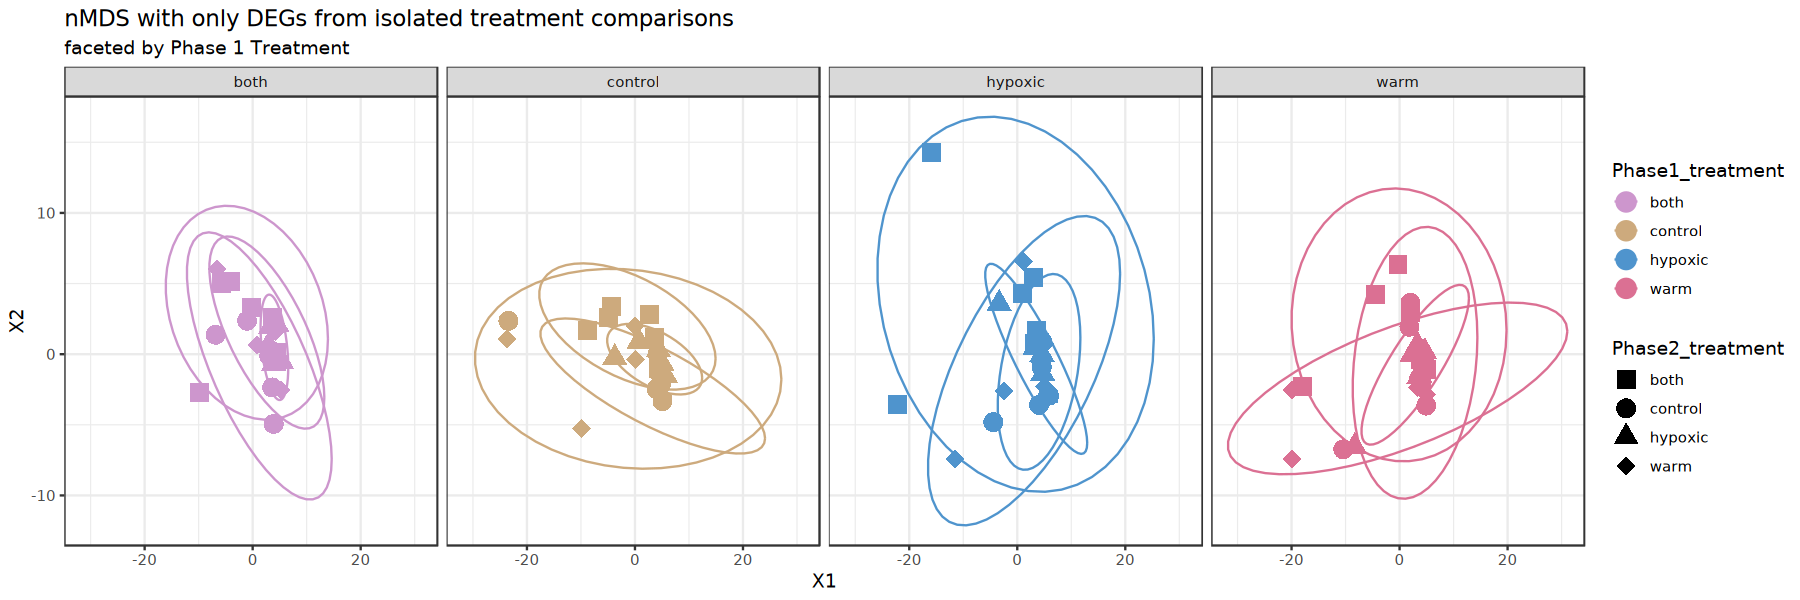

In [47]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 1 Treatment') + 
theme_bw()

nmds.plot

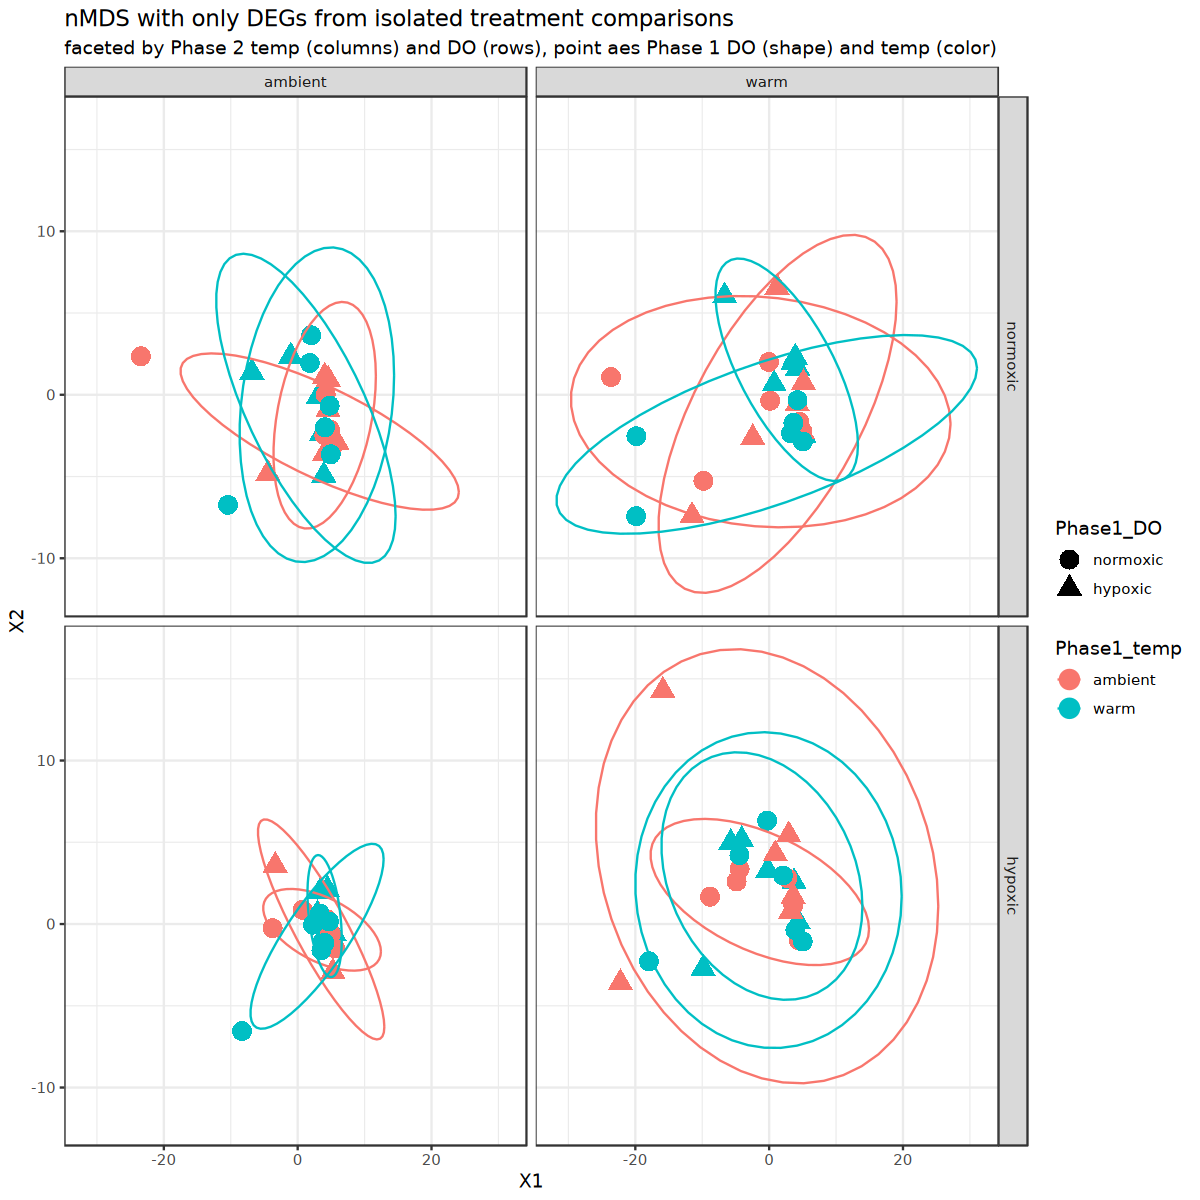

In [48]:
options(repr.plot.width = 10, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
facet_grid(Phase2_DO~Phase2_temp) + 
stat_ellipse() + 
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 temp (columns) and DO (rows), point aes Phase 1 DO (shape) and temp (color)') + 
theme_bw()

nmds.plot

#### permanova for DEGs

In [49]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,66.09649,0.005232892,0.4968288,0.965
Phase1_DO,1,158.03661,0.012511838,1.1879171,0.260
Phase2_temp,1,612.46338,0.048489033,4.6037161,0.001
Phase2_DO,1,370.63484,0.029343346,2.7859585,0.023
Phase1_temp:Phase1_DO,1,84.56534,0.006695080,0.6356540,0.771
Phase1_temp:Phase2_temp,1,73.88016,0.005849130,0.5553365,0.886
Phase1_DO:Phase2_temp,1,63.09464,0.004995235,0.4742648,0.970
Phase1_temp:Phase2_DO,1,69.30171,0.005486651,0.5209216,0.926
Phase1_DO:Phase2_DO,1,140.79844,0.011147083,1.0583425,0.321


only significant effects from Phase2_temp and Phase2_DO - so most recent stressors

### nMDS of any DEG identified in all pairwise comparisons

In [16]:
# variance stabilizing transformation
vsd <- vst(dds.noOutliers) # from full DESeq function, without the 2 outlier samples
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111116054,7.692872,7.805746,7.871959,7.843091,7.548551,7.909124,7.947895,7.869635,7.840134,7.758281,⋯,7.767900,7.713596,7.900466,7.697844,7.834121,7.790482,7.708399,8.030152,7.657898,7.548551
LOC111126949,10.197580,9.653169,9.900281,9.718856,9.612738,9.545333,9.334530,9.803992,9.906070,9.592360,⋯,9.078093,9.779869,9.712370,10.082883,9.950378,9.563392,9.665533,9.644851,9.276775,9.929224
LOC111110729,8.354765,8.542687,8.351593,8.513945,8.518601,8.653091,8.816678,8.937210,8.568640,8.590933,⋯,8.714150,8.368627,8.514299,8.798284,8.635108,8.680883,8.780214,8.673395,8.746416,9.064164
LOC111112434,7.886383,7.697174,7.548551,7.687586,7.940109,7.989592,7.818256,8.186828,7.658920,7.879728,⋯,7.817069,7.548551,7.937395,7.806904,7.750644,7.548551,7.708399,7.990820,7.857315,7.548551
LOC111120752,9.363550,9.355360,9.509373,9.284512,9.198871,9.337765,9.699834,9.473806,8.989457,9.167603,⋯,9.549481,9.234610,9.599548,9.383933,9.510347,9.253648,9.345876,9.627837,9.412129,9.619853
LOC111128944,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,⋯,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551


get list of DEGs identified in the 'isolated' treatments (otherwise, there's just a million DEGs)

In [45]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/DEGs/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "DEG_bb_cc" "DEG_bc_bb" "DEG_bc_cc" "DEG_bc_hc" "DEG_bc_wc" "DEG_bh_ch"
 [7] "DEG_bh_hh" "DEG_bw_cw" "DEG_bw_ww" "DEG_cb_bb" "DEG_cb_bc" "DEG_cb_cc"
[13] "DEG_cb_ch" "DEG_cb_cw" "DEG_ch_cc" "DEG_ch_hc" "DEG_cw_cc" "DEG_cw_ch"
[19] "DEG_cw_wc" "DEG_hb_bb" "DEG_hb_bh" "DEG_hb_cb" "DEG_hc_cc" "DEG_hc_hh"
[25] "DEG_hh_cc" "DEG_hh_ch" "DEG_wb_bb" "DEG_wb_bw" "DEG_wb_cb" "DEG_wc_cc"
[31] "DEG_wc_hc" "DEG_wc_ww" "DEG_wh_hw" "DEG_ww_cc" "DEG_ww_cw"

In [46]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 2263 total DEGs
head(all_degs)

[1] 2263

[1] "LOC111134671" "LOC111120923" "LOC111136853" "LOC111120760" "LOC111107221"
[6] "LOC111125595"

In [47]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 2263 total DEGs kept
head(degs_vsd) 

[1] 2263   94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111105691,7.692872,7.845404,8.595408,8.101515,8.014009,8.149132,7.757585,8.212449,7.704598,7.805305,⋯,7.703729,7.713596,7.859081,7.548551,8.010013,7.736037,7.905257,8.416445,7.997691,7.548551
LOC111109550,8.131067,7.805746,8.743886,7.928364,7.708812,7.803846,8.159885,8.674840,7.704598,7.653485,⋯,7.985994,8.626921,7.714765,8.881685,10.092835,8.251878,9.960122,8.017421,8.058891,8.520289
LOC111102585,7.798315,8.004935,8.306724,8.475852,8.355585,7.548551,8.803914,7.948558,7.704598,7.758281,⋯,8.794420,7.817824,7.666114,8.234621,7.898017,7.548551,10.227302,8.077917,7.875967,9.296881
LOC111129522,7.548551,8.120664,7.887674,8.066193,8.144263,7.926626,8.494087,7.548551,7.860191,7.782985,⋯,8.094194,7.548551,9.987741,7.697844,9.097456,7.872833,8.173305,7.898706,7.857315,8.129922
LOC111119645,11.013693,8.101502,11.484225,8.037954,7.548551,7.776953,7.774301,7.548551,7.704598,7.696918,⋯,9.367806,7.951734,7.811141,8.938418,8.740486,7.854358,7.825135,7.976880,8.123486,8.262219
LOC111129878,7.650623,7.548551,7.871959,7.952738,7.661902,7.776953,7.919830,7.548551,7.548551,7.653485,⋯,7.548551,7.548551,7.880431,7.806904,7.795962,7.656847,7.661610,7.931939,7.816075,7.548551


In [48]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,46.43361,45.73539,43.84645,49.73550,44.43556,47.39553,43.74362,46.22663,41.88886,⋯,57.89188,42.65465,39.22486,39.07451,38.70156,41.73571,59.67276,42.59358,41.49088,59.86365
B1_W5_O50,46.43361,0.00000,50.88725,35.16716,40.25746,37.80542,36.85094,39.82587,39.26073,38.94531,⋯,50.92336,40.06429,39.28590,44.69943,43.99756,41.04530,53.09433,40.34483,38.75099,50.03105
B2_B5_O51,45.73539,50.88725,0.00000,50.60368,50.77186,51.57691,49.44982,52.85483,54.79573,51.71212,⋯,52.67049,52.82034,51.48311,42.86659,48.04415,52.55684,58.24607,51.88533,48.80898,53.92939
B2_C4_O40,43.84645,35.16716,50.60368,0.00000,42.74597,33.38867,39.20402,38.13177,39.36770,37.22117,⋯,53.58619,37.38804,38.27075,43.05805,41.64574,40.47929,57.77789,37.40804,33.11933,53.52733
B3_B4_O41,49.73550,40.25746,50.77186,42.74597,0.00000,45.87647,43.81807,46.81046,39.69463,47.11637,⋯,42.79811,47.87468,46.67330,47.61091,49.46200,48.35379,45.50210,45.57722,46.29409,42.70204
B3_C3_O30,44.43556,37.80542,51.57691,33.38867,45.87647,0.00000,41.11701,40.36882,41.73098,37.71411,⋯,56.16122,38.34243,38.44486,44.86054,42.96716,39.30128,57.66326,39.16953,37.81118,54.84643


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>
B1_B1_O01,8.434536,12.217624,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0666333
B1_W5_O50,-3.341411,-8.427508,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,1.0057329
B2_B5_O51,-7.695686,20.238490,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0584922
B2_C4_O40,3.140779,-7.068260,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1493541
B3_B4_O41,-16.873005,-7.050391,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8648335
B3_C3_O30,5.335760,-7.838027,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8506698


Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


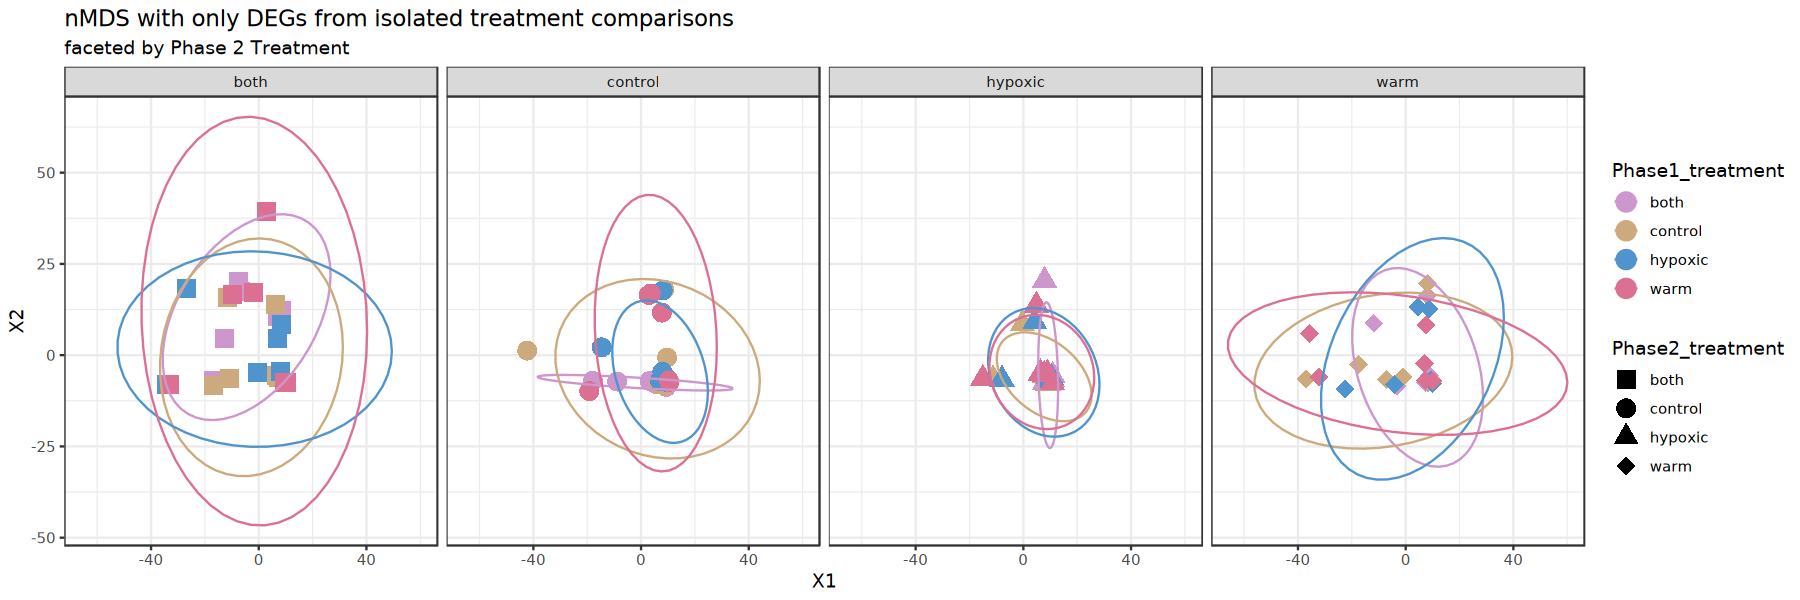

In [49]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 Treatment') + 
theme_bw()

nmds.plot

BC samples (purple circles) - super tight clustering; same with BH samples (purple triangles)

Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


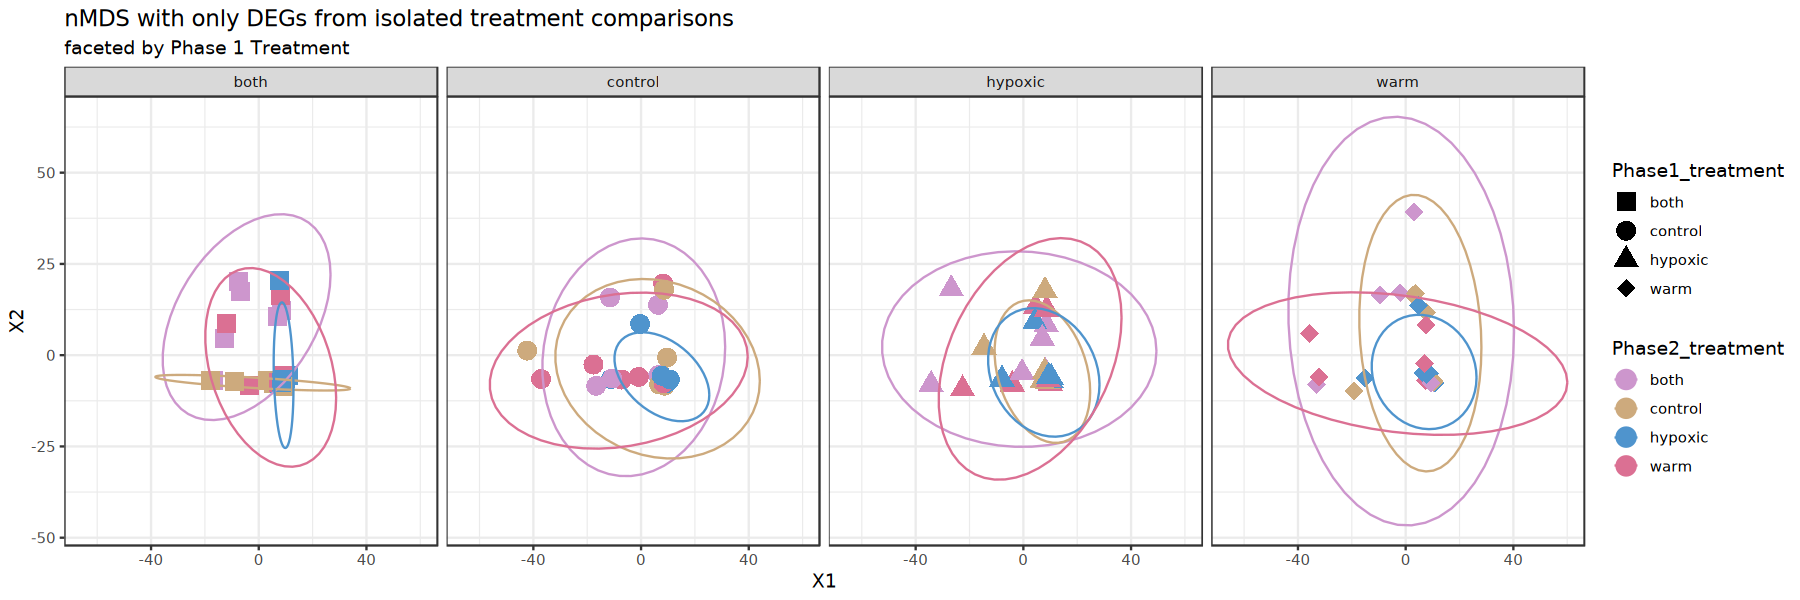

In [58]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, shape = Phase1_treatment, col = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 1 Treatment') + 
theme_bw()

nmds.plot

*coloring and shapes are reversed from above*

- phase 2 hypoxic (blue) seems to have a less dispersed GE profile - tighter circling in all grids
- phase 2 both has more dispersed profile in all grids, less specific response/depends on the early stressor?